# `ab_retirements`

An end-to-end statistics+ML project testing whether a "nudging" campaign can increase investor contributions to their retirement accounts at the (fictitious) "ABC Investments" firm.

**Written by Manuel A. Buen-Abad.**

## 0. Loading Modules

### Basic

In [1]:
import os
import sys
import time

import numpy as np

from math import pi, e

import itertools

# import inspect
# import warnings

### Data Handling and Cleaning

In [2]:
# pandas
import pandas as pd

# duckdb
import duckdb

# from sklearn import set_config

Ensuring all Pipelines output `pandas.DataFrame`, globally!

In [3]:
# set_config(transform_output="pandas") # globally!

pd.set_option('display.max_columns', None) # displaying all columns!

Defining some useful functions to check the efficiency of the SQL queries:

In [4]:
# ONE_MB = 10**6
# ONE_GB = 1000*ONE_MB

# # ...........................................................

# def show_amount_of_data_scanned(query, client=None):
#     """
#     Estimates and prints the amount of data (in MB) a BigQuery SQL query would scan without executing it.

#     This function performs a dry run of a given SQL query using the BigQuery API to determine how much data would be processed if the query were run. It is useful for cost estimation and query optimization.

#     Parameters
#     ----------
#     query : str
#         A valid SQL query string to be analyzed.
#     client : google.cloud.bigquery.Client, optional
#         An instance of a BigQuery client. If None, the function assumes a globally available client.

#     Returns
#     -------
#     None
#         Prints the estimated amount of data the query would scan in megabytes (MB).
#     """


#     dry_run_config = bigquery.QueryJobConfig(dry_run=True)
#     query_job = client.query(query, job_config=dry_run_config)

#     print("Data processed: {} MB".format(round(query_job.total_bytes_processed / ONE_MB, 3)))


# # ...........................................................

# def show_time_to_run(query, client=None):
#     """
#     Measures and prints the execution time (in seconds) for a BigQuery SQL query.

#     This function runs a query using the BigQuery client with caching disabled to ensure an accurate measurement of query execution time. It prints the elapsed time in seconds.

#     Parameters
#     ----------
#     query : str
#         A valid SQL query string to be executed.
#     client : google.cloud.bigquery.Client, optional
#         An instance of a BigQuery client. If None, the function assumes a globally available client.

#     Returns
#     -------
#     None
#         Prints the time taken to execute the query in seconds.
#     """


#     timed_run_config = bigquery.QueryJobConfig(use_query_cache=False)
#     start = time()
#     query_job = client.query(query, job_config=timed_run_config)
#     query_result = query_job.result()
#     end = time()

#     print("Time to run: {} s".format(round(end - start, 3)))

### Data Visualization and Analysis

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# for saving images to RAM and then making a grid with them:
from io import BytesIO
from PIL import Image

In [6]:
# very pretty plots!
plt.style.use('fivethirtyeight')

# Override aggressive elements
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

Defining the colors and the palette:

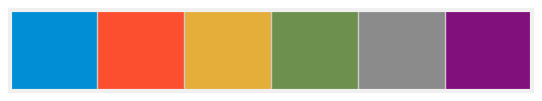

In [7]:
colors_538 = plt.rcParams['axes.prop_cycle'].by_key()['color']
palette_538 = sns.color_palette()

sns.palplot(palette_538)

Putting the the `matplotlib` verbosity at the `warning` level or above (_i.e._, `error` and `critical`):

In [8]:
plt.set_loglevel('WARNING')

### Memory Handling

The "safe" number of CPUs we can use:

In [9]:
import multiprocessing as mp

# number of cores in laptop, minus 2 (so we free one *physical* core)
safe_cpus = mp.cpu_count() - 2
print(safe_cpus)

18


Functions that find memory size of an object, and all references to it:

In [10]:
def get_object_size(obj):
    """
    Return the memory footprint of an object in bytes.

    If the object is a pandas DataFrame or Series, attempt to compute its deep memory usage; otherwise, fall back to using sys.getsizeof.

    Args:
        obj: The object whose memory size will be computed.

    Returns:
        int: The size of the object in bytes.
    """

    if isinstance(obj, pd.DataFrame) or isinstance(obj, pd.Series):
        try:
            return obj.memory_usage(deep=True).sum()
        except:
            return sys.getsizeof(obj)
    return sys.getsizeof(obj)

def find_named_references(obj, namespace=None):
    """
    Find variable names in a given namespace that reference a specific object.

    Args:
        obj: The object to search for.
        namespace (dict, optional): A mapping of variable names to objects.
            Defaults to the global namespace.

    Returns:
        list[str]: Names of variables that reference the given object.
    """

    if namespace is None:
        namespace = globals()
    return [name for name, val in namespace.items() if val is obj]

Examples of use:

In [11]:
# all_sizes = {}
# for name in dir():
#     all_sizes[name] = get_object_size(globals()[name])

# del name

In [12]:
# sorted(all_sizes, key=lambda k: all_sizes[k], reverse=True)

In [13]:
# sum(list(all_sizes.values()))/1024/1024

# del all_sizes

### Cleanup

In [14]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

## 1. Preamble

### Paths

In [16]:
nb_dir = "./" # notebooks directory
data_dir = "../data/" # data directory
input_data_dir = data_dir+"input/" # input data directory
output_data_dir = data_dir+"output/" # output data directory
exper_data_dir = output_data_dir+"experiments/" # output experiments directory
figs_dir = data_dir+"output/figures/" # output figures directory
models_dir = "../models/" # models directory

## 2. Investor Data

### Investors: Wealth

#### Importing Data

The Fed runs the SCF (Survey of Consumer Finances), which has household-level retirement account indicators, balances, income, age, etc. This is useful for us to realistically simulate the investors in ABC Investments.

**ASSUMPTIONS: (_i_) one investor per household, (_ii_) this sample is representative of ABC's cross section of investors.**

The data can be found [here](https://www.federalreserve.gov/econres/scfindex.htm), in the table corresponding to the _"Summary Extract Public Data - Summary variables used in the Federal Reserve Report – all dollar variables inflation-adjusted to 2022 dollars"_.

First, we point to the SCF 2022 data:

In [17]:
scf_file = "SCFP2022.csv"

We now write the basic query that extracts the most important data:

In [18]:
table = input_data_dir+scf_file

test_query = \
f"""
SELECT YY1 AS id,
       AVG(AGE) AS age,
       AVG(INCOME) AS income,
       AVG(NETWORTH) AS net_worth,
       AVG(COALESCE(IRAKH,0)
        + COALESCE(THRIFT,0)
        + COALESCE(CURRPEN,0)
        + COALESCE(FUTPEN,0)
        + COALESCE(ANNUIT,0)
        + COALESCE(RETQLIQ,0)) AS retirement_balance,
       CAST(AVG(IF(MARRIED=1, 2, 1) + KIDS) AS INTEGER) AS family_size
       
       FROM '{table}'
       
       GROUP BY id

       ORDER BY id
"""

del table

Running the query, and saving the result:

In [19]:
# Run SQL directly on the CSV
result = duckdb.query(test_query).to_df()

result.to_csv(input_data_dir+"scf_simple.csv")

In [20]:
result.describe()

,id,age,income,net_worth,retirement_balance,family_size
count,4595.000000,4595.000000,4.595000e+03,4.595000e+03,4.595000e+03,4595.000000
mean,2302.597171,54.468988,1.592855e+06,1.995640e+07,1.203939e+06,2.370838
std,1328.865275,16.190491,1.239287e+07,1.095628e+08,6.397529e+06,1.296163
min,1.000000,18.000000,0.000000e+00,-4.284440e+05,0.000000e+00,1.000000
25%,1152.500000,42.000000,4.215556e+04,3.738300e+04,0.000000e+00,1.000000
50%,2303.000000,56.000000,9.403933e+04,3.858600e+05,4.192000e+04,2.000000
75%,3453.500000,67.000000,2.648234e+05,2.514100e+06,7.206000e+05,3.000000
max,4603.000000,95.000000,4.478196e+08,2.249005e+09,2.964000e+08,12.000000


Let us now write a function that determines whether a household is poor or not. We determine this based on the 2022 FPL (Federal Poverty Level) guidelines from the HHS (Department of Health & Human Services). See [here](https://www.mybenefitadvisor.com/articles/compliance/2022/q1/2022-federal-poverty-guidelines-announced/).

In [21]:
def below_fpl(household_income: float, household_size: int) -> int:
    """
    Determine whether a household is below the 2022 federal poverty guideline for the 48 contiguous states and DC.

    For household sizes greater than 8, the threshold is increased by $4,720 for each additional member.

    Args:
        household_income (float): Annual household income in dollars.
        household_size (int): Number of people in the household.

    Returns:
        int: 1 if the household is at or below the poverty threshold, else 0.
    """

    # Base poverty levels for sizes 1 to 8 (2022, annual)
    base_guidelines = {
        1: 13_590,
        2: 18_310,
        3: 23_030,
        4: 27_750,
        5: 32_470,
        6: 37_190,
        7: 41_910,
        8: 46_630
    }

    if household_size <= 8:
        threshold = base_guidelines[household_size]
    else:
        threshold = base_guidelines[8] + (household_size - 8) * 4_720

    return 1 if household_income <= threshold else 0

We can now further refine the query to those people with some income ($> \$ 10^4$), net worth ($> \$0$), investments ($> \$100$), and above the FPL.

In [22]:
table = input_data_dir+"scf_simple.csv"

test_query = \
f"""
SELECT id,
       age,
       income,
       net_worth,
       retirement_balance
       
       FROM '{table}'

       WHERE (age >= 18) AND (income > 10000) AND (net_worth > 0) AND (retirement_balance > 100) AND (below_fpl(income, family_size) <> 1)

       ORDER BY id
"""

del table

For the query to be read we need to connect to duckdb, and register our function:

In [23]:
con = duckdb.connect() # connecting to duckdb
con.create_function("below_fpl", below_fpl) # registering our function

We now run the query, and save the result:

In [24]:
result = con.execute(test_query).fetchdf()
result.to_csv(input_data_dir+"scf_investors.csv")

Closing the connection:

In [25]:
con.close()

Running the query and saving the result:

In [26]:
result.describe()

,id,age,income,net_worth,retirement_balance
count,2649.000000,2649.000000,2.649000e+03,2.649000e+03,2.649000e+03
mean,2308.013968,56.162703,2.456939e+06,2.754305e+07,2.065980e+06
std,1329.235876,14.976377,1.596748e+07,1.247442e+08,8.315406e+06
min,1.000000,18.000000,1.405185e+04,2.520000e+02,1.040000e+02
25%,1164.000000,45.000000,9.122896e+04,3.414580e+05,1.000000e+05
50%,2304.000000,57.000000,1.837550e+05,1.224220e+06,4.896000e+05
75%,3468.000000,67.000000,5.575343e+05,6.672600e+06,1.943200e+06
max,4602.000000,95.000000,4.478196e+08,2.249005e+09,2.964000e+08


We now ``logify'' the data:

In [27]:
log_result = pd.DataFrame()

log_result['age'] = result['age']
log_result['log10_income'] = np.log10(result['income'])
log_result['log10_net_worth'] = np.log10(result['net_worth'])
log_result['log10_retirement_balance'] = np.log10(result['retirement_balance'])

display(log_result)

,age,log10_income,log10_net_worth,log10_retirement_balance
0,70.0,4.561678,5.803020,5.422261
1,46.0,5.351854,5.859006,5.301030
2,68.0,5.667057,7.638642,5.990516
3,74.0,5.169241,6.324817,6.477411
4,74.0,5.436636,6.837477,6.275173
...,...,...,...,...
2644,63.0,5.962596,7.335667,6.301898
2645,69.0,5.421180,6.351100,6.447158
2646,55.0,6.273840,6.825569,6.590262
2647,50.0,5.195158,5.859709,6.046261


Let us look at joint plots:

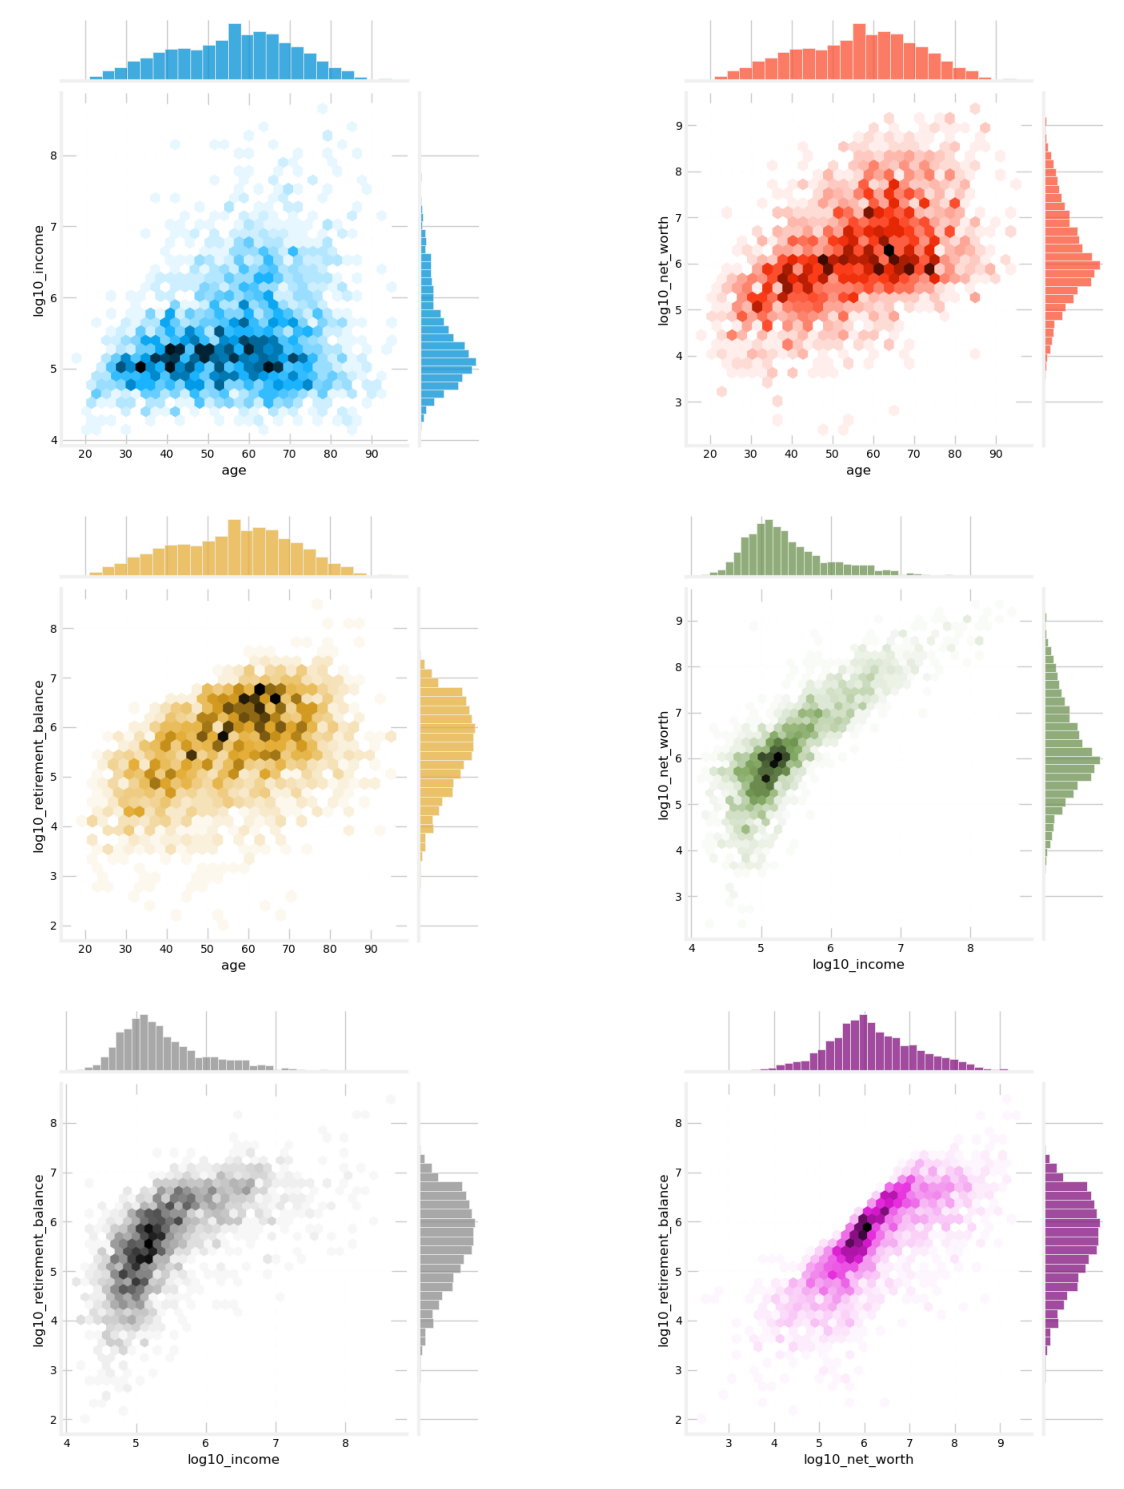

In [28]:
cols = log_result.columns.to_list()
combinations = list(itertools.combinations(cols, 2))
n = len(combinations)

# Compute grid size (square-ish)
rows = int(np.ceil(n/2))
# fig, axes = plt.subplots(rows, 2, figsize=(12, rows*5))

# Flatten axes for easy indexing
# axes = axes.flatten()

imgs = []
for i, (x, y) in enumerate(combinations):
    # Create jointplot for each pair
    jp = sns.jointplot(data=log_result, x=x, y=y, kind='hex', color=sns.color_palette(palette_538)[i]);
    # Move jointplot figure into our axes grid
    # g.fig.set_size_inches(6, 5);

    buf = BytesIO()
    jp.fig.savefig(buf, format="png")
    plt.close(jp.fig)
    buf.seek(0)
    img = Image.open(buf)
    imgs.append(img)

fig, axs = plt.subplots(rows, 2, figsize=(15, 15))

for k, img in enumerate(imgs):
    
    i = k // 2 # row
    j = k % 2 # column

    axs[i,j].imshow(img)
    axs[i,j].axis('off')

plt.tight_layout()
plt.show()

del cols, combinations, n, rows, fig, axs, k, img, jp, i, x, y

We will excise the most extreme values:

In [29]:
def remove_extremes(df, lower_q=0.01, upper_q=0.99):
    """
    Remove rows where any numeric column is outside the specified percentile bounds.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing numeric columns to check.
    lower_q : float, optional
        Lower percentile threshold (default is 0.01).
    upper_q : float, optional
        Upper percentile threshold (default is 0.99).

    Returns
    -------
    pd.DataFrame
        A copy of the dataframe with rows containing extreme values excised.
    """

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    mask = np.ones(len(df), dtype=bool)  # start with all True

    for col in numeric_cols:
        
        if col == 'age':
            continue
        
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        mask &= df[col].between(lower, upper)  # keep only values within bounds

    return df.loc[mask].copy()  # excise rows with extremes

In [30]:
log_result = remove_extremes(log_result, lower_q=0.01, upper_q=0.99)

display(log_result)

,age,log10_income,log10_net_worth,log10_retirement_balance
0,70.0,4.561678,5.803020,5.422261
1,46.0,5.351854,5.859006,5.301030
2,68.0,5.667057,7.638642,5.990516
3,74.0,5.169241,6.324817,6.477411
4,74.0,5.436636,6.837477,6.275173
...,...,...,...,...
2644,63.0,5.962596,7.335667,6.301898
2645,69.0,5.421180,6.351100,6.447158
2646,55.0,6.273840,6.825569,6.590262
2647,50.0,5.195158,5.859709,6.046261


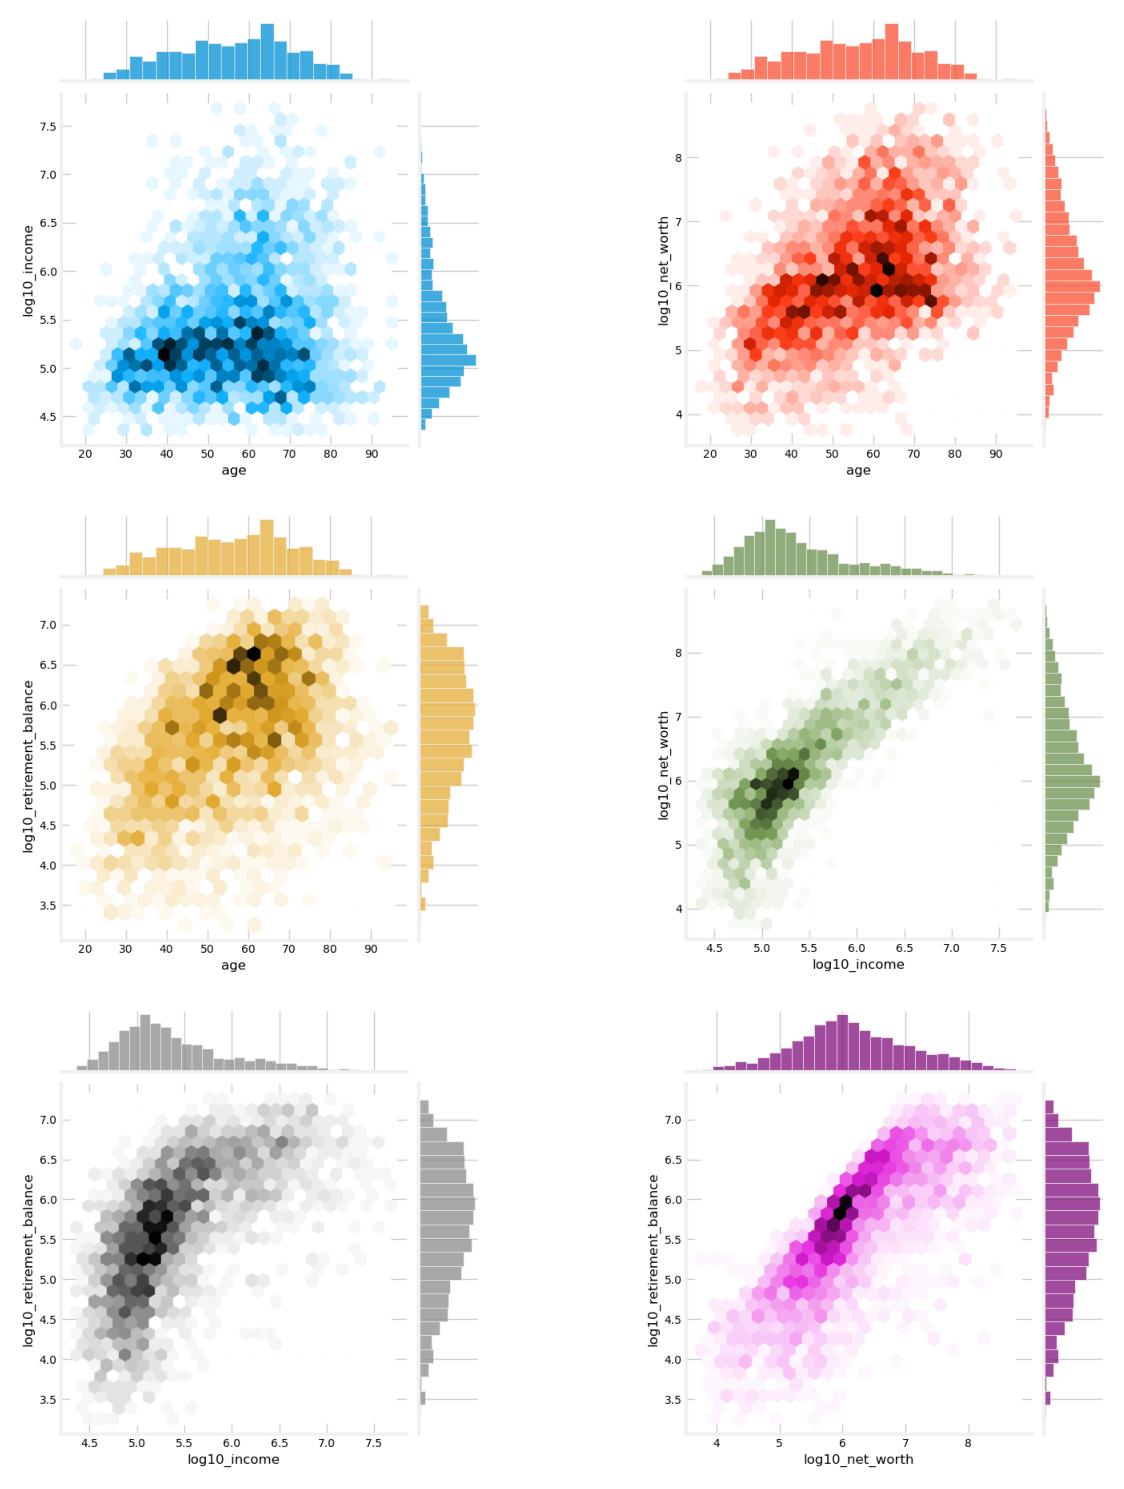

In [31]:
cols = log_result.columns.to_list()
combinations = list(itertools.combinations(cols, 2))
n = len(combinations)

# Compute grid size (square-ish)
rows = int(np.ceil(n/2))
# fig, axes = plt.subplots(rows, 2, figsize=(12, rows*5))

# Flatten axes for easy indexing
# axes = axes.flatten()

imgs = []
for i, (x, y) in enumerate(combinations):
    # Create jointplot for each pair
    jp = sns.jointplot(data=log_result, x=x, y=y, kind='hex', color=sns.color_palette(palette_538)[i]);
    # Move jointplot figure into our axes grid
    # g.fig.set_size_inches(6, 5);

    buf = BytesIO()
    jp.fig.savefig(buf, format="png")
    plt.close(jp.fig)
    buf.seek(0)
    img = Image.open(buf)
    imgs.append(img)

fig, axs = plt.subplots(rows, 2, figsize=(15, 15))

for k, img in enumerate(imgs):
    
    i = k // 2 # row
    j = k % 2 # column

    axs[i,j].imshow(img)
    axs[i,j].axis('off')

plt.tight_layout()
plt.show()

del cols, combinations, n, rows, fig, axs, k, img, jp, i, x, y

#### Generating Synthetic Data

From these distributions, how do we generate our mock investor pupulation? We can use Gaussian Multivariate copulas, which will capture the correlations and non-linear nature of the data, or more sophisticated CTGANs (Conditional Tabular Generative Adversarial Networks).

##### Gaussian Multivariate Copulas

Importing:

In [32]:
# from sklearn.preprocessing import PowerTransformer

# from copulas.multivariate import GaussianMultivariate, VineCopula

# # univariate classes I might use:
# from copulas.univariate.gaussian_kde import GaussianKDE
# from copulas.univariate.student_t import StudentTUnivariate
# from copulas.univariate.truncated_gaussian import TruncatedGaussian
# from copulas.univariate.gamma import GammaUnivariate

# # from copulas.visualization import scatter_3d, compare_3d

Transforming the data:

In [33]:
# transformer = PowerTransformer(method='yeo-johnson')

# Xtrans = log_result.copy()
# cols = Xtrans.columns.to_list()
# Xtrans[cols] = transformer.fit_transform(Xtrans[cols])

Checking distribution:

In [34]:
# combinations = list(itertools.combinations(cols, 2))
# n = len(combinations)

# # Compute grid size (square-ish)
# rows = int(np.ceil(n/2))
# # fig, axes = plt.subplots(rows, 2, figsize=(12, rows*5))

# # Flatten axes for easy indexing
# # axes = axes.flatten()

# imgs = []
# for i, (x, y) in enumerate(combinations):
#     # Create jointplot for each pair
#     jp = sns.jointplot(data=Xtrans, x=x, y=y, kind='hex', color=sns.color_palette(palette_538)[i]);
#     # Move jointplot figure into our axes grid
#     # g.fig.set_size_inches(6, 5);

#     buf = BytesIO()
#     jp.fig.savefig(buf, format="png")
#     plt.close(jp.fig)
#     buf.seek(0)
#     img = Image.open(buf)
#     imgs.append(img)

# fig, axs = plt.subplots(rows, 2, figsize=(15, 15))

# for k, img in enumerate(imgs):
    
#     i = k // 2 # row
#     j = k % 2 # column

#     axs[i,j].imshow(img)
#     axs[i,j].axis('off')

# plt.tight_layout()
# plt.show()

# del combinations, n, rows, fig, axs, k, img, jp, i, x, y

Fitting the model:

In [35]:
# # 1) Choose per-column univariate models
# distribution = {"age":GaussianKDE,
#                 "log10_income":GaussianKDE,
#                 "log10_net_worth":GaussianKDE,
#                 "log10_retirement_balance":GaussianKDE}

# # 2) Build GaussianMultivariate with explicit distribution map
# copula_model = GaussianMultivariate(distribution=distribution,
#                                     random_state=1)

# # 3) Fit to data
# copula_model.fit(Xtrans)

We can then generate our synthetic data...

In [36]:
# copula_model.set_random_state(0) # fix global RNG
# synth_data = copula_model.sample(num_rows=175_000)

... transform back...

In [37]:
# synth_data[cols] = transformer.inverse_transform(synth_data[cols])
# synth_data.to_csv(input_data_dir+"full_synth_copula_investors.csv")

# del transformer, Xtrans

... re-load for pre-processing...

In [38]:
# synth_data = pd.read_csv(input_data_dir+"full_synth_copula_investors.csv", index_col=0)

... clip extremes again...

In [39]:
# synth_data = remove_extremes(synth_data)

... limit to ages at or above 19 and below 95...

In [40]:
# synth_data = synth_data[(synth_data['age'] >= 19) & (synth_data['age'] < 95)]

... limit to 100,000...

In [41]:
# synth_data2 = synth_data.sample(n=100_000)

... reindex...

In [42]:
# synth_data2.reset_index(drop=True, inplace=True)

... describe...

In [43]:
# display(synth_data2)
# synth_data2.describe()

... and save:

In [44]:
# synth_data2.to_csv(input_data_dir+"synth_copula_investors.csv")
# del synth_data2

If the cells above are commented out, that means that we have already generated it, and we can just import it:

In [45]:
synth_data = pd.read_csv(input_data_dir+"synth_copula_investors.csv", index_col=0)

display(synth_data)
synth_data.describe()

,age,log10_income,log10_net_worth,log10_retirement_balance
0,61.120452,6.878753,6.976291,6.663040
1,58.836340,5.358455,6.314121,4.843357
2,54.163989,5.491020,6.868280,6.465119
3,61.334973,6.220790,6.699662,5.841446
4,65.683682,5.754335,7.843766,6.746177
...,...,...,...,...
99995,50.540938,6.078498,7.335743,6.676968
99996,40.688313,5.680436,6.406751,5.481426
99997,42.684359,5.826367,5.757174,6.333246
99998,69.907968,6.047187,6.789567,5.689068


,age,log10_income,log10_net_worth,log10_retirement_balance
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,56.129572,5.401311,6.170730,5.626168
std,14.709086,0.583216,0.894048,0.787275
min,19.008067,4.456713,4.053429,3.527715
25%,44.987189,4.976012,5.553674,5.074511
50%,57.081878,5.263704,6.091864,5.694854
75%,67.028550,5.711345,6.762767,6.239514
max,94.989528,7.352495,8.460227,7.138985


Let us look at the plots:

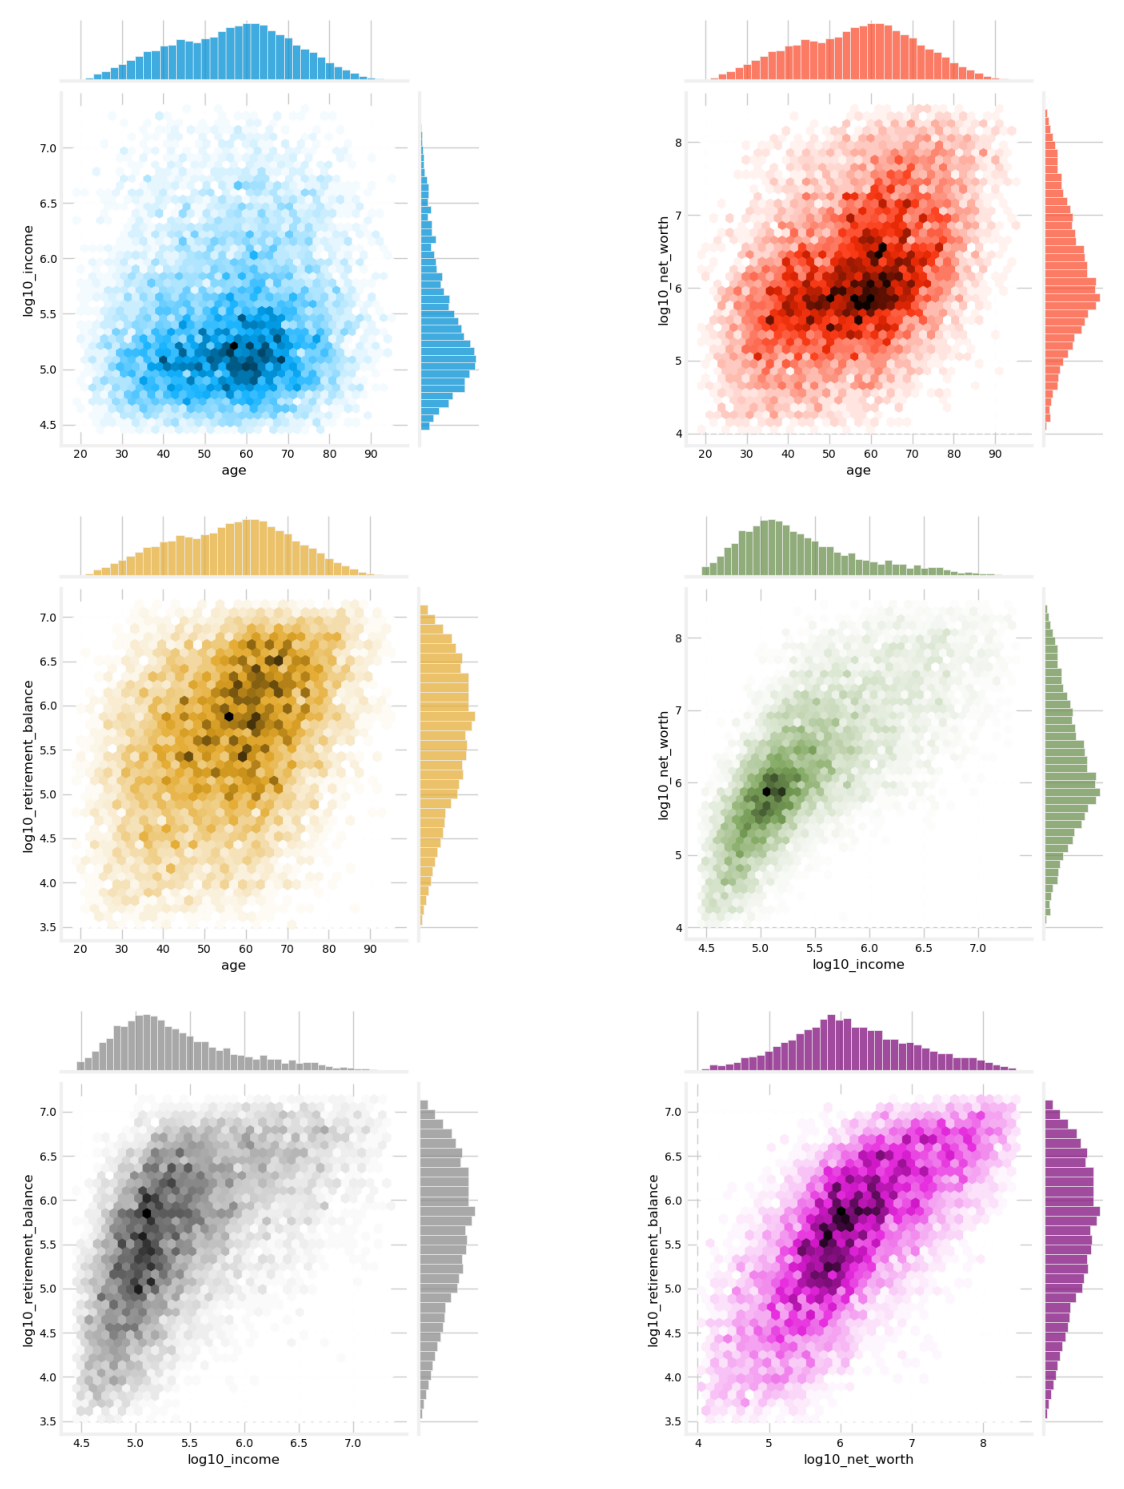

In [46]:
sample_data = synth_data.sample(frac=0.1)

cols = sample_data.columns.to_list()
combinations = list(itertools.combinations(cols, 2))
n = len(combinations)

# Compute grid size (square-ish)
rows = int(np.ceil(n/2))
# fig, axes = plt.subplots(rows, 2, figsize=(12, rows*5))

# Flatten axes for easy indexing
# axes = axes.flatten()

imgs = []
for i, (x, y) in enumerate(combinations):
    # Create jointplot for each pair
    jp = sns.jointplot(data=sample_data, x=x, y=y, kind='hex', color=sns.color_palette(palette_538)[i]);
    # Move jointplot figure into our axes grid
    # g.fig.set_size_inches(6, 5);

    buf = BytesIO()
    jp.fig.savefig(buf, format="png")
    plt.close(jp.fig)
    buf.seek(0)
    img = Image.open(buf)
    imgs.append(img)

fig, axs = plt.subplots(rows, 2, figsize=(15, 15))

for k, img in enumerate(imgs):
    
    i = k // 2 # row
    j = k % 2 # column

    axs[i,j].imshow(img)
    axs[i,j].axis('off')

plt.tight_layout()
plt.show()

del sample_data, combinations, n, rows, fig, axs, k, img, jp, i, x, y

In [47]:
del cols

##### CTGANs

Let us now try CTGANs.

In [48]:
# ?CTGANSynth

Detecting the metadata from our data:

In [49]:
# from sdv.metadata import Metadata

# metadata = Metadata.detect_from_dataframe(
#     data=log_result,
#     table_name='log_investors')

Training the CTGAN:

In [50]:
# from sdv.single_table import CTGANSynthesizer as CTGANSynth

# ctgan_model = CTGANSynth(metadata)
# ctgan_model.fit(log_result)

Generating and saving the synthetic data:

In [51]:
# synth_data = ctgan_model.sample(num_rows=100_000)
# synth_data.to_csv(input_data_dir+"synth_ctgan_investors.csv")

If the above cells are commented out, it means we have already synthetized the data, and therefore all we have to do is import it now:

In [52]:
synth_data_ctgan = pd.read_csv(input_data_dir+"synth_ctgan_investors.csv", index_col=0)

display(synth_data_ctgan)

,age,log10_income,log10_net_worth,log10_retirement_balance
0,40.0,5.487021,6.281669,6.319853
1,60.0,4.796932,4.534968,6.112072
2,69.0,5.708108,6.640638,7.195894
3,51.0,4.857052,7.431366,6.581899
4,84.0,4.968282,4.438058,4.603325
...,...,...,...,...
49995,82.0,5.245562,7.853558,6.109578
49996,70.0,4.855796,8.657961,5.215414
49997,68.0,5.805733,2.490211,5.180893
49998,52.0,4.817345,6.634175,5.060597


Joint plots:

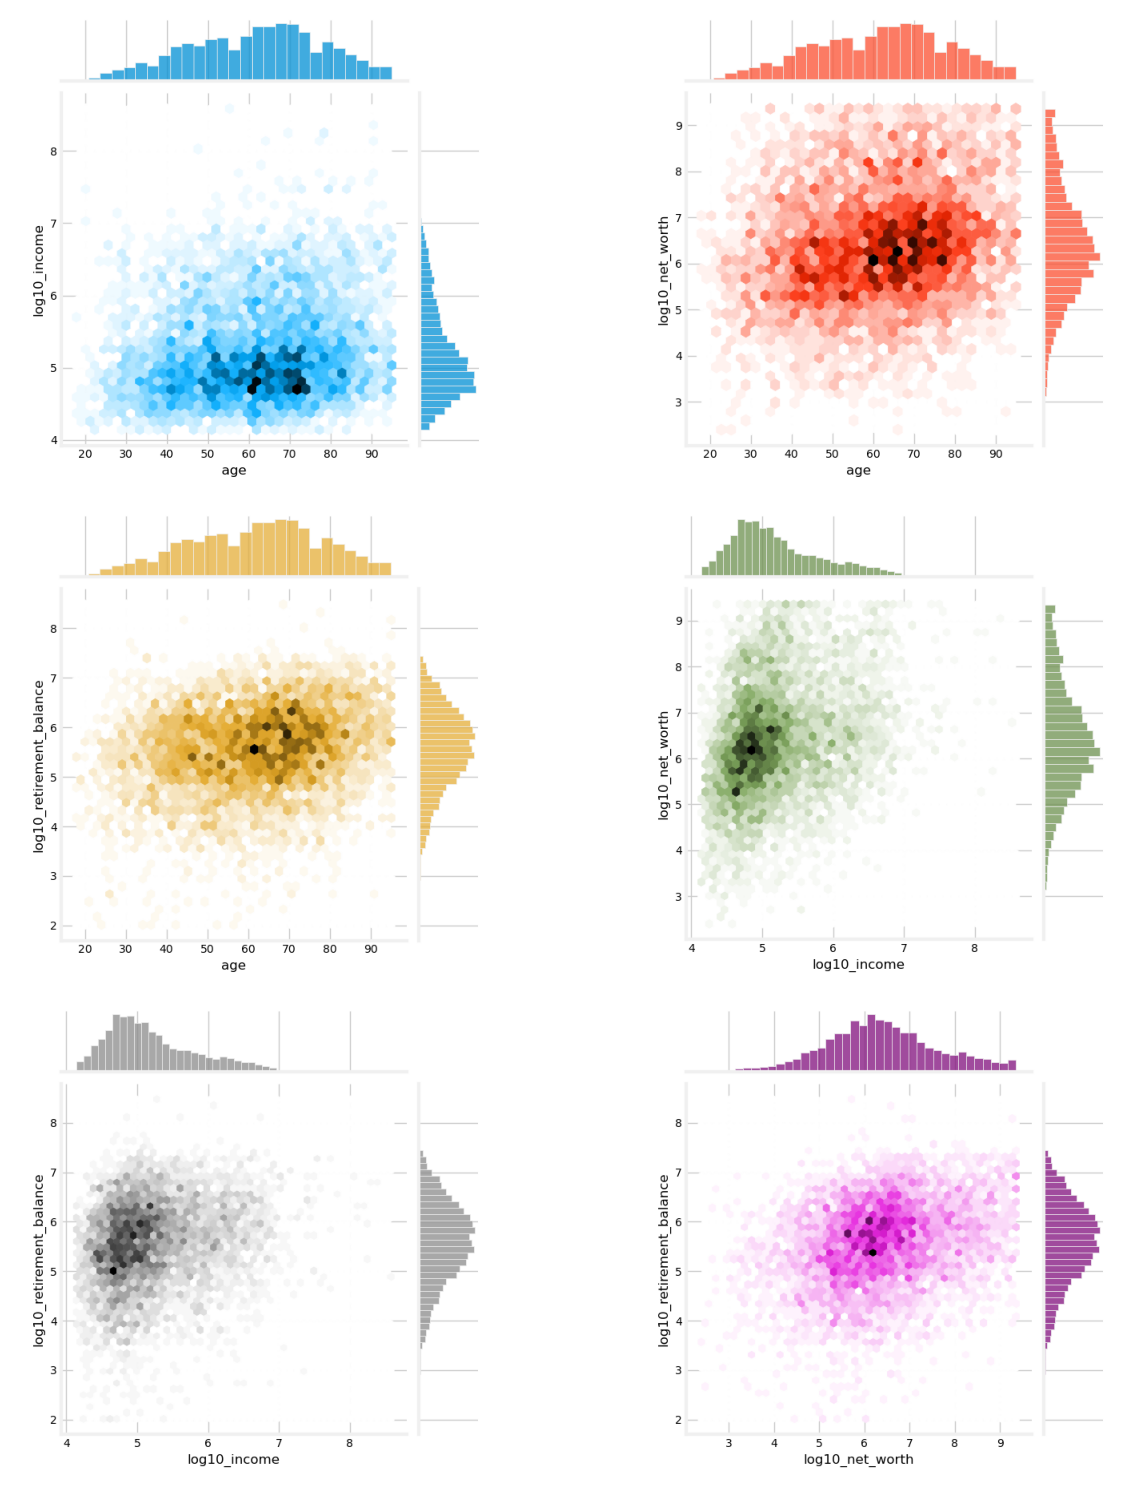

In [53]:
sample_data = synth_data_ctgan.sample(frac=0.1, random_state=11)

cols = sample_data.columns.to_list()
combinations = list(itertools.combinations(cols, 2))
n = len(combinations)

# Compute grid size (square-ish)
rows = int(np.ceil(n/2))
# fig, axes = plt.subplots(rows, 2, figsize=(12, rows*5))

# Flatten axes for easy indexing
# axes = axes.flatten()

imgs = []
for i, (x, y) in enumerate(combinations):
    # Create jointplot for each pair
    jp = sns.jointplot(data=sample_data, x=x, y=y, kind='hex', color=sns.color_palette(palette_538)[i]);
    # Move jointplot figure into our axes grid
    # g.fig.set_size_inches(6, 5);

    buf = BytesIO()
    jp.fig.savefig(buf, format="png")
    plt.close(jp.fig)
    buf.seek(0)
    img = Image.open(buf)
    imgs.append(img)

fig, axs = plt.subplots(rows, 2, figsize=(15, 15))

for k, img in enumerate(imgs):
    
    i = k // 2 # row
    j = k % 2 # column

    axs[i,j].imshow(img)
    axs[i,j].axis('off')

plt.tight_layout()
plt.show()

del sample_data, cols, combinations, n, rows, fig, axs, k, img, jp, i, x, y

Yikes, that is not as good. Since this is just a toy project, I will not try to improve upon the CTGAN, and simply use the copulas instead.

#### Clean

In [54]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name, result

### Investors: Contributions

Let us now consider how the investors contribute to their account, as a percentage of their income.

We simulate the contributions $r$ as a random sample from a beta distribution:

$r \sim 0.2 \times \mathrm{Beta}(\alpha, \beta) = 0.2 \times \frac{x^{\alpha-1}(1-x)^{\beta-1}}{\mathrm{B}(\alpha, \beta)}$,

where we have multiplied by $0.2$ to reflect that people, at most, will contribute $20\%$ of their income.

We shall pick some arbitrary numbers, $\alpha = 3$ and $\beta = 4.7$, which result in a right-skewed distribution, with mostly small percentages, but with a mode around $7\%$ (once we rescale by $0.2$), which is where most US 401(k) contributions are.

In [55]:
# rng = np.random.default_rng(seed=42)  # create a reproducible generator
# pcts = np.round(rng.beta(a=3, b=4.7, size=100_000)*0.2 * 100 * 4)/4 # rounds to the nearest 0.025

# pcts = pd.DataFrame(pcts, columns=['current_pct'])

Let us now compute the employee contributions. We will use a simple $100\%$ match up to $x\%$, where x is going to be a random draw from the same distribution.

In [56]:
# rng = np.random.default_rng(seed=10)
# cap = np.round(rng.beta(a=3, b=4.7, size=100_000)*0.2 * 100 * 4)/4

Computing matches:

In [57]:
# pcts['employer_cap'] = cap

# pcts.to_csv(input_data_dir+"synth_contributions.csv")

# del cap

If the above cells are commented out, it means we have already generated this data, so we just import it.

In [58]:
pcts = pd.read_csv(input_data_dir+"synth_contributions.csv", index_col=0)
display(pcts)

,current_pct,employer_cap
0,6.75,6.00
1,8.00,5.25
2,9.75,10.75
3,8.00,9.00
4,10.50,9.00
...,...,...
99995,13.00,8.00
99996,7.25,1.75
99997,14.50,4.75
99998,9.75,5.50


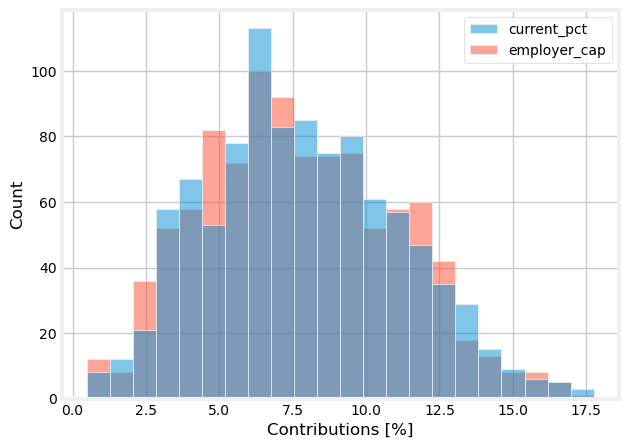

In [59]:
sns.histplot(pcts.sample(frac=0.01, random_state=10))
plt.xlabel("Contributions [%]");

In [60]:
del pcts

### Investors: Engagement & Activity

We now focus on how do the investors engage with ABC's Investments' ecosystem. We will focus on covariates such as last_login, login_frequency, email_check_frequency, and such.

#### Last login

We begin by modeling the last time the users logged in to ABC's Investments platform. We assume that they log in roughly once a month (30 days) or so, and that this is roughly uniform across all kinds of users.

In [61]:
# rng = np.random.default_rng(seed=1)
# logindays = np.round(rng.exponential(scale=30, size=100_000), 1)

# logindays = pd.DataFrame(logindays, columns=['last_login'])
# logindays.to_csv(input_data_dir+"synth_last_login.csv")

In [62]:
logindays = pd.read_csv(input_data_dir+"synth_last_login.csv", index_col=0)
display(logindays)

,last_login
0,32.2
1,9.3
2,161.3
3,11.0
4,3.5
...,...
99995,5.4
99996,30.0
99997,0.1
99998,21.1


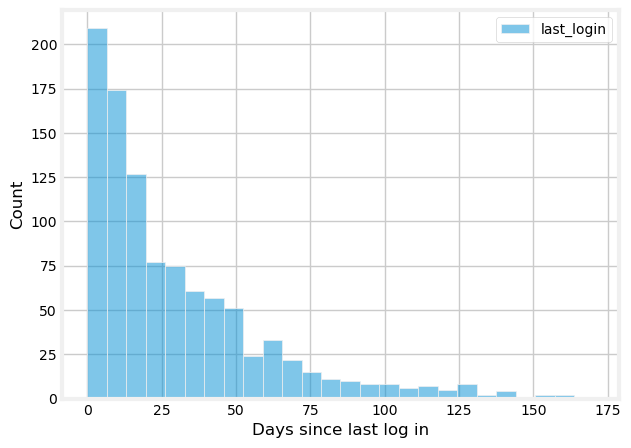

In [63]:
sns.histplot(logindays.sample(frac=0.01))
plt.xlabel("Days since last log in");

#### Account Tenure

Let us now model the account tenure. We will do this by capping, at the lower end, from last_login, and at the upper end, by min(age_of_ABC_investments, age_of_user - 18). We will simulate the distribution as an exponential.

After trial and error, we fix upon a default scale of 9.5 years, in order to get a median tenure of ~6 (which closely matches the data from ABC Investments)

In [64]:
from scipy.stats import truncexpon

In [65]:
abc_age = 50 # 50 years!

def tenure_fn(age, lastlogin, scale=9.5, random_state=1):
    """
    Simulate retirement account tenure using a truncated exponential distribution.

    The lower bound is derived from the last login date (converted to years), while the upper bound is capped by the minimum of the user's age minus 18 and the maximum allowed age of ABC investments.

    Args:
        age (array-like or float): User age(s) in years.
        lastlogin (array-like, float, or pandas object): Days since last login, converted internally to years.
        scale (float, optional): Scale parameter for the exponential distribution.
            Defaults to 9.5.
        random_state (int, optional): Random seed for reproducibility.
            Defaults to 1.

    Returns:
        float or ndarray: Simulated tenure(s) in years.
    """

    try:
        n = len(age)
    except TypeError:
        n = 1

    lower_end = (lastlogin/365) # convert days into years
    upper_end = np.minimum(np.maximum(age-18., 0), abc_age)

    if isinstance(lower_end, pd.DataFrame):
        lower_end = lower_end.squeeze().to_numpy()
    elif isinstance(lower_end, pd.Series):
        lower_end = lower_end.to_numpy()
    
    if isinstance(upper_end, pd.DataFrame):
        upper_end = upper_end.squeeze().to_numpy()
    elif isinstance(upper_end, pd.Series):
        upper_end = upper_end.to_numpy()
    
    bvals = (upper_end - lower_end)/scale

    # print(bvals)

    tenure_arr = truncexpon.rvs(b=bvals, loc=lower_end, scale=scale, random_state=random_state)

    if np.isscalar(tenure_arr):
        return float(tenure_arr)
    else:
        return tenure_arr

    # return bvals

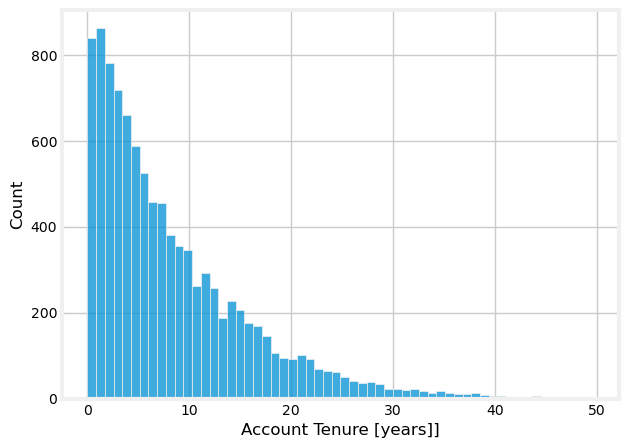

In [66]:
sns.histplot(pd.Series(tenure_fn(synth_data['age'], logindays)).sample(frac=0.1, random_state=10))
plt.xlabel("Account Tenure [years]]");

#### Time online (_e.g._ in email inbox)

Let us now model how much time each user spends in their email inbox.

I don't have data, but I have some anecdotal experience. Younger generations spend more time online than the older ones, and according to some cursory Google searches (from an Adobe survey cited [here](https://www.cnbc.com/2018/08/22/millennials-spend-more-time-on-their-email-than-any-other-generation.html), but that I have been unable to find), we are talking about 6.5 hrs for millenials (25 -- 24 y.o.), while 5 hrs for older people (> 35 y.o.).

Let us further assume, for simplicity, that this same time is time both on a PC and on their phones.

So let us take the mean of the ages in question (assuming the upper end of the larger age group is 65 y.o.), the fraction of hours in the day spent in the email inbox/on their phones, and draw a line through it.

In particular, if we have the data `[[x_1, y_1], [x_2, y_2]]`, then the formula for the line is simply:

$y(x) = m x + b$,

where $m = \frac{y_2 - y_1}{x_2 - x_1}$ and $b = \frac{x_2 y_1 - x_1 y_2}{x_2 - x_1}$.

In [67]:
# the data
age_time_data = np.array([[(25+34)/2, 6.5/24], [(65+35)/2, 5./24]])

# the function
def inbox_time_fn(age, data=age_time_data, noise=False, noise_sigma=(0.5/24), random_state=1):
    """
    Estimate time spent in the email inbox based on age using a linear interpolation.

    Optionally, add Gaussian noise to the estimate.

    Args:
        age (array-like or float): User age(s) in years.
        data (ndarray, optional): 2D array with age in column 0 and average email time in column 1. Defaults to `age_time_data`.
        noise (bool, optional): Whether to add Gaussian noise. Defaults to False.
        noise_sigma (float, optional): Standard deviation of noise in days.
            Defaults to 0.5/24 (half an hour). 
        random_state (int, optional): Seed for random number generation. Defaults to 1.

    Returns:
        ndarray or float: Estimated email time(s), rounded to 3 decimal places.
    """

    age_data = data[:,0]
    time_data = data[:,1]

    slope = float((time_data[-1] - time_data[0])/(age_data[-1] - age_data[0]))

    intercept = float((age_data[-1]*time_data[0] - age_data[0]*time_data[-1])/(age_data[-1] - age_data[0]))

    email_time = slope*age + intercept

    if noise:
        rng = np.random.default_rng(seed=random_state)
        noise_arr = rng.normal(loc=0., scale=noise_sigma, size=len(email_time))
        email_time += noise_arr

    return np.round(email_time, 3)

Let us now plot the results:

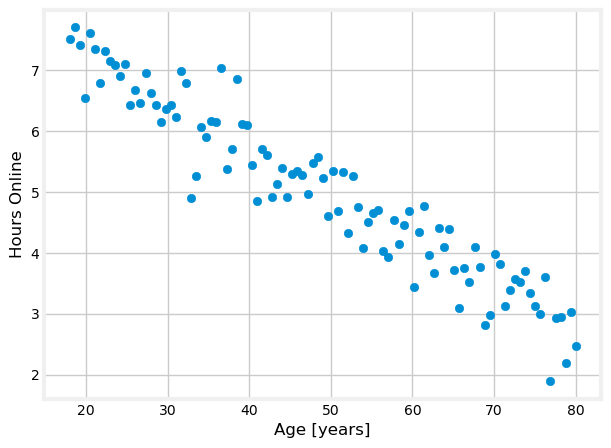

In [68]:
age_arr = np.linspace(18, 80, 101)
time_arr = inbox_time_fn(age_arr, noise=True)

plt.scatter(age_arr, time_arr*24)
plt.xlabel("Age [years]");
plt.ylabel("Hours Online");

del age_arr, time_arr

### Investors: Final Data

#### Concatenating Data

We have almost all that we need to construct our synthetic data.

We begin by importing all the data we have:

In [69]:
inv_data = pd.read_csv(input_data_dir+"synth_copula_investors.csv", index_col=0) # investor data

pct_data = pd.read_csv(input_data_dir+"synth_contributions.csv", index_col=0) # contributions

login_data = pd.read_csv(input_data_dir+"synth_last_login.csv", index_col=0)

Let us generate a random user ID:

In [70]:
unique_ids = np.random.choice(
    np.arange(100_000, 1_000_000),  # all possible 6-digit numbers
    size=len(inv_data),             # how many you want
    replace=False                   # no duplicates
)

final_data = inv_data.copy()
final_data.insert(0, 'user_id', pd.Series(unique_ids))

display(final_data)

,user_id,age,log10_income,log10_net_worth,log10_retirement_balance
0,367398,61.120452,6.878753,6.976291,6.663040
1,473384,58.836340,5.358455,6.314121,4.843357
2,168619,54.163989,5.491020,6.868280,6.465119
3,581083,61.334973,6.220790,6.699662,5.841446
4,182358,65.683682,5.754335,7.843766,6.746177
...,...,...,...,...,...
99995,601703,50.540938,6.078498,7.335743,6.676968
99996,513665,40.688313,5.680436,6.406751,5.481426
99997,854622,42.684359,5.826367,5.757174,6.333246
99998,187081,69.907968,6.047187,6.789567,5.689068


Concatenate to it the contributions data and the login data:

In [71]:
final_data = pd.concat([final_data, pct_data, login_data], axis=1)

display(final_data)

,user_id,age,log10_income,log10_net_worth,log10_retirement_balance,current_pct,employer_cap,last_login
0,367398,61.120452,6.878753,6.976291,6.663040,6.75,6.00,32.2
1,473384,58.836340,5.358455,6.314121,4.843357,8.00,5.25,9.3
2,168619,54.163989,5.491020,6.868280,6.465119,9.75,10.75,161.3
3,581083,61.334973,6.220790,6.699662,5.841446,8.00,9.00,11.0
4,182358,65.683682,5.754335,7.843766,6.746177,10.50,9.00,3.5
...,...,...,...,...,...,...,...,...
99995,601703,50.540938,6.078498,7.335743,6.676968,13.00,8.00,5.4
99996,513665,40.688313,5.680436,6.406751,5.481426,7.25,1.75,30.0
99997,854622,42.684359,5.826367,5.757174,6.333246,14.50,4.75,0.1
99998,187081,69.907968,6.047187,6.789567,5.689068,9.75,5.50,21.1


Now, we generate the account tenure...

In [72]:
final_data['acct_tenure'] = pd.Series(tenure_fn(final_data['age'],
                                                final_data['last_login'],
                                                scale=5,
                                                random_state=1))

... and the expected time each user spends in their email inbox:

In [73]:
final_data['time_online_frac'] = inbox_time_fn(final_data['age'],
                                              noise=True,
                                              random_state=1)

We now rescale the `income`, `net_worth`, and `retirement_balance` (remember we took the log10(x), and rename them:

In [74]:
# rescaling
final_data[['log10_income', 'log10_net_worth', 'log10_retirement_balance']] = final_data[['log10_income', 'log10_net_worth', 'log10_retirement_balance']].apply(lambda col: 10**col)

# renaming
final_data.rename(columns={"log10_income":"income",
                           "log10_net_worth":"net_worth",
                           "log10_retirement_balance":"retirement_balance"}, inplace=True)

#### Buckets

First, we define the following buckets, of age, income, and balance:

In [75]:
def age_bucket(age):
    """
    Categorize age into predefined buckets.

    Buckets:
        <18      : None
        18-40    : "18-40"
        41-65    : "41-65"
        >65      : ">65"

    Args:
        age (int or float): Age in years.

    Returns:
        str or None: Age bucket label.
    """

    if age < 18:
        return None
    if age < 41:
        return "18-40"
    elif age < 66:
        return "41-65"
    else:
        return ">65"


income_quartiles = dict(zip(['income_25%', 'income_50%', 'income_75%'],
                            final_data['income'].quantile(q=[0.25, 0.5, 0.75]).to_numpy()))

def income_bucket(income):
    """
    Assign income to quartile-based buckets.

    Quartiles are precomputed from `final_data['income']`.

    Args:
        income (float): Annual income.

    Returns:
        str: Income bucket label ("0-25%", "25-50%", "50-75%", ">75%").
    """

    if income <= income_quartiles["income_25%"]:
        return "0-25%"
    elif income <= income_quartiles["income_50%"]:
        return "25-50%"
    elif income <= income_quartiles["income_75%"]:
        return "50-75%"
    else:
        return ">75%"
        

networth_quartiles = dict(zip(['networth_25%', 'networth_50%', 'networth_75%'],
                            final_data['net_worth'].quantile(q=[0.25, 0.5, 0.75]).to_numpy()))

def networth_bucket(net_worth):
    """
    Assign net worth to quartile-based buckets.

    Quartiles are precomputed from `final_data['net_worth']`.

    Args:
        net_worth (float): Net worth value.

    Returns:
        str: Net worth bucket label ("0-25%", "25-50%", "50-75%", ">75%").
    """

    if net_worth <= networth_quartiles["networth_25%"]:
        return "0-25%"
    elif net_worth <= networth_quartiles["networth_50%"]:
        return "25-50%"
    elif net_worth <= networth_quartiles["networth_75%"]:
        return "50-75%"
    else:
        return ">75%"

balance_quartiles = dict(zip(['balance_25%', 'balance_50%', 'balance_75%'],
                            final_data['retirement_balance'].quantile(q=[0.25, 0.5, 0.75]).to_numpy()))

def balance_bucket(balance):
    """
    Assign retirement balance to quartile-based buckets.

    Quartiles are precomputed from `final_data['retirement_balance']`.

    Args:
        balance (float): Retirement account balance.

    Returns:
        str: Balance bucket label ("0-25%", "25-50%", "50-75%", ">75%").
    """

    if balance <= balance_quartiles["balance_25%"]:
        return "0-25%"
    elif balance <= balance_quartiles["balance_50%"]:
        return "25-50%"
    elif balance <= balance_quartiles["balance_75%"]:
        return "50-75%"
    else:
        return ">75%"

Assign buckets/cohorts

In [76]:
# age
final_data['age_cohort'] = final_data['age'].map(lambda age: age_bucket(age))

# income
final_data['income_cohort'] = final_data['income'].map(lambda income: income_bucket(income))

# net_worth
final_data['networth_cohort'] = final_data['net_worth'].map(lambda ntw: networth_bucket(ntw))

# balance
final_data['balance_cohort'] = final_data['retirement_balance'].map(lambda bal: balance_bucket(bal))

#### Saving Data

In [77]:
display(final_data)

,user_id,age,income,net_worth,retirement_balance,current_pct,employer_cap,last_login,acct_tenure,time_online_frac,age_cohort,income_cohort,networth_cohort,balance_cohort
0,367398,61.120452,7.564024e+06,9.468704e+06,4.602986e+06,6.75,6.00,32.2,2.785594,0.182,41-65,>75%,>75%,>75%
1,473384,58.836340,2.282731e+05,2.061202e+06,6.971992e+04,8.00,5.25,9.3,6.392434,0.199,41-65,50-75%,50-75%,0-25%
2,168619,54.163989,3.097562e+05,7.383802e+06,2.918227e+06,9.75,10.75,161.3,0.442489,0.203,41-65,50-75%,>75%,>75%
3,581083,61.334973,1.662608e+06,5.007976e+06,6.941380e+05,8.00,9.00,11.0,1.829825,0.147,41-65,>75%,50-75%,50-75%
4,182358,65.683682,5.679820e+05,6.978561e+07,5.574125e+06,10.50,9.00,3.5,0.803075,0.179,41-65,>75%,>75%,>75%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,601703,50.540938,1.198114e+06,2.166423e+07,4.753001e+06,13.00,8.00,5.4,7.268112,0.207,41-65,>75%,>75%,>75%
99996,513665,40.688313,4.791107e+05,2.551238e+06,3.029883e+05,7.25,1.75,30.0,6.422395,0.238,18-40,50-75%,50-75%,25-50%
99997,854622,42.684359,6.704514e+05,5.717077e+05,2.154000e+06,14.50,4.75,0.1,8.361481,0.201,41-65,>75%,25-50%,>75%
99998,187081,69.907968,1.114774e+06,6.159805e+06,4.887288e+05,9.75,5.50,21.1,4.252460,0.146,>65,>75%,>75%,25-50%


Let us save the data!

In [78]:
# final_data.to_csv(input_data_dir+"synth_final_inv.csv")

In [79]:
del synth_data, logindays, inv_data, pct_data, login_data, unique_ids, final_data

### Cleanup

In [80]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

## 3. A/B Test

Now that we have our investor data, it is time to prepare the A/B test. In order to do that, we need to:

1. Simulate the baseline/control conversion rate (need to use logistic regression)
2. Simulate the treatment conversion rate
3. Fix the randomization procedure
4. Compute the details of the A/B experiment ($\alpha$, $\beta$, MDE, $n_{A/B}$, etc.)
5. Simulate the experiment, as well as the monitoring procedure

### Loading investor data

Let us just load our entire data.

In [81]:
full_data = pd.read_csv(input_data_dir+"synth_final_inv.csv", index_col=0)

In [82]:
full_data.describe()

,user_id,age,income,net_worth,retirement_balance,current_pct,employer_cap,last_login,acct_tenure,time_online_frac
count,100000.000000,100000.000000,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,549397.506920,56.129572,8.221042e+05,1.109554e+07,1.435761e+06,7.811748,7.786893,29.879831,4.890799,0.189549
std,259672.336011,14.709086,2.051501e+06,3.006769e+07,2.193058e+06,3.310969,3.312753,29.749018,4.709759,0.049504
min,100004.000000,19.008067,2.862283e+04,1.130914e+04,3.370659e+03,0.000000,0.250000,0.000000,0.001529,0.008000
25%,324484.750000,44.987189,9.462623e+04,3.578280e+05,1.187164e+05,5.250000,5.250000,8.600000,1.470637,0.154000
50%,548999.000000,57.081878,1.835287e+05,1.235559e+06,4.952837e+05,7.500000,7.500000,20.700000,3.461045,0.188000
75%,773851.750000,67.028550,5.144520e+05,5.791179e+06,1.735857e+06,10.000000,10.000000,41.600000,6.809782,0.225000
max,999997.000000,94.989528,2.251621e+07,2.885540e+08,1.377162e+07,19.000000,19.250000,363.100000,45.838242,0.379000


### Modeling Conversion Rate

We are interested in the conversion rate $p$ over a given amount of time $T$. Thus, we are interested in the chances of a given investor or client increasing his retirement contributions in, say, $T=30 \text{ days}$.

We will model $p$ with a logistic regression.

The logit is:

$\eta_i = \boldsymbol{\beta} \cdot \mathbf{X}_i + \beta_0$, and the logistic regression models the probability as a sigmoid of the logit:

$p_i = \sigma(\eta_i) \equiv \frac{1}{1 + e^{-\eta_i}}$.

Note that this means

$\frac{p_i}{1-p_i} = e^{\eta_i}$

i.e.

$\eta_i = \ln\left( \frac{p_i}{1-p_i} \right)$.

**N.B.: do NOT confuse the conversion rate $p$ with the contribution percentage!**

In [83]:
from scipy.special import expit as logistic
from scipy.optimize import fsolve

First, a note about the baseline conversion rate $p_{\rm base} \equiv p_0$.

The conversion rate $p_A$ of the control arm A will be equal to it: $p_A = p_0$, while that for the arm B, $p_B$, will include the effect of the treatment.

**N.B.:** This baseline conversion rate is different from the reference rate $p_{\rm ref} = p_*$ defined below, although they are all similar.

In order to model the conversion, we need to fix the coefficients $(\boldsymbol{\beta}, \, \beta_0)$ of the logit. We can do that by:

1. $\boldsymbol{\beta}$: There are two cases:

_Continuous covariates:_ performing a Taylor expansion around a reference probability $p_*$ that is similar to all other probabilities of interest (such as $p_0 = p_A$, and $p_B$):

$\frac{d p}{d X_j} = \frac{d p}{d \eta} \frac{d \eta}{d X_j} = \left( \frac{d \eta}{d p} \right)^{-1} \frac{d \eta}{d X_j} = \beta_j \, p(1 - p)$,

where $X_j$ is the $j$-th covariate. Thus, for a reference $p_*$, a small change $\Delta X_j$ that corresponds to a small change $\Delta p$ means that:

$\Rightarrow \quad \beta_j \approx \frac{\Delta p}{p_*(1-p_*) \Delta X_j} = \frac{1}{(1-p_*)}\frac{\Delta p / p_*}{\Delta X_j}$.

Once again, since we have a specific conversion rate of interest in mind, we take $p_*$ close to $p_A$.

_Discrete covariates:_ we write

$\beta_j = \ln(\mathrm{OR})$,

where $\mathrm{OR}$ is the ``odds ratio'', i.e., what the presence of the covariate does for the probability compared to the absence:

$\mathrm{OR} = \frac{p_{X=1}/(1 - p_{X=1})}{p_{X=0}/(1 - p_{X=0})}$
   
2. $\beta_0$: it can be found by first computing the population average $\overline{p} = \frac{1}{N}\sum\limits_{i=1}^{N} \, \sigma(\eta(x_i))$, making it equal to the baseline conversion $p_0 = p_A$, and solving for $\beta_0$ numerically.

**N.B.** on $\boldsymbol{\beta}$:
In this section we fix them once and for all, for some given reference conversion rate $p_*$ in the vicinity of the baseline rate $p_{\rm base}$ and $p_B$ values of interest.

Once we perform the A/B test, we will be free to change the underlying baseline conversion rate $p_0 = p_A$ to test different scenarios. Whenever we make these changes, **we will maintain the same coefficients**. This is because these coefficients play the role of _"law of physics"_: they describe the laws that rule the underlying phenomenon (namely, the conversion rate as a function of the user's features).

The only thing that we _will_ change is the intercept: picking a new $p_{A/B}$ will leave the $\boldsymbol{\beta}$ coefficients the same (the same ``laws''), but change the intercept $\beta_0$.

But what to choose for $p_{\rm ref} = p_*$? Well, perhaps it's better if we look at the conversion probability over a long span of time.

Let us begin by assuming there is no heterogeneity (or rather, we are ignoring any difference between users), and the process of converting or not is memoryless.

Then, for example, assuming that there is a 15% chance of increasing one's contributions in a given year, then

$p_{*,\mathrm{yr}} = 0.15$.

To see that this seems reasonable, note that the chances of NOT converting in 4 years is

$(1 - p_{*,\mathrm{yr}})^4 \approx 0.52$,

a bit over a half. So one has a 50% chance of increasing one's contributions in 4 years, it seems reasonable.

Therefore, the probability of not converting in a year is:

$(1 - p_{*,\mathrm{yr}}) = 0.85 = (1 - p_{*,\mathrm{mo}})^{12} = (1 - p_{*,\mathrm{14d}})^{26}$

$\Rightarrow p_{*, \mathrm{mo.}} \approx 1.35\%$

and

$p_{*, \mathrm{14d}} \approx 0.62\%$

In [84]:
pstar = 0.0135 # this will be the reference conversion, pA and pB will be similar to it.

Begin by writing the logistic function $\sigma(\eta((\boldsymbol{\beta}, \beta_0), \mathbf{X}))$:

In [85]:
# rough scale of eta (from logit formula)
eta_scale = np.abs(np.log(pstar / (1 - pstar)))

def eta_fn(betaj_beta0, Xmatrix, noise=False, noise_sigma=(0.1*eta_scale), random_state=1):
    """
    Compute the linear predictor (eta) for a logistic model.

    eta = X * beta + beta0, optionally with additive Gaussian noise.

    Args:
        betaj_beta0 (tuple): Tuple containing array-like betas and scalar beta0.
        Xmatrix (DataFrame): Feature matrix with columns corresponding to betas.
        noise (bool, optional): Whether to add Gaussian noise. Defaults to False.
        noise_sigma (float or array-like, optional): Standard deviation of noise.
            Defaults to 0.1 * eta_scale = 0.429.
        random_state (int, optional): Seed for random number generation. Defaults to 1.

    Returns:
        float or ndarray: Linear predictor(s) eta.
    """
    
    betas, beta0 = betaj_beta0 # splitting the betas

    # beta_j*X_j
    betaX = Xmatrix.mul(betas, axis=1).to_numpy()
    
    # sum(beta_j*X_j)
    covars = np.sum(betaX, axis=1)

    # eta = beta*X + beta0 = logit(p) = ln(p/(1-p))
    eta = covars + beta0

    # trying different lengths
    try:
        n = len(eta)
    except TypeError:
        n = 1

    # add noise
    if noise:
        rng = np.random.default_rng(seed=random_state)
        noise_arr = rng.normal(loc=0., scale=noise_sigma, size=n)
        eta += noise_arr

    if len(eta) == 1:
        return float(eta[0])
    else:
        return eta

    

def sigma_fn(betaj_beta0, Xmatrix, **eta_kwargs):
    """
    Compute the logistic function (sigma) for a given linear predictor.

    sigma = 1 / (1 + exp(-eta)), where eta = X * beta + beta0.

    Args:
        betaj_beta0 (tuple): Tuple containing array-like betas and scalar beta0.
        Xmatrix (DataFrame): Feature matrix with columns corresponding to betas.
        **eta_kwargs: Additional arguments passed to `eta_fn` (e.g., noise, noise_sigma, random_state).

    Returns:
        float or ndarray: Logistic function values corresponding to eta.
    """

    # eta = beta*X + beta0 = logit(p) = ln(p/(1-p))
    eta = eta_fn(betaj_beta0, Xmatrix, **eta_kwargs)

    return logistic(eta)

Now the individual $\beta$'s:

$\beta_j \approx \frac{1}{(1-p_*)}\frac{\Delta p / p_*}{\Delta X_j}$

In [86]:
def beta_j(p_ref, dp_rel, dX):
    """
    Approximate a single logistic regression coefficient beta_j.

    Uses the relationship beta_j ≈ (Δp / ΔX) / (1 - p_ref).

    Args:
        p_ref (float): Reference probability.
        dp_rel (float): Change in probability relative to reference.
        dX (float): Change in predictor variable.

    Returns:
        float: Approximated beta_j coefficient.
    """

    # numerator:
    num = dp_rel/dX

    # denominator:
    den = (1-p_ref)

    # approximation for beta_j
    bj = num/den
    
    return bj



def beta0_fn(conv_rate, betas, Xmatrix):
    """
    Compute the intercept (beta0) for a logistic regression to match a target conversion rate given beta coefficients and feature matrix.

    Solves for beta0 such that the population mean of the logistic function equals the desired conversion rate.

    Args:
        conv_rate (float): Target population conversion probability.
        betas (array-like): Coefficients for predictor variables.
        Xmatrix (DataFrame): Feature matrix corresponding to betas.

    Returns:
        float: Intercept (beta0) for the logistic regression model.
    """

    # population average of the probability
    def avg_prob(intercept):
        """
        Compute the average predicted probability across the population.

        Args:
            intercept (float): Intercept (beta0) for the logistic regression model.

        Returns:
            float: Mean predicted probability over all rows in Xmatrix.
        """

        # conversion probability for the entire population
        prop_pop = sigma_fn((betas, intercept), Xmatrix)

        return np.mean(prop_pop)

    # the function whose root we need to find
    def fn_to_solve(intercept):
        """
        Define the function whose root corresponds to the intercept that matches the target conversion rate.

        Args:
            intercept (float): Intercept (beta0) for the logistic regression model.

        Returns:
            float: log10 of the ratio between population mean probability and target conversion rate.
    """

        return np.log10(avg_prob(intercept)/conv_rate)

    
    # guess for the intercept
    b0_guess = np.log(conv_rate / (1 - conv_rate))

    # solving
    b0 = float(fsolve(fn_to_solve, b0_guess, xtol=1.e-10, maxfev=10_000)[0])

    return b0

Finally, a few words about $p_i = \sigma(eta_i)$. We have computed

$\mathbb{E}[p] \approx \hat{p} \approx \frac{1}{N}\sum\limits_{i=1}^N p_i$,

which for large $N$ we enforce to be equal to $p_0 = p_A$ for arm A; while equal to $p_B = p_0 + \Delta$ for arm B.

What about the variance of $p$?

$\mathrm{Var}(p) \approx \hat{\mathrm{Var}}(p) = \frac{1}{N-1} \sum\limits_{i=1}^{N} (p_i - \hat p)^2 = \mathbb{E}[p^2] - \hat{p}^2$

indeed, that's how we computed $\beta_0$.

But this is **not** the variance of the Yes/No (1/0 's) Bernoulli events that each user does based on its probability $p_i$. That is:

$\mathrm{Var}(Y) = \mathrm{Var}(p) + \mathbb{E}[\mathrm{Var}(p)]$,

i.e., the first term is the _heterogeneity_ variance, while the second term is the _within user_ (Bernoulli) variance. But that is

$\mathbb{E}[\mathrm{Var}(p)] = \mathbb{E}[p(1-p)] = \hat{p} - \mathbb{E}[\hat{p}^2]$,

so we have

$\mathrm{Var}(Y) = \hat{p}(1 - \hat{p})$,

as expected!

#### A: Baseline/Control

We now determine the coefficients $\boldsymbol\beta$ for the baseline model:

$\beta_j \approx \frac{1}{(1-p_*)}\frac{\Delta p / p_*}{\Delta X_j}$.

We will take the $\log_{10}$ of the monetary variables; all others will be as is.

In [87]:
beta_coeffs_base = {}

# age [increase = 10 years]:
# adding 10 years of age decreases reference conversion rate by a relative 50%
# EXPLANATION: 45 yo is right between 25 (entering work force) and 65 (roughly retirement). So once one is 65 yo, i.e. 20 years from 45 yo, we should almost erase the entire conversion rate. If that is 0.06%, erasing 4% sounds good
beta_coeffs_base['age'] = beta_j(pstar, -0.5, 10)

# income [increase = one order of magnitude]:
# one order of magnitude more a year in income increases conversion rate by a relative 100%
# EXPLANATION: earning $500,000 increasing the chances of choosing to raise one's contributions by a relative 50% (e.g., from 0.6% to 0.9%)
beta_coeffs_base['log10_income'] = beta_j(pstar, +1, 1)

# balance [increase = one order of magnitude]
# one order of magnitude larger balance decreases conversion rate by a relative 50%
# EXPLANATION: the median balance is roughly $500,000, so 5 increases of $100,000 takes us up to $1'000,000 in savings. That's 1M; assuming 10 years of retirement that's a good $100,000 per year. Such a healthy retirement should make us really want to decrease our contributions to almost nothing (so from 0.6% to 0%)
beta_coeffs_base['log10_retirement_balance'] = beta_j(pstar, -0.5, 1)

# acct_tenure [increase = 1 years]
# adding 1 year to the account decreases the conversion rate by 2.5%
# EXPLANATION: the older the account, the more likely one has reached a steady-state or equilibrium in one's contributions. Career length is, on average, 40 years (25 y.o. to 65 y.o.), and in that time one my go from an initial propensity to increase one's contributions ~ 0.6% all the way down to 0%
beta_coeffs_base['acct_tenure'] = beta_j(pstar, -0.025, 1)

# last_login [increase = 1 day]
# every additional 1 day since last login decreases the conversion rate by a relative 0.2%
# EXPLANATION: if it's been a whole year since the last login this corresponds to a relative decrease of 73%. Makes sense: such unattended accounts probably indicate a hands-off investor
beta_coeffs_base['last_login'] = beta_j(pstar, -0.002, 1)

# current_pct threshold
# if current_pct > 7% (the mode of employee contributions), odds decrease by half
# EXPLANATION: it starts to feel like a lot
beta_coeffs_base['current_pct_above_7pp'] = np.log(0.5)

# employer matching
# if current_pct > employer_cap, odds decrease by half
# EXPLANATION: if the employer is not going to match it, why increase conversion?
beta_coeffs_base['current_pct_above_employer_cap'] = np.log(0.5)

beta_coeffs_base = pd.Series(beta_coeffs_base)

In [88]:
beta_coeffs_base

age                              -0.050684
log10_income                      1.013685
log10_retirement_balance         -0.506842
acct_tenure                      -0.025342
last_login                       -0.002027
current_pct_above_7pp            -0.693147
current_pct_above_employer_cap   -0.693147
dtype: float64

Let us now define a function that takes the population data and applies to it the necessary transformations to turn it into the feature matrix `Xmatrix`:

In [89]:
def X_features_beta_base(data):
    """
    Construct a feature matrix for base logistic regression modeling.

    Features include age, log-transformed income and retirement balance, account tenure, last login, and binary indicators for contribution thresholds.

    Args:
        data (DataFrame): Input dataset containing columns:
            'age', 'income', 'retirement_balance', 'acct_tenure',
            'last_login', 'current_pct', 'employer_cap'.

    Returns:
        DataFrame: Feature matrix suitable for logistic regression.
    """

    Xmatrix = pd.DataFrame()

    Xmatrix['age'] = data['age']
    Xmatrix['log10_income'] = np.log10(data['income'])
    Xmatrix['log10_retirement_balance'] = np.log10(data['retirement_balance'])
    Xmatrix['acct_tenure'] = data['acct_tenure']
    Xmatrix['last_login'] = data['last_login']
    
    Xmatrix['current_pct_above_7pp'] =\
        (data['current_pct'] > 0.07).astype(int)
    
    Xmatrix['current_pct_above_employer_cap'] =\
        (data['current_pct'] >= data['employer_cap']).astype(int)

    return Xmatrix

Example computation:

In [90]:
Xm = X_features_beta_base(full_data)

display(Xm)

,age,log10_income,log10_retirement_balance,acct_tenure,last_login,current_pct_above_7pp,current_pct_above_employer_cap
0,61.120452,6.878753,6.663040,2.785594,32.2,1,1
1,58.836340,5.358455,4.843357,6.392434,9.3,1,1
2,54.163989,5.491020,6.465119,0.442489,161.3,1,0
3,61.334973,6.220790,5.841446,1.829825,11.0,1,0
4,65.683682,5.754335,6.746177,0.803075,3.5,1,1
...,...,...,...,...,...,...,...
99995,50.540938,6.078498,6.676968,7.268112,5.4,1,1
99996,40.688313,5.680436,5.481426,6.422395,30.0,1,1
99997,42.684359,5.826367,6.333246,8.361481,0.1,1,1
99998,69.907968,6.047187,5.689068,4.252460,21.1,1,1


We can then compute $\beta_0$:

In [91]:
inter = beta0_fn(pstar, beta_coeffs_base, Xm)
print(inter)

-3.3495092691639874


From that we can compute $\eta$:

In [92]:
# without noise
eta_fn((beta_coeffs_base, inter), Xm)

# with noise
eta_fn((beta_coeffs_base, inter), Xm, noise=True, noise_sigma=(0.1*eta_scale), random_state=2)

array([-4.2926135 , -5.14610186, -5.01404346, ..., -4.82259649,
       -5.02677106, -4.26911496], shape=(100000,))

<Axes: ylabel='Count'>

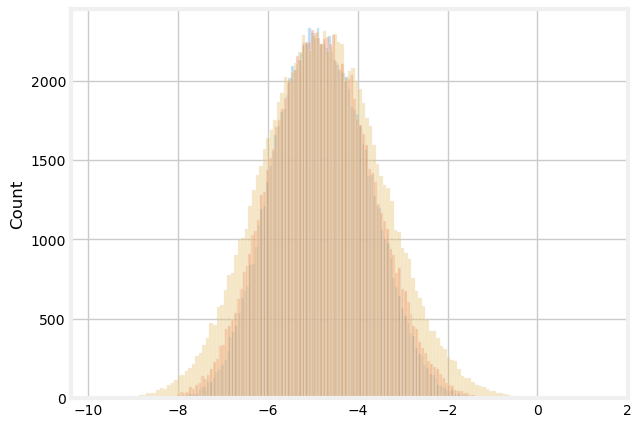

In [93]:
sns.histplot(eta_fn((beta_coeffs_base, inter), Xm, noise=True, noise_sigma=(1.e-6*eta_scale), random_state=2), alpha=0.3)
sns.histplot(eta_fn((beta_coeffs_base, inter), Xm, noise=True, random_state=5), alpha=0.3)
# sns.histplot(eta_fn((beta_coeffs_base, inter), Xm, noise=True, random_state=1), alpha=0.3)
# sns.histplot(eta_fn((beta_coeffs_base, inter), Xm, noise=True, random_state=10), alpha=0.3)
sns.histplot(eta_fn((beta_coeffs_base, inter), Xm, noise=True, noise_sigma=(0.2*eta_scale), random_state=22), alpha=0.3)

And from that we can find $\overline{p} = \langle \sigma(\eta) \rangle$:

In [94]:
sigeta = sigma_fn((beta_coeffs_base, inter), Xm, noise=True)
print("sigma(eta) =", sigeta)
print("pbar = <sigma(eta)> =", float(np.mean(sigeta)))

sigma(eta) = [0.01440829 0.01026019 0.00905832 ... 0.00654804 0.00537675 0.01180724]
pbar = <sigma(eta)> = 0.014616868792443121


Comparing in-sample standard deviation (given by population distribution) with in-user standard deviation (given by Bernoulli) (they are not the same)

In [95]:
np.std(sigeta, ddof=1)**2 / (pstar*(1-pstar))

np.float64(0.02948396560989659)

Histogram:

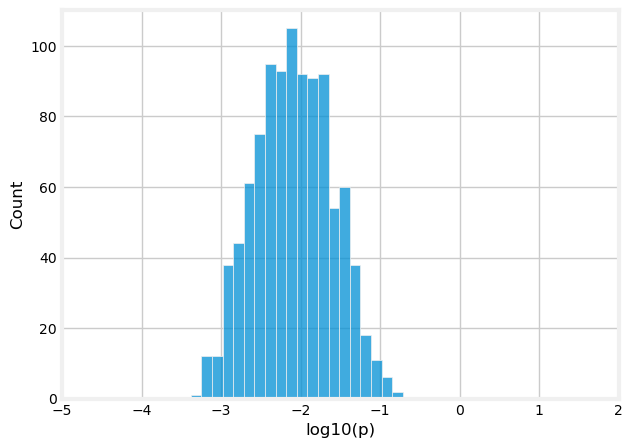

In [96]:
tmp1 = np.log10(pd.Series(sigeta).sample(frac=0.01))
sns.histplot(tmp1)

plt.xlim(-5, 2);
plt.xlabel("log10(p)");

In [97]:
del Xm, inter, sigeta

#### B: Treatment

Let us now model the treatment. We follow the same formulas as before, but this we need to update the coefficients (and even the intercept, since the population itself has changed: we are conditioning on having received the treatment).

In [98]:
beta_coeffs_treat = beta_coeffs_base.copy() # we make a shallow copy of the baseline

# age [increase = 10 years]:
# treatment increases conversion rate for younger people: 10 years younger are a relative 10% more responsive
beta_coeffs_treat['age'] += beta_j(pstar, -0.1, 10)

# income [increase = one order of magnitude]:
# treatment increases conversion rate by an additional relative 10% every order of magnitude more of income a year
beta_coeffs_treat['log10_income'] += beta_j(pstar, +0.1, 1)

# balance [increase = one order of magnitude]:
# treatment increases conversion rate by an additional relative 10% by adding $100,000 to balance
beta_coeffs_treat['log10_retirement_balance'] += beta_j(pstar, +0.1, 1)

# acct_tenure [increase = 1 year]
# treatment increases conversion rate by an additional relative 1% when adding 1 year to the account tenure
beta_coeffs_treat['acct_tenure'] += beta_j(pstar, +0.01, 1)

# last_login [increase = 1 day]
# treatment increases the conversion rate of those with most recent logins by a relative 5%
beta_coeffs_treat['last_login'] += beta_j(pstar, -0.05, 1)

# time_online_frac [increase = 1 hr]
# treatment increases the conversion rate of those more terminally online by a relative 10% for every hour more spent
# EXPLANATION
beta_coeffs_treat['time_online_frac'] = beta_j(pstar, +0.1, (1./24))

So the new coefficients are:

In [99]:
beta_coeffs_treat

age                              -0.060821
log10_income                      1.115053
log10_retirement_balance         -0.405474
acct_tenure                      -0.015205
last_login                       -0.052712
current_pct_above_7pp            -0.693147
current_pct_above_employer_cap   -0.693147
time_online_frac                  2.432843
dtype: float64

Compare to baseline:

In [100]:
beta_coeffs_base

age                              -0.050684
log10_income                      1.013685
log10_retirement_balance         -0.506842
acct_tenure                      -0.025342
last_login                       -0.002027
current_pct_above_7pp            -0.693147
current_pct_above_employer_cap   -0.693147
dtype: float64

Let us now define a function that takes the population data and applies to it the necessary transformations to turn it into the feature matrix `Xmatrix` for the treatment:

In [101]:
def X_features_beta_treat(data):
    """
    Construct a feature matrix for treatment logistic regression modeling.

    Includes base features plus `time_online_frac`, and binary indicators for contribution thresholds.

    Args:
        data (DataFrame): Input dataset containing columns:
            'age', 'income', 'retirement_balance', 'acct_tenure',
            'last_login', 'time_online_frac', 'current_pct', 'employer_cap'.

    Returns:
        DataFrame: Feature matrix suitable for logistic regression with treatment features.
    """


    Xmatrix = pd.DataFrame()

    Xmatrix['age'] = data['age']
    Xmatrix['log10_income'] = np.log10(data['income'])
    Xmatrix['log10_retirement_balance'] = np.log10(data['retirement_balance'])
    Xmatrix['acct_tenure'] = data['acct_tenure']
    Xmatrix['last_login'] = data['last_login']
    Xmatrix['time_online_frac'] = data['time_online_frac']
    
    Xmatrix['current_pct_above_7pp'] =\
        (data['current_pct'] > 0.07).astype(int)
    
    Xmatrix['current_pct_above_employer_cap'] =\
        (data['current_pct'] >= data['employer_cap']).astype(int)

    return Xmatrix

Example computation:

In [102]:
Xm = X_features_beta_treat(full_data)

display(Xm)

,age,log10_income,log10_retirement_balance,acct_tenure,last_login,time_online_frac,current_pct_above_7pp,current_pct_above_employer_cap
0,61.120452,6.878753,6.663040,2.785594,32.2,0.182,1,1
1,58.836340,5.358455,4.843357,6.392434,9.3,0.199,1,1
2,54.163989,5.491020,6.465119,0.442489,161.3,0.203,1,0
3,61.334973,6.220790,5.841446,1.829825,11.0,0.147,1,0
4,65.683682,5.754335,6.746177,0.803075,3.5,0.179,1,1
...,...,...,...,...,...,...,...,...
99995,50.540938,6.078498,6.676968,7.268112,5.4,0.207,1,1
99996,40.688313,5.680436,5.481426,6.422395,30.0,0.238,1,1
99997,42.684359,5.826367,6.333246,8.361481,0.1,0.201,1,1
99998,69.907968,6.047187,5.689068,4.252460,21.1,0.146,1,1


We can then compute $\beta_0$, demanding a lift of 2% over baseline

In [103]:
lift = 0.02
inter = beta0_fn((pstar+lift), beta_coeffs_treat, Xm)
print(inter)

-2.70245082534878


From that we can compute $\eta$:

In [104]:
# without noise
eta_fn((beta_coeffs_treat, inter), Xm, noise=False)

# with noise
eta_fn((beta_coeffs_treat, inter), Xm, noise=True)

array([ -3.98625592,  -3.40681342, -11.06200501, ...,  -3.00635329,
        -4.76331701,  -3.58802644], shape=(100000,))

And from that we can find $\overline{p} = \langle \sigma(\eta) \rangle$:

In [105]:
sigeta = sigma_fn((beta_coeffs_treat, inter), Xm, noise=True)
print("sigma(eta) =", sigeta)
print("pbar = <sigma(eta)> =", float(np.mean(sigeta)))

sigma(eta) = [1.82305827e-02 3.20832058e-02 1.56973178e-05 ... 4.71396767e-02
 8.46497669e-03 2.69087477e-02]
pbar = <sigma(eta)> = 0.03603999859241178


Histogram:

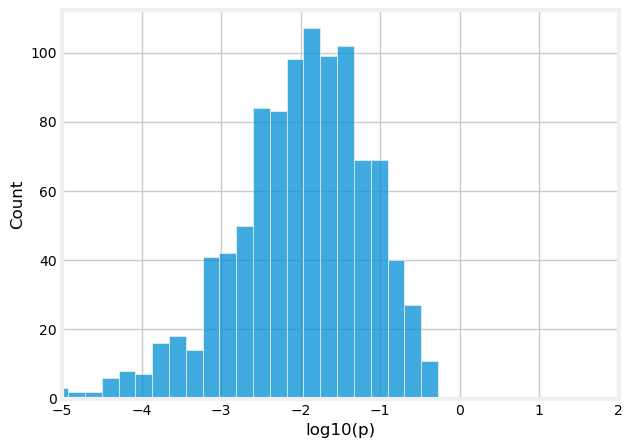

In [106]:
tmp2 = np.log10(pd.Series(sigeta).sample(frac=0.01))
sns.histplot(tmp2)

plt.xlim(-5, 2);
plt.xlabel("log10(p)");

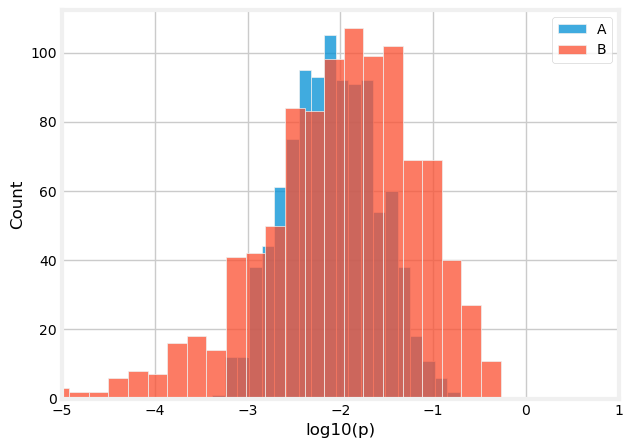

In [107]:
sns.histplot(tmp1, label="A")
sns.histplot(tmp2, label="B")

plt.xlim(-5, 1)
plt.xlabel("log10(p)");
plt.legend();

In [108]:
del Xm, lift, inter, sigeta, tmp1, tmp2

### Modeling Contribution Change

We now proceed to model the change $\Delta$ in contributions, as a percentage of the income. We will model them as draws from a log normal:

$\ln\Delta \sim \mathcal{N}(\mu_{\ln}, \sigma_{\ln})$.

This has the following properties:

$\mathrm{mean}[\ln \Delta] = \mathbb{E}[\ln\Delta] = \mu_{\ln}$,

$\mathrm{median}[\Delta] = e^{\mu_{\ln}} \Rightarrow \ln(\mathrm{median}[\Delta]) = \mu_{\ln}$,

$\mathrm{mean}[\Delta] = \mathbb{E}[\Delta] = e^{\mu_{\ln} + \frac{1}{2} \sigma_{\ln}^2} \Rightarrow \ln(\mathbb{E}[\Delta]) = \mu_{\ln} + \frac{1}{2} \sigma_{\ln}^2$,

$\mathrm{Var}(\ln \Delta) = \sigma_{\ln}^2$

(_i.e._, $\sigma_{\ln}^2$ is the variance unaccounted for by the covariates).

In all likelihood the covariates $\mathbf{X}$ should influence $\mu_{\ln}$, so that we should have instead:

$\ln\Delta_i \sim \mathcal{N}(\mu_{\ln,i}, \sigma_{\ln})$,

where we can model the mean $\mu_{\ln,i}$ for _each_ user as:

$\mu_{\ln,i} = \alpha_0 + \boldsymbol\alpha \mathbf{X}_i + \varepsilon_i$,

where $\varepsilon_i \sim \mathcal{N}(0, \sigma_{\ln})$ the noise. Thus:

$\mathrm{Var}(\ln \Delta) = \mathrm{Var}(\boldsymbol\alpha \mathbf{X}) + \sigma_{\ln}^2$.

Like in the case of modeling the conversion, let us begin by ignoring the noise and focusing instead in the deterministic model.

We can easily see that:

$\alpha_j = \frac{d \ln \Delta}{d X_j} \approx \frac{\delta (\Delta) / \Delta}{\delta X_j}$

(we temporarily use $\delta y$ as "small increment in $y$"; apologies about the notation)

In [109]:
def alpha_j(dlnd, dXj):
    """
    Compute a simple linear coefficient alpha_j.

    Args:
        dlnd (float): Change in log-odds (or dependent variable).
        dXj (float): Change in predictor variable X_j.

    Returns:
        float: Linear coefficient alpha_j.
    """

    return dlnd/dXj

For $\alpha_0$ things are a bit more complicated. Having computed $\boldsymbol\alpha$, we can find $\alpha_0$ by solving:

$\mu_{\ln} \approx \hat{\mu}_{\ln} = \langle \mu_{\ln,i} \rangle = \frac{1}{N} \sum\limits_{i=0}^{N} \mu_{\ln,i} = \alpha_0 + \frac{1}{N} \sum\limits_{i=1}^{N} \boldsymbol\alpha X_i$,

$\Rightarrow \alpha_0 = \mu_{\ln} - \frac{1}{N} \sum\limits_{i=1}^{N} \boldsymbol\alpha X_i$

We first define the function that computes $\ln\Delta(X)$:

In [110]:
# rough scale of ln of the contributions growth (assumed ~2%)
lnd_scale = np.abs(np.log(2.))

# computing mu_lni = alpha_0 + alpha_j*X_j
def muln_fn(alphaj_alpha0, Xmatrix, noise=False, noise_sigma=0.1*lnd_scale, random_state=1):
    """
    Compute the distribution mean of the log-change (ln delta) of contributions using a linear model.

    mu_lni = alpha0 + sum(alpha_j * X_j), optionally with Gaussian noise.

    Args:
        alphaj_alpha0 (tuple): Tuple containing array-like alphas and scalar alpha0.
        Xmatrix (DataFrame): Feature matrix with columns corresponding to alphas.
        noise (bool, optional): Whether to add Gaussian noise. Defaults to False.
        noise_sigma (float, optional): Standard deviation of noise. Defaults to 0.1 * lnd_scale = 0.0693.
        random_state (int, optional): Seed for random number generation. Defaults to 1.

    Returns:
        float or ndarray: Log-change(s) of contributions.
    """
    
    alphas, alpha0 = alphaj_alpha0 # splitting the alphas

    # alpha_j*X_j
    alphaX = Xmatrix.mul(alphas, axis=1).to_numpy()
    
    # sum(alpha_j*X_j)
    covars = np.sum(alphaX, axis=1)

    # ln delta = alpha*X + alpha0
    lnd = covars + alpha0

    # trying different lengths
    try:
        n = len(lnd)
    except TypeError:
        n = 1

    # add noise (default is 10% of a ~1% scale of increments)
    if noise:
        rng = np.random.default_rng(seed=random_state)
        lnd_arr = rng.normal(loc=0., scale=noise_sigma, size=n)
        lnd += lnd_arr

    if len(lnd) == 1:
        return float(lnd[0])
    else:
        return lnd

Now we define the $\alpha_0$:

In [111]:
def alpha0_fn(target_muln, alphas, Xmatrix):
    """
    Compute the intercept (alpha0) for a contributions growth model.

    Solves for alpha0 such that the population mean of ln delta matches the target multiplier.

    Args:
        target_muln (float): Desired average log-change (ln delta) across the population.
        alphas (array-like): Coefficients for predictor variables.
        Xmatrix (DataFrame): Feature matrix corresponding to alphas.

    Returns:
        float: Intercept alpha0 for the contributions growth model.
    """

    # alpha_j* X_ij
    alphaX_i = muln_fn((alphas, 0), Xmatrix)

    # result
    a0 = target_muln - np.mean(alphaX_i)

    return a0

#### A: Baseline/Control

We now define the coefficients $\boldsymbol\alpha$ for the baseline model; remember: conditioned upon they having converted! (so no need to consider their age or how recently they have checked in their account, etc.).

Recall

$\alpha_j = \frac{d \ln \Delta}{d X_j} \approx \frac{\delta (\Delta) / \Delta}{\delta X_j}$.

In [112]:
alpha_coeffs_base = {}

# income [increase = one order of magnitude]:
# one order of magnitude a year in income more increases the relative contribution growth by 50%
# EXPLANATION: earning $1M more will want to make us growth the contribution by a factor of e
alpha_coeffs_base['log10_income'] = alpha_j(0.5, 1)

# balance [increase = one order of magnitude]
# one more order of magnitude in the balance decreases the relative contribution growth by 20%
alpha_coeffs_base['log10_retirement_balance'] = alpha_j(-0.2, 1)

# current_pct threshold
# if current_pct > 7% (the mode of employee contributions), the relative contribution growth decreases by 50%
# EXPLANATION: it starts to feel like a lot
alpha_coeffs_base['current_pct_above_7pp'] = -0.5

# employer matching
# if current_pct > employer_cap, the relative contribution growth decreases by 50%
alpha_coeffs_base['current_pct_above_employer_cap'] = -0.25

alpha_coeffs_base = pd.Series(alpha_coeffs_base)

In [113]:
alpha_coeffs_base

log10_income                      0.50
log10_retirement_balance         -0.20
current_pct_above_7pp            -0.50
current_pct_above_employer_cap   -0.25
dtype: float64

Let us now define a function that takes the population data and applies to it the necessary transformations to turn it into the feature matrix `Xmatrix`:

In [114]:
def X_features_alpha_base(data):
    """
    Construct a feature matrix for base contributions growth modeling.

    Features include log-transformed income and retirement balance, and binary indicators for contribution thresholds.

    Args:
        data (DataFrame): Input dataset containing columns:
            'income', 'retirement_balance', 'current_pct', 'employer_cap'.

    Returns:
        DataFrame: Feature matrix suitable for contributions growth modeling.
    """

    Xmatrix = pd.DataFrame()
    
    Xmatrix['log10_income'] = np.log10(data['income'])
    Xmatrix['log10_retirement_balance'] = np.log10(data['retirement_balance'])
    
    Xmatrix['current_pct_above_7pp'] =\
        (data['current_pct'] > 0.07).astype(int)
    
    Xmatrix['current_pct_above_employer_cap'] =\
        (data['current_pct'] >= data['employer_cap']).astype(int)

    return Xmatrix

Example computation:

In [115]:
Xm = X_features_alpha_base(full_data)

display(Xm)

,log10_income,log10_retirement_balance,current_pct_above_7pp,current_pct_above_employer_cap
0,6.878753,6.663040,1,1
1,5.358455,4.843357,1,1
2,5.491020,6.465119,1,0
3,6.220790,5.841446,1,0
4,5.754335,6.746177,1,1
...,...,...,...,...
99995,6.078498,6.676968,1,1
99996,5.680436,5.481426,1,1
99997,5.826367,6.333246,1,1
99998,6.047187,5.689068,1,1


We can then compute $\alpha_0$, assuming a mean of $\ln\Delta$ of 1%:

In [116]:
inter = alpha0_fn(np.log(1), alpha_coeffs_base, Xm) # expected value of ln(1%)
print(inter)

-0.9471570746723957


From that we can compute $\ln\Delta = \boldsymbol\alpha \mathbf{X} + \alpha_0$:

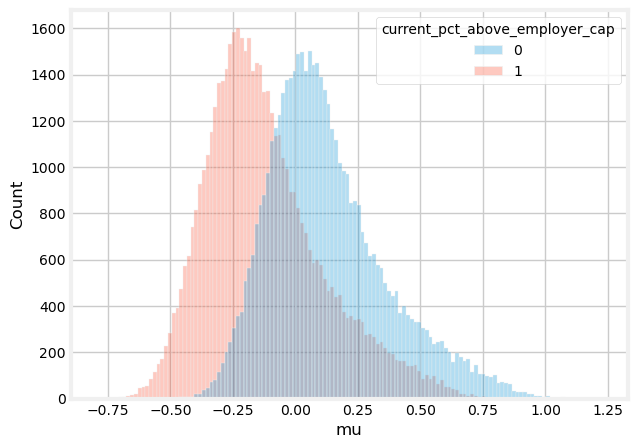

In [117]:
tmp = pd.Series(muln_fn((alpha_coeffs_base, inter), Xm, noise=False), name='mu')
tmp = pd.concat([Xm, tmp], axis=1)

# sns.histplot(data=tmp, x='mu', alpha=0.3)
sns.histplot(data=tmp, x='mu', hue='current_pct_above_employer_cap', alpha=0.3)
# sns.histplot(data=tmp, x='mu', hue='current_pct_above_7pp', alpha=0.3)

del tmp

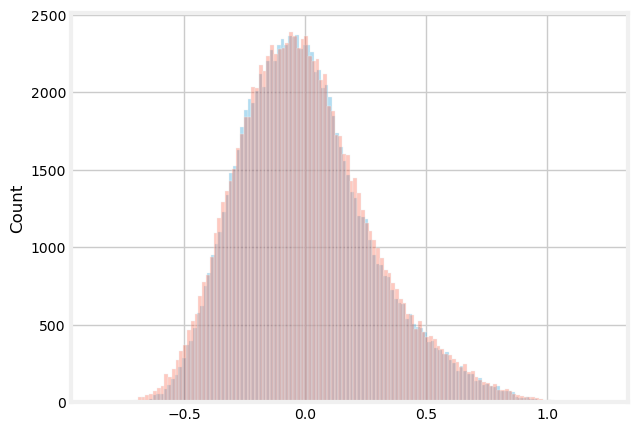

In [118]:
tmp = pd.Series(muln_fn((alpha_coeffs_base, inter), Xm, noise=False), name='mu')
tmp = pd.concat([Xm, tmp])

sns.histplot(muln_fn((alpha_coeffs_base, inter), Xm, noise=False), alpha=0.3)
sns.histplot(muln_fn((alpha_coeffs_base, inter), Xm, noise=True, noise_sigma=0.1*lnd_scale), alpha=0.3)

del tmp

In [119]:
# without noise
lnds = muln_fn((alpha_coeffs_base, inter), Xm, noise=False)

print("w/o noise:")
print(lnds)
print(np.mean(lnds))
print(np.std(lnds, ddof=1))

# with noise
print("\nw noise:")
lnds = muln_fn((alpha_coeffs_base, inter), Xm, noise=True)

print(lnds)
print(np.mean(lnds))
print(np.std(lnds, ddof=1))

w/o noise:
[ 0.40961144  0.01339888  0.00532912 ... -0.05062254  0.18862271
  0.16884046]
-2.2639667918156194e-16
0.26894154917775465

w noise:
[ 0.43356551  0.07034911  0.02823327 ... -0.14863684  0.18261745
  0.23596551]
-0.0003181942068678946
0.27734438830032465


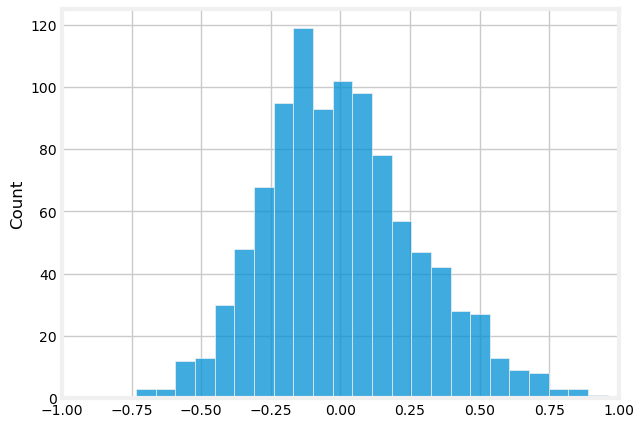

In [120]:
sns.histplot(pd.Series(lnds).sample(frac=0.01))

plt.xlim(-1, 1);

Looking at the $\Delta$ s instead:

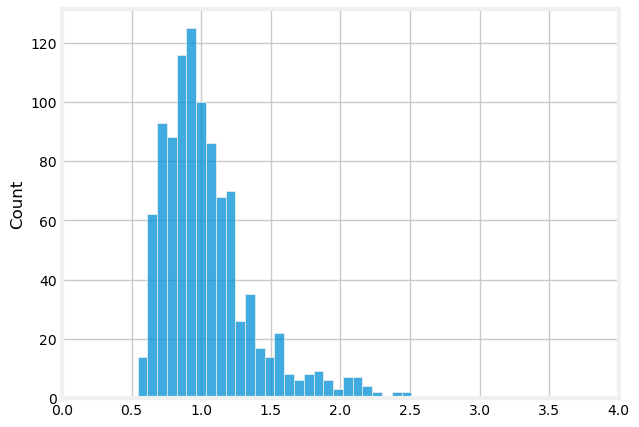

In [121]:
ds = np.exp(lnds)

sns.histplot(pd.Series(ds).sample(frac=0.01))

plt.xlim(0, 4);

But typically we round up the contributions to the neares 0.25%:

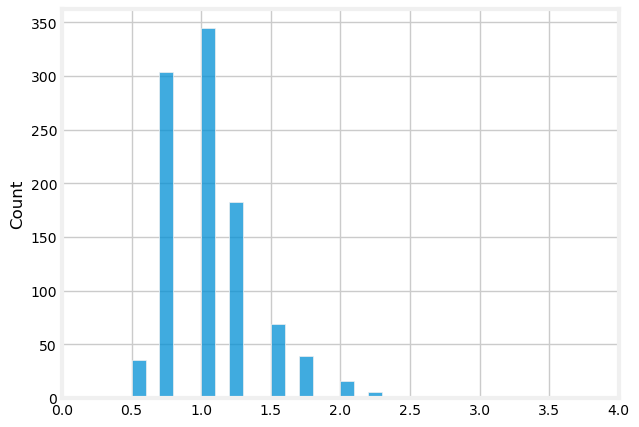

In [122]:
ds = np.round(ds*4)/4

sns.histplot(pd.Series(ds).sample(frac=0.01))

plt.xlim(0, 4);

In [123]:
tmp1 = lnds.copy()

In [124]:
del lnds, ds

#### B: Treatment

Let us now model the changes to the coefficients $\boldsymbol\alpha$ for the treatment:

In [125]:
alpha_coeffs_treat = alpha_coeffs_base.copy()

# age [increase = 10 years]:
# treatment boosts relative contribution growth by 20% for every 10 years *younger*
alpha_coeffs_treat['age'] = alpha_j(-0.2, 10)

# income [increase = one order of magnitude]:
# treatment boosts relative contribution growth by 20% for every order of magnitude more in income
alpha_coeffs_treat['log10_income'] += alpha_j(0.2, 1)

# balance [increase = one order of magnitude]
# treatment boosts relative contribution growth by 10% for every order of magnitude more in balance
alpha_coeffs_treat['log10_retirement_balance'] += alpha_j(0.1, 1)

Compare the treatment coefficients:

In [126]:
alpha_coeffs_treat

log10_income                      0.70
log10_retirement_balance         -0.10
current_pct_above_7pp            -0.50
current_pct_above_employer_cap   -0.25
age                              -0.02
dtype: float64

With the baseline/control:

In [127]:
alpha_coeffs_base

log10_income                      0.50
log10_retirement_balance         -0.20
current_pct_above_7pp            -0.50
current_pct_above_employer_cap   -0.25
dtype: float64

Let us now define a function that takes the population data and applies to it the necessary transformations to turn it into the feature matrix `Xmatrix`:

In [128]:
def X_features_alpha_treat(data):
    """
    Construct a feature matrix for treatment contributions growth modeling.

    Includes base features (log-transformed income and retirement balance, and binary contribution indicators) plus age.

    Args:
        data (DataFrame): Input dataset containing columns:
            'income', 'retirement_balance', 'current_pct', 'employer_cap', 'age'.

    Returns:
        DataFrame: Feature matrix suitable for contributions growth modeling with treatment features.
    """

    Xmatrix = pd.DataFrame()
    
    Xmatrix['log10_income'] = np.log10(data['income'])
    Xmatrix['log10_retirement_balance'] = np.log10(data['retirement_balance'])
    
    Xmatrix['current_pct_above_7pp'] =\
        (data['current_pct'] > 0.07).astype(int)
    
    Xmatrix['current_pct_above_employer_cap'] =\
        (data['current_pct'] >= data['employer_cap']).astype(int)

    Xmatrix['age'] = data['age']

    return Xmatrix

Example computation:

In [129]:
Xm = X_features_alpha_treat(full_data)

display(Xm)

,log10_income,log10_retirement_balance,current_pct_above_7pp,current_pct_above_employer_cap,age
0,6.878753,6.663040,1,1,61.120452
1,5.358455,4.843357,1,1,58.836340
2,5.491020,6.465119,1,0,54.163989
3,6.220790,5.841446,1,0,61.334973
4,5.754335,6.746177,1,1,65.683682
...,...,...,...,...,...
99995,6.078498,6.676968,1,1,50.540938
99996,5.680436,5.481426,1,1,40.688313
99997,5.826367,6.333246,1,1,42.684359
99998,6.047187,5.689068,1,1,69.907968


We can then compute $\alpha_0$, assuming a boost from 1% to 3% contribution increments:

In [130]:
inter = alpha0_fn(np.log(3), alpha_coeffs_treat, Xm)
print(inter)

-0.3688324315675844


From that we can compute $\ln\Delta = \boldsymbol\alpha \mathbf{X} + \alpha_0$:

In [131]:
# without noise
lnds = muln_fn((alpha_coeffs_treat, inter), Xm, noise=False)

print("w/o noise")
print(lnds)
print(np.mean(lnds))
print(np.std(lnds, ddof=1))

# with noise
lnds = muln_fn((alpha_coeffs_treat, inter), Xm, noise=True)

print("\nw/ noise")
print(lnds)
print(np.mean(lnds))
print(np.std(lnds, ddof=1))

w/o noise
[1.80758158 0.97102334 1.24508989 ... 1.47261295 1.14713213 1.45036216]
1.0986122886681098
0.478465580393235

w/ noise
[1.83153565 1.02797357 1.26799404 ... 1.37459865 1.14112687 1.5174872 ]
1.0982940944612423
0.48334718778605307


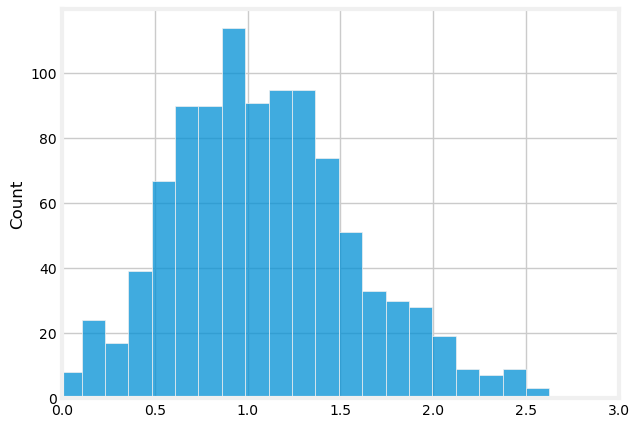

In [132]:
sns.histplot(pd.Series(lnds).sample(frac=0.01))

plt.xlim(0, 3);

Looking at the $\Delta$ s instead:

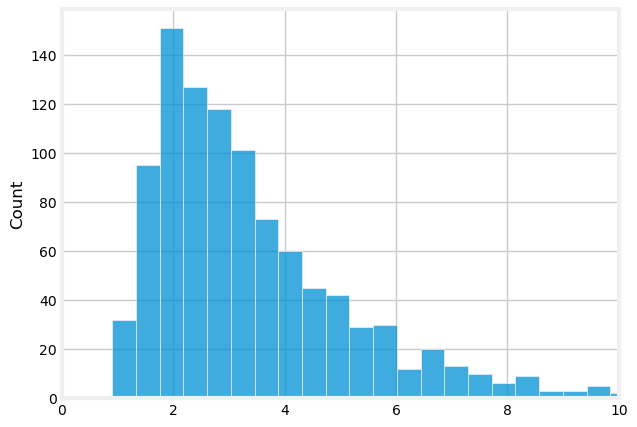

In [133]:
ds = np.exp(lnds)

sns.histplot(pd.Series(ds).sample(frac=0.01))

plt.xlim(0, 10);

Rounding up to the neares 0.25%:

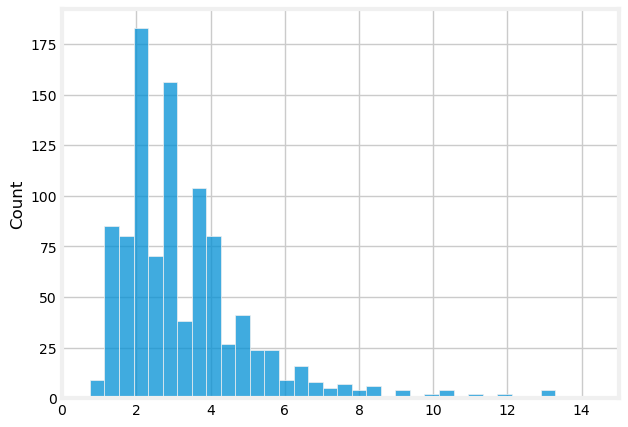

In [134]:
ds = np.round(ds*4)/4

sns.histplot(pd.Series(ds).sample(frac=0.01))

plt.xlim(0, 15);

In [135]:
tmp2 = lnds.copy()

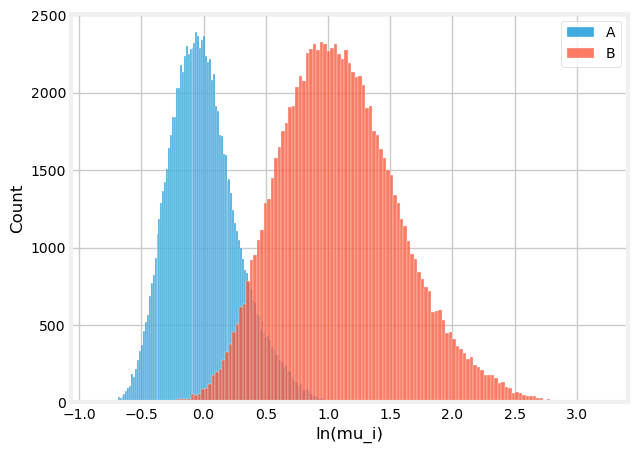

In [136]:
sns.histplot(tmp1, label="A")
sns.histplot(tmp2, label="B")

plt.xlabel("ln(mu_i)");
plt.legend();

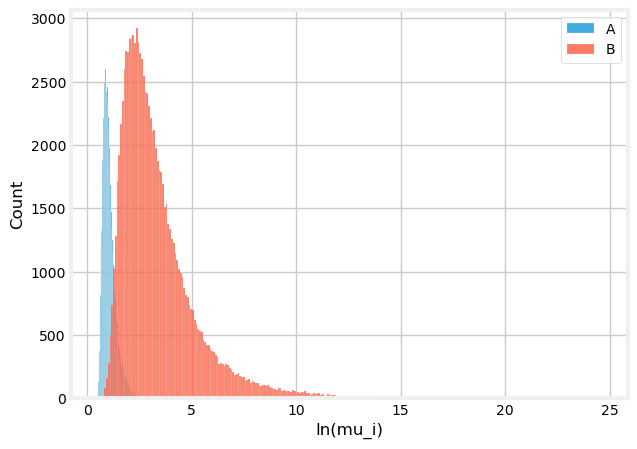

In [137]:
sns.histplot(np.exp(tmp1), label="A")
sns.histplot(np.exp(tmp2), label="B")

plt.xlabel("ln(mu_i)");
plt.legend();

In [138]:
del lnds, ds

In [139]:
del tmp1, tmp2

### Experiment

We now devise the experiment. The recipe:

1. We compute the size $n = n_A = n_B$ of each of the arms based on our previous knowledge of $p_0$ ($= p_A$), what we want for the Type I and II errors ($\alpha$ and $\beta$), and the MDE $\Delta = p_B - p_A$ we want. Compute power curve ($n$ vs. $p_A$, taken to vary accross $2\sigma$ (_i.e._ $\pm p_A(1-p_A)$)).

2. We highlight the secondary metric (the increase $\Delta$ in contributions), and any guardrail metrics to monitor.

3. We simulate the experiment: take the population and randomly assign either A or B to $2 n$ members of it, by hashing the user id. We can do the experiment once and for all, or simulate a 10%-25%-50%-100% roll-out. At any rate, we simply create two new tables, one for each group. The table for A has extra information about when and how it was nudged. Regardless, the point is that each element has a probability $p_i$, taken from our conversion model, of converting, and thus there is a Bernoulli process associated to each element. Note that we add a little bit of noise to create $p_i$ (it's not deterministic). There is also $\Delta_i$ for each, also with some noise in $\mu$ (but not in $\sigma$).

4. We perform the analysis, compute the SE and CI

#### Experiment Design

We are interested in designing an experiment that tests whether we can observe any uplift in the conversion rate ("user decides to increase retirement contributions").

Here are some important terms:

- **RCT (Randomized Controlled Trial):** this A/B experiment.
- **ATE (Average Treatment Effect):** effect of actual treatment.
- **ITT (Intention-To-Test):** effect of assignment (policy lever). ITT = ATE if there is perfect compliance (assignment = receipt)
- **CACE (Complier Average Causal Effect):** effect among those who receive treatment if there is noncompliance
- **CATE (Aonditional ATE)** the ATE conditional on covariates.
- **HTE (Heterogeneous Treatment Effects):** how the treatment effect varies across individuals or subgroups. Basically, the CATE when conditioning on groups.

Here are some important quantities:

- **Primary metric ITT:** $\mathbb{E}[Y | Z = 1] - \mathbb{E}[Y | Z = 0] = p_B - p_A$, where $Y$ is "yes, user converted" (got a 1 in its Bernoulli trial to increase contribution), and $Z = 0/1$ is "received treatment/did not receive treatment".
- **Primary metric ATE:** estimates the ITT, and is the difference in sample conversion rates: $\hat{d} \equiv \hat{p}_B - \hat{p}_A$.
- **Secondary metric:** $\mathbb{E}[\Delta | Z = 1] - \mathbb{E}[\Delta | Z = 0] = \mu_{\ln,A} - \mu_{\ln,B}$. Possible additional ITT if we can power enough. We estimate it (secondary ATE) as $\hat{m} \equiv \hat{\mu}_{\ln,A} - \hat{\mu}_{\ln,B} = \langle \ln \Delta_B \rangle - \langle \ln \Delta_A \rangle$.
- **Type I and II errors:** $\alpha = 0.05$, $\beta = 0.2$.
- **MDE (Minimum Detectable Effect):** ($\delta$) the smallest primary ATE which we define as actionable. If it is positive, it is also called the _(up)lift_. We will take it to be $\delta \approx 2 \%$ (a lift of 2%), but we will vary it.

##### Arm Size

Based on $\alpha$, $\beta$, and required $\delta$, we can find $n_A = n_B = n$:

$n = \frac{\left( z_{1-\alpha/2} \sqrt{2\overline{p}(1 - \overline{p})} + z_{1 - \beta} \sqrt{p_B (1 - p_B) + p_A (1 - p_A)} \right)^2}{\delta^2}$,

where

$\overline{p} = (p_A + p_B)/2 = p_A + \delta/2$ is the pooled conversion probability.

If we are interested in powering the difference in means of the continuous variables as well, $m = \mu_B - \mu_A$, we need

$n \approx \frac{2 \, (z_{1 - \alpha/2} + z_{1 - \beta})^2 \, \sigma_{\Delta}^2}{m^2}$,

where $\sigma_{\Delta}$ is the variance of the $\Delta$'s, assumed to be the same in both arms. Conservatively, we can take $\sigma_{\Delta} = \max(\sigma_{\Delta,A}, \sigma_{\Delta,B})$.
**N.B.:** Here $\mu_X$ and $\sigma_\Delta$ are the mean and std, respectively, of the $\Delta$ _of the true underlying PDF_ (for large $N$, the same as those _of the entire population_, including conversions AND non-conversions). In other words they are _different_ from the mean and std of the **log**-normal distribution, which was conditioned upon conversion: $\mu_X \neq \mu_{\ln,X}$, and $\sigma_\Delta \neq \sigma_{\ln}$.

In [140]:
from scipy.stats import norm, t as student_t

In [141]:
def n_per_arm_diff_props(pA, pB, alpha=0.05, power=0.80):
    """
    Compute per-arm sample size for detecting a difference in proportions.

    Uses a two-sided z-test with specified significance level and power.

    Args:
        pA (float): Conversion rate in control group.
        pB (float): Conversion rate in treatment group.
        alpha (float, optional): Significance level. Defaults to 0.05.
        power (float, optional): Desired power. Defaults to 0.80.

    Returns:
        float: Required sample size per arm.
    """
    
    beta = 1 - power # Type II error rate

    z_a = norm.ppf(1 - alpha/2) # z_{1 - alpha/2}

    z_b = norm.ppf(1 - beta) # z_{1-beta}
    
    pbar = 0.5*(pA + pB) # pooled conversion rate

    # numerator
    num = (z_a*np.sqrt(2*pbar*(1-pbar)) + z_b*np.sqrt(pA*(1-pA)+pB*(1-pB)))**2

    # denominator
    den = (pB - pA)**2

    # number of samples per arm
    n = num/den
    
    return n



def n_per_arm_diff_means(delta, sigma2, alpha=0.05, power=0.8):
    """
    Compute per-arm sample size for detecting a difference in means.

    Assumes equal variance per group and equal allocation between groups.

    Args:
        delta (float): Difference in means to detect (muB - muA).
        sigma2 (float): Assumed variance per group.
        alpha (float, optional): Significance level. Defaults to 0.05.
        power (float, optional): Desired power. Defaults to 0.80.

    Returns:
        float: Required sample size per arm.
    """

    beta = 1 - power # Type II error rate

    z_a = norm.ppf(1 - alpha/2) # z_{1 - alpha/2}

    z_b = norm.ppf(1 - beta) # z_{1-beta}
    
    num = 2 * (z_a + z_b)**2 * sigma2
    
    den = delta**2
    
    return num / den

Given a baseline $p_0$ with variance $p_0 (1-p_0)$, we can make a power curve by varying the estimated $\hat{p}_0$ of a population of size $N$ over its standard error $\hat{\mathrm{SE}}$ for a given $\delta$ and power specification.

**NOTE:** the variance above is the variance in a single Bernoulli trial, NOT the standard error of the estimated proportion. The standard error is

$\hat{\mathrm{SE}} = \sqrt{\hat{p}_0 (1-\hat{p}_0) / N}$

by the CLT.

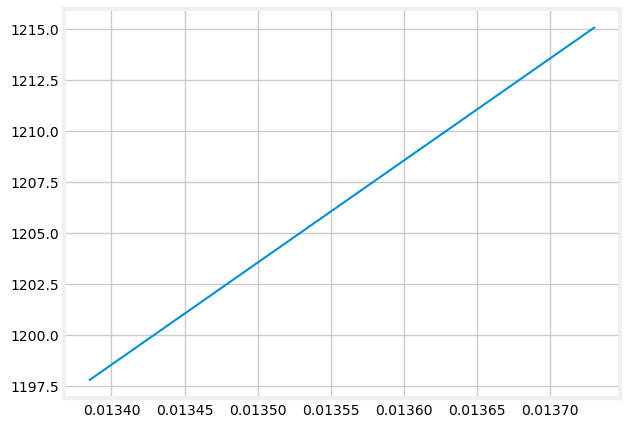

In [142]:
std = np.sqrt(pstar*(1-pstar))/1_000 # assuming 1,000 points of historical data
lift = 0.02

parr = np.linspace(np.min(pstar-1*std,0), pstar+2*std, 101)
narr = n_per_arm_diff_props(parr, parr + lift, alpha=0.05, power=0.90)

plt.plot(parr, narr)

del std, lift, parr, narr

##### Confidence Intervals

We can build the confidence intervals:

$\hat{d} \pm z_{1 - \alpha/2} \hat{\mathrm{SE}}$,

where

$\hat{SE} = \sqrt{\frac{\hat{s}_A^2}{n_A} + \frac{\hat{s}_B^2}{n_B}}$

and $\hat{s}_X^2$ the sample variance of the proportions:

$\hat{s}_X^2 = \frac{1}{N-1}\sum\limits_{i=1}^N (\text{(Y or N)} - \hat{p}_X)^2 \approx \hat{p}_X (1 - \hat{p}_X)$.

Similarly for the continuous secondary metric.

In [143]:
def props_diff_CI(xA, xB, alpha=0.05):
    """
    Compute the difference in proportions and its confidence interval.

    Args:
        xA (array-like): Binary outcomes for group A.
        xB (array-like): Binary outcomes for group B.
        alpha (float, optional): Significance level. Defaults to 0.05.

    Returns:
        tuple: (Difference in proportions, lower and upper bounds of CI)
    """

    nA, nB = len(xA), len(xB)
    
    hat_pA, hat_pB = np.sum(xA)/nA, np.sum(xB)/nB
    
    hat_d = hat_pB - hat_pA
    
    hat_se = np.sqrt(hat_pA*(1-hat_pA)/nA + hat_pB*(1-hat_pB)/nB)
    
    z_crit = norm.ppf(1 - alpha/2.0)
    
    return hat_d, (hat_d - z_crit*hat_se, hat_d + z_crit*hat_se)



def welch_df(s1_sq, s2_sq, n1, n2):
    """
    Compute the Welch-Satterthwaite degrees of freedom for unequal variances.

    Args:
        s1_sq (float): Variance of group 1.
        s2_sq (float): Variance of group 2.
        n1 (int): Sample size of group 1.
        n2 (int): Sample size of group 2.

    Returns:
        float: Approximate degrees of freedom for Welch's t-test.
    """
    
    num = (s1_sq/n1 + s2_sq/n2)**2
    
    den = (s1_sq**2)/((n1**2)*(n1-1)) + (s2_sq**2)/((n2**2)*(n2-1))
    
    return num/den



def means_diff_CI(YA, YB, alpha=0.05, use_tdist=False):
    """
    Compute the difference in means and its confidence interval.

    Can use either normal approximation or Welch's t-distribution for CI.

    Args:
        YA (array-like): Observations for group A.
        YB (array-like): Observations for group B.
        alpha (float, optional): Significance level. Defaults to 0.05.
        use_tdist (bool, optional): Use Welch's t-distribution for CI. Defaults to False.

    Returns:
        tuple: (Difference in means, lower and upper bounds of CI, degrees of freedom if t-dist used)
    """

    
    nA, nB = len(YA), len(YB)
    
    hat_mA, hat_mB = YA.mean(), YB.mean()
    
    hat_vA, hat_vB = YA.var(ddof=1), YB.var(ddof=1)
    
    hat_se = np.sqrt(hat_vA/nA + hat_vB/nB)

    if use_tdist:
        df = welch_df(hat_vA, hat_vB, nA, nB)
        crit = student_t.ppf(1 - alpha/2.0, df)

    else:
        df = None
        crit = norm.ppf(1 - alpha/2.)
    
    hat_nu = hat_mB - hat_mA
    
    return hat_nu, (hat_nu - crit*hat_se, hat_nu + crit*hat_se), df

##### Randomization

We now define the randomization function:

In [144]:
def ab_randomize(n_arm, all_ids, random_state=1):
    """
    Randomly assign IDs to two experimental arms.

    Selects 2*n_arm IDs from all_ids and splits them into two groups of size n_arm.

    Args:
        n_arm (int): Number of samples per experimental arm.
        all_ids (array-like): Pool of available IDs.
        random_state (int, optional): Seed for reproducibility. Defaults to 1.

    Returns:
        tuple: Two arrays containing IDs assigned to arm A and arm B.
    """

    rng = np.random.default_rng(seed=random_state)
    test_ids = rng.choice(all_ids, size=2*n_arm, replace=False)

    rng = np.random.default_rng(seed=random_state)
    ids_A = rng.choice(test_ids, size=n_arm, replace=False)
    ids_B = np.array(list(set(test_ids) - set(ids_A)))

    return ids_A, ids_B

#### Experiment Simulation

We now proceed to simulate the experiment.

In [145]:
from scipy.stats import bernoulli, norm

##### User Response

Let us begin by defining a function that computes the user response (_i.e._ performs the bare bones of the experiment) for a given dataset.

In [146]:
lndelta_std = 0.5*np.log(1.5)

print("noise in conversion rate logit function:\t\t", 0.1*eta_scale)
print("noise in ln of contributions increase linear function:\t", 0.1*lnd_scale)
print("distribution std for each ln of contributions:\t\t", lndelta_std)
print(f"\t... which corresponds to an increase of {int(100*np.exp(2*lndelta_std)-100)}% for +2sigma fluctuations.")

noise in conversion rate logit function:		 0.4291473640018286
noise in ln of contributions increase linear function:	 0.06931471805599453
distribution std for each ln of contributions:		 0.2027325540540822
	... which corresponds to an increase of 50% for +2sigma fluctuations.


In [147]:
def experiment_fn(binary_true, cont_true, data,
                  b0_a0=(None, None),
                  intercepts=False,
                  historical=1,
                  noise=False,
                  noise_sigma=(0.1*eta_scale, 0.1*lnd_scale),
                  sigma_ln=lndelta_std,
                  random_state=1):
    """
    Simulate an A/B-style experiment with binary conversion and continuous contribution outcomes.

    The binary outcome models conversion probability (yes/no) using a logistic model. The continuous outcome models contribution growth for converted units using a log-normal model.

    Parameters
    ----------
    binary_true : float
        Target population conversion rate.
    cont_true : float
        Target mean contribution growth among converters.
    data : pandas.DataFrame
        Input dataset containing feature columns for the simulation.
    b0_a0 : tuple of (float or None, float or None), optional
        Intercepts for the binary (b0) and continuous (a0) models. If None, they are estimated automatically. Default is (None, None).
    intercepts : bool, optional
        If True, also return the estimated intercepts. Default is False.
    historical : int, optional
        Number of times the dataset is replicates to approximate historical quantities. Default is 1.
    noise : bool, optional
        If True, add noise to simulated probabilities and contributions. Default is False.
    noise_sigma : tuple of float, optional
        Standard deviations for noise in the binary and continuous components, respectively. Default is (0.1*eta_scale, 0.1*lnd_scale) = (0.429, 0.0693).
    sigma_ln : float, optional
        Standard deviation of the log-normal contribution growth distribution. Default is `lndelta_std` = 0.203.
    random_state : int, optional
        Random seed for reproducibility. Default is 1.

    Returns
    -------
    pandas.DataFrame
        Simulated dataset with columns:
        - ``conv_rate``: predicted conversion probability for each unit,
        - ``converted``: simulated binary conversion outcome (0/1),
        - ``delta_pct``: additional contribution percentage for converters,
        - ``new_pct``: updated contribution percentage.
    dict, optional
        If ``intercepts=True``, also return a dictionary with keys ``binary_intercept`` and ``cont_intercept``.
    """
    
    # shallow copy of data
    data = data.copy()

    # if historical > 1, beef up data to compute historical quantities
    if historical > 1:
        data = pd.concat([data]*historical, axis=0)

    # splitting intercepts:
    b0, a0 = b0_a0

    # splitting noise:
    noise_conv, noise_lndelta = noise_sigma

    # begin with the binary part
    X_props = X_features_beta_base(data) # feature matrix
    if b0 == None:
        b0 = beta0_fn(binary_true, beta_coeffs_base, X_props) # intercept
    prob_i = sigma_fn((beta_coeffs_base, b0), X_props,
                      noise=noise,
                      noise_sigma=noise_conv,
                      random_state=random_state) # Bernoulli prob
    conv = bernoulli.rvs(p=prob_i, random_state=random_state) # convert Y/N?

    # find the indices where there was a conversion
    idx_conv = np.where(conv == 1)[0]

    # addt'l contributions
    X_means = X_features_alpha_base(data) # feature matrix
    # for contributions, we are interested only on those converted
    X_means = X_means.iloc[idx_conv]
    
    if a0 == None:
        a0 = alpha0_fn(cont_true, alpha_coeffs_base, X_means) # intercept
    muln_i = muln_fn((alpha_coeffs_base, a0), X_means,
                     noise=noise,
                     noise_sigma=noise_lndelta,
                     random_state=random_state) # meanw of ln(delta_i)
    if np.isclose(sigma_ln, 0):
        DiA = muln_i # ln(contribution growth)
    else:
        DiA = norm.rvs(loc=muln_i, scale=sigma_ln, random_state=random_state) # ln(contribution growth)
    DiA = np.exp(DiA) # contribution growth
    DiA = np.round(DiA*4)/4 # rounding to nearest 0.25%

    # defining the result dataframe
    df = data.copy()

    # conversion rate
    df['conv_rate'] = prob_i

    # converted?
    df['converted'] = conv
    
    # additional contributions
    df['delta_pct'] = 0. # default is 0
    addtl_idx = df.columns.get_loc('delta_pct')
    df.iloc[idx_conv,addtl_idx] = DiA # locating those that converted

    # new contributions
    df['new_pct'] = df['current_pct'] + df['delta_pct']

    if intercepts:
        return df, {'binary_intercept':b0, 'cont_intercept':a0}
    else:
        return df

In [148]:
# test = experiment_fn(pstar, np.log(2.), full_data, b0_a0=(None, None), random_state=1, intercepts=False)

# del test

##### Metrics

We now define a dictionary of important metrics:

_conversion rates_

`exper_binary_metric = {'baseline_true':[ true baseline conversion rate ],
                 'treatment_true':[ true treatment conversion rate ],
                 'MDE':[ minimum detectable effect in conversion rate]}`

_contributions growth_

`exper_continuous_metric = {'baseline_true':[ true baseline mean of logs ],
                     'treatment_true':[ true treatment mean of logs ],
                     'MDE':[ minimum detectable effect in mean of logs ]}`

For example, this:

In [149]:
# conversion rates
exper_binary_metric = {'baseline_true':(1.35/100), # 1.35% (not necessarily reference pstar!)
                       'treatment_true':(1.35 + 2.5)/100, # 3.85%
                       'MDE':2/100} # 2%

# contributions growth
exper_continuous_metric = {'baseline_true':np.log(1.5), # 1.5%
                           'treatment_true':np.log(3), # 3%
                           'MDE':1} # +1% over baseline --> 1.5% --> 2.5% [NOT LOGS]

##### Costs and Fees

We define some commonly used parameters:

In [150]:
# typical flat cost (overhead) per day
# team of 3 people $100k/year, working 0.25 FTE on this project (i.e. 1/4 the work day)
typical_flat_cost_per_day = (0.25*3*100_000/12/30)

# typical fees for AUM
# weighted average of 0.07% for indices, and 0.11% for active funds. Assume $8.3T in indices, and $1.8T in active funds
# typical_management_fees=((0.07*8.3)+(0.11*1.8))/(8.3+1.8)/100
typical_management_fees=0.07/100

##### Arm Size of Continuous Secondary Metric is Important

We now define another useful function: computing the size of each arm if we are interested in _also_ detecting the MDE in the (continuous) mean of the log of the additional contributions:

In [151]:
def n_arm_cont_historical(primary_metric, secondary_metric, data, alpha=0.05, power=0.8, cushion=0.1, historical=10, random_state=1):
    """
    Estimate required per-arm sample size for a continuous outcome using historical data.

    This function simulates data to account for both conversion rates and contribution outcomes, conditions on conversion, and computes the population-level variance of incremental contributions. A cushion factor is applied to the final estimate for robustness.

    Parameters
    ----------
    primary_metric : dict
        Dictionary containing the baseline conversion rate under key
        ``'baseline_true'``.
    secondary_metric : dict
        Dictionary containing:
        - ``'baseline_true'``: baseline mean contribution (conditional on conversion),
        - ``'MDE'``: minimum detectable effect (conditional on conversion).
    data : pandas.DataFrame
        Input dataset containing feature columns required for simulation.
    alpha : float, optional
        Significance level of the test. Default is 0.05.
    power : float, optional
        Desired statistical power. Default is 0.8.
    cushion : float, optional
        Extra proportion added to the computed sample size for robustness. Default is 0.1 (i.e., +10%).
    historical : int, optional
        Number of times to replicate the dataset to approximate historical quantities. Default is 10.
    random_state : int, optional
        Seed for random number generation. Default is 1.

    Returns
    -------
    int
        Estimated number of samples required per arm to detect the specified effect size with the given significance level and power.
    """


    # extracting the true proportions
    true_pA = primary_metric['baseline_true']

    # extracting the true means (of log-normal, i.e. conditioned on conversion)
    true_mulnA = secondary_metric['baseline_true']

    # extracting the MDE (conditioned on conversion)
    mde_ITT_cond = secondary_metric['MDE'] # MDE on the means of Delta, conditioned on conversion

    # but to power the size of the arms to detect an effect on the *population* means of Delta, we need to multiply our ITT MDE by the prevalence of conversions. Conservatively, and based only on historical parameters we know, we must then use true_pA:
    mde_ITT = mde_ITT_cond*true_pA

    # we can now compute the historical data (just do the entire population)
    hist_data = experiment_fn(true_pA,
                              true_mulnA,
                              data,
                              b0_a0=(None, None),
                              intercepts=False,
                              historical=historical,
                              noise=False,
                              random_state=(random_state))

    # conditioning on conversion
    hist_conv_data = hist_data[hist_data['converted'] == 1]

    # # print
    # print((np.mean(hist_data['conv_rate'])/true_pA))
    # print((np.mean(hist_data['converted'])/true_pA))
    # print((np.sqrt(true_pA*(1-true_pA))))
    # print(np.mean(np.log(hist_conv_data['delta_pct']))/true_mulnA)

    # # CHECKS:
    # # (1) the conversion proportion estimator should be close to true rate
    # assert np.isclose((np.mean(hist_data['conv_rate'])/true_pA),
    #                   1,
    #                   rtol=0.1)

    # # (2) the estimator of the mean of the logs of the addt'l contributions should be close to true value
    # assert np.isclose(np.mean(np.log(hist_conv_data['delta_pct']))/true_mulnA,
    #                   1,
    #                   rtol=0.1)

    # sample mean of the deltas, conditioned on conversion
    mean_conv = np.mean(hist_conv_data['delta_pct'])
    
    # sample variance of the deltas, conditioned on conversion
    sigma_conv2 = np.var(hist_conv_data['delta_pct'], ddof=1)

    # full (i.e. universal) variance of Deltas
    # Var(Delta) = p*s^2 + p(1-p)*m^2
    # = (within-converter variance contribution (averaged over the fraction p who convert)) + (between-converter vs non-converter variance (the variance due to mixing converters of mean m with non-converters at 0))
    p = np.mean(hist_data['converted'])
    sigma_ITT2 = p*sigma_conv2 + p*(1-p)*mean_conv**2
    # sigma_ITT2 = true_pA*sigma_conv2 + true_pA*(1-true_pA)*mean_conv**2

    # full (i.e. universal) variance of Deltas
    sigma_delta2 = np.var(hist_data['delta_pct'], ddof=1)

    # # print
    # print(sigma_ITT2)
    # print(sigma_delta2)
    # print(sigma_ITT2/sigma_delta2)

    # size of arm required to detect MDE in mean of log of addt'l contributions
    cont_n_arm = n_per_arm_diff_means(mde_ITT,
                                      sigma_ITT2,
                                      alpha=alpha,
                                      power=power)
    
    # padding with cushion, and converting to integer
    cont_n_arm = int(cont_n_arm*(1+cushion))

    return cont_n_arm

In [152]:
n_arm_cont_historical(exper_binary_metric, exper_continuous_metric, full_data, power=0.9, random_state=3, historical=10)

4981

**N.B.:** a larger number! (due to the smallness of the conversion rate!)

##### Rollout Schedule

A few simple functions that assign rollout dates to the experiment subjects.

In [153]:
from datetime import datetime, timedelta

In [154]:
def rollout_schedule(indices,
                     rollouts=[0.10, 0.15, 0.25],
                     start_date=datetime(2025, 9, 3),
                     delta_days=2):
    """
    Generate a staged rollout schedule for a set of indices.

    Divides the indices into sequential groups based on specified proportions, assigning each group a rollout date starting from `start_date` and incremented by `delta_days`.

    Args:
        indices (array-like): IDs or indices to be rolled out.
        rollouts (list of float, optional): Proportions for each rollout stage.
            Defaults to [0.10, 0.15, 0.25].
        start_date (datetime, optional): Date of first rollout. Defaults to 2025-09-03.
        delta_days (int, optional): Days between successive rollouts. Defaults to 2.

    Returns:
        dict: Mapping from group number to a tuple (rollout_date, indices in group).
    """
    
    N = len(indices) # length of data
    sizes = [int(np.floor(p*N)) for p in rollouts] # size of each rollout
    sizes.append(N - sum(sizes)) # remainder

    rollout_groups = {}
    rollout_date = pd.to_datetime(start_date)
    
    start = 0
    for gp, s in enumerate(sizes):
        
        rollout_groups[gp+1] =\
                (rollout_date, indices[start:start+s])
        
        start += s
        rollout_date += timedelta(days=delta_days)
    
    return rollout_groups

##### Group-wise Experiments

We define a helper function that performs the experiment per group.

In [155]:
def groupwise_experiment(true_binary,
                         true_continuous,
                         arm_data,
                         b0_a0,
                         # noise model
                         noise=False,
                         noise_sigma=(0.1*eta_scale, 0.1*lnd_scale),
                         sigma_ln=lndelta_std,
                         # experiment's time horizon
                         duration_experiment=30,
                         prep_time=30,
                         # cost model
                         nudge_cost_per_user=0.001, # 0.1 cents
                         flat_cost_per_day=typical_flat_cost_per_day,
                         management_fees=typical_management_fees,
                         random_state=1):
    """
    Simulate a groupwise A/B experiment with conversion timing and ROI estimation.

    Generates synthetic conversion events over the experiment’s time horizon, models user and employer contribution growth, and computes per-user ROI after accounting for nudge costs, flat daily costs, and management fees.

    Args:
        true_binary (float): Baseline conversion probability.
        true_continuous (float): Mean contribution increase among converters.
        arm_data (DataFrame): Input features for the experimental arm.
        b0_a0 (tuple): Intercepts for binary and continuous outcome models.
        noise (bool, optional): Whether to add stochastic noise. Defaults to False.
        noise_sigma (tuple, optional): Std. dev. of noise for binary and continuous components. Defaults to (0.1*eta_scale, 0.1*lnd_scale) = (0.429, 0.0693).
        sigma_ln (float, optional): Std. dev. for log-normal continuous outcomes. 
            Defaults to lndelta_std = 0.203.
        duration_experiment (int, optional): Experiment length in days. Defaults to 30.
        prep_time (int, optional): Preparation period in days before experiment. Defaults to 30.
        nudge_cost_per_user (float, optional): Direct per-user nudge cost. Defaults to 0.001.
        flat_cost_per_day (float, optional): Fixed daily operational cost. 
            Defaults to typical_flat_cost_per_day.
        management_fees (float, optional): Fee rate applied to increased AUM. 
            Defaults to typical_management_fees.
        random_state (int, optional): Seed for reproducibility. Defaults to 1.

    Returns:
        DataFrame: Simulated experimental outcomes including:
            - conversion status and dates
            - user, employer, and total AUM changes
            - revenues and ROI (with/without experiment costs)
    """
    
    # data frame result from the experiment
    res_df = experiment_fn(true_binary,
                           true_continuous,
                           arm_data,
                           b0_a0=b0_a0,
                           intercepts=False,
                           noise=noise,
                           noise_sigma=noise_sigma,
                           sigma_ln=sigma_ln,
                           random_state=random_state)

    # conversion date
    res_df['conversion_date'] = pd.NaT # default

    # indices of users with conversions
    conv_idx = res_df[res_df['converted'] == 1].index.to_list()

    # conversion dates

    rng = np.random.default_rng(random_state)   # reproducible global RNG
    # offsets in days: integers from 0..duration_experiment inclusive
    offsets = rng.integers(0, duration_experiment+1, size=len(res_df))
    offsets = pd.Series(offsets, index=res_df.index)
    
    # mask for converted users (assumes 'converted' column exists 0/1)
    mask = (res_df['converted'] == 1)
    # compute conversion dates only for converters
    res_df.loc[mask, 'conversion_date'] = (
        pd.to_datetime(res_df.loc[mask, 'assign_date'])
        + pd.to_timedelta(offsets[mask], unit='D'))

    # business value
    # increase in AUM from user (recall delta_pct is in %; need to divide by 100)
    res_df['user_delta_aum'] = (res_df['delta_pct']/100)*res_df['income']

    # increase in AUM from employer
    maximum_delta_employer = (res_df['employer_cap'] - res_df['current_pct']).clip(lower=0) # the largest the employer can grow

    employer_delta_pct = res_df['delta_pct'].combine(maximum_delta_employer, min) # employer's growth in contributions: the same as user or the most it can grow, whichever is smallest

    # once again, employer_delta_pct is in %;need to divide by 100
    res_df['employer_delta_aum'] = (employer_delta_pct/100)*res_df['income'] # increase in AUM due to employer

    # total increase in AUM
    res_df['total_delta_aum'] = res_df['user_delta_aum'] + res_df['employer_delta_aum']

    # total flat cost

    # earliest day in the experiment
    earliest_day = res_df['assign_date'].min() - timedelta(days=prep_time) # subtract a month of preparation

    # latest_day in the experiment
    latest_day = res_df['assign_date'].max() + timedelta(days=duration_experiment)

    # computing the flat cost per user
    num_users = 2*len(res_df) # anticipating the other arm
    flat_cost_per_user = (flat_cost_per_day*(latest_day - earliest_day).days)/num_users

    # returns
    res_df['revenue'] = res_df['total_delta_aum']*management_fees
    
    # ROI
    # costs only from nudging
    res_df['roi'] = res_df['revenue'] - nudge_cost_per_user
    # costs from experiment as well
    res_df['roi_exper'] = res_df['roi'] - flat_cost_per_user

    return res_df

##### Experiment Routine

We are ready to create the experimental routine

In [156]:
column_new_order = ['user_id',
 'rollout_group',
 'assign_date',
 'group',
 'age',
 'age_cohort',
 'income',
 'income_cohort',
 'net_worth',
 'networth_cohort',
 'retirement_balance',
 'balance_cohort',
 'current_pct',
 'employer_cap',
 'last_login',
 'acct_tenure',
 'time_online_frac',
 'conv_rate',
 'converted',
 'conversion_date',
 'delta_pct',
 'new_pct',
 'user_delta_aum',
 'employer_delta_aum',
 'total_delta_aum',
 'revenue',
 'roi_exper',
 'roi']

On to the experimental routine

In [157]:
def ab_experiment(primary_metric, secondary_metric, data,
                  # noise parameters
                  noise=False,
                  noise_sigma=(0.1*eta_scale, 0.1*lnd_scale),
                  sigma_ln=lndelta_std,
                  # powering parameters
                  alpha=0.05, power=0.8,
                  largest_narm=False,
                  power_historical=10,
                  cushion=0.1,
                  # monitoring parameters
                  rollouts=[0.10, 0.15, 0.25],
                  start_date=datetime(2025, 9, 3),
                  delta_days=2,
                  # experiment's time horizon
                  duration_experiment=30,
                  prep_time=30,
                  # cost model
                  nudge_cost_per_user=0.001, # 0.1 cents
                  flat_cost_per_day=typical_flat_cost_per_day,
                  management_fees=typical_management_fees,
                  random_state=1,
                  save_to_file=True):
    """
    Simulate a full-scale A/B experiment with binary and continuous outcomes.

    Randomizes users into treatment and control arms, applies staged rollouts, simulates conversions and contribution growth, and computes confidence intervals for primary (conversion) and secondary (contribution) metrics. Incorporates cost structures, ROI estimation, and optional result persistence.

    Args:
        primary_metric (dict): Contains 'baseline_true', 'treatment_true', and 'MDE' for conversion rates.
        secondary_metric (dict): Contains 'baseline_true', 'treatment_true', and 'MDE' for contribution growth.
        data (DataFrame): Input dataset with user-level features and IDs.
        noise (bool, optional): Whether to add stochastic noise to outcomes. Defaults to False.
        noise_sigma (tuple, optional): Std. dev. for binary and continuous noise. 
            Defaults to (0.1*eta_scale, 0.1*lnd_scale) = (0.429, 0.0693).
        sigma_ln (float, optional): Std. dev. for log-normal contributions. Defaults to lndelta_std = 0.203.
        alpha (float, optional): Significance level. Defaults to 0.05.
        power (float, optional): Desired statistical power. Defaults to 0.8.
        largest_narm (bool or int, optional): If True, require arm size to power secondary metric; 
            if int, enforce as minimum arm size. Defaults to False.
        power_historical (int, optional): Number of historical samples for variance estimation. Defaults to 10.
        cushion (float, optional): Fractional padding on sample sizes. Defaults to 0.1.
        rollouts (list of float, optional): Fractions of users for staged rollout. Defaults to [0.10, 0.15, 0.25].
        start_date (datetime, optional): Date of first rollout. Defaults to 2025-09-03.
        delta_days (int, optional): Days between rollout stages. Defaults to 2.
        duration_experiment (int, optional): Experiment duration in days. Defaults to 30.
        prep_time (int, optional): Preparation period in days before experiment. Defaults to 30.
        nudge_cost_per_user (float, optional): Direct per-user nudge cost. Defaults to 0.001.
        flat_cost_per_day (float, optional): Daily fixed operational cost. Defaults to typical_flat_cost_per_day.
        management_fees (float, optional): Fee rate applied to increased AUM. Defaults to typical_management_fees.
        random_state (int, optional): Seed for reproducibility. Defaults to 1.
        save_to_file (bool, optional): Whether to persist results and summary. Defaults to True.

    Returns:
        tuple:
            - (float, tuple): Estimated difference in conversion rates and its confidence interval.
            - (float, tuple): Estimated difference in contributions and its confidence interval.
            - DataFrame: Full experiment results with rollout assignment, conversions, contributions, ROI, and costs.
    """

    #----------------------
    # Extracting parameters
    #......................

    # extracting the true proportions and MDE
    true_pA = primary_metric['baseline_true']
    true_pB = primary_metric['treatment_true']
    prop_mde = primary_metric['MDE']

    # extracting the true means and MDE
    true_mulnA = secondary_metric['baseline_true']
    true_mulnB = secondary_metric['treatment_true']
    cont_mde = secondary_metric['MDE']

    #----------------------
    # Computing arm sizes
    #......................

    # computing the size of each arm, with a cushion
    n_arm = n_per_arm_diff_props(true_pA,
                                 true_pA + prop_mde,
                                 alpha=alpha,
                                 power=power)

    n_arm = int(n_arm*(1+cushion))

    if largest_narm == True: # need to compute arm size from addt'l contributions

        # size of arm required to detect MDE in mean of log of addt'l contributions
        cont_n_arm = n_arm_cont_historical(primary_metric,
                                           secondary_metric,
                                           data,
                                           alpha=alpha,
                                           power=power,
                                           cushion=cushion,
                                           historical=power_historical,
                                           random_state=random_state)
        

        n_arm = max(n_arm, cont_n_arm)

    elif type(largest_narm) == int:
        n_arm = max(n_arm, largest_narm)

    else:
        pass

    
    #----------------------
    # Computing intercepts from the underlying (i.e. true) model(s)
    #......................
    
    # Group A
    # extract beta_0 and alpha_0 from underlying control-model truth (i.e., using the "universal" data)
    _, intercept_dicts = experiment_fn(true_pA,
                                       true_mulnA,
                                       data,
                                       b0_a0=(None, None),
                                       intercepts=True,
                                       historical=power_historical,
                                       noise=False,
                                       random_state=(random_state+1))

    b0_base, a0_base = intercept_dicts['binary_intercept'], intercept_dicts['cont_intercept']

    # Group B
    # extract beta_0 and alpha_0 from underlying treatment-model truth (i.e., using the "universal" data)
    _, intercept_dicts = experiment_fn(true_pB,
                                       true_mulnB,
                                       data,
                                       b0_a0=(None, None),
                                       intercepts=True,
                                       historical=power_historical,
                                       noise=False,
                                       random_state=(random_state+2))

    b0_treat, a0_treat = intercept_dicts['binary_intercept'], intercept_dicts['cont_intercept']

    
    #----------------------
    # Randomization Process
    #......................

    # starting randomization process
    all_ids = data['user_id'].to_numpy()
    ids_A, ids_B = ab_randomize(n_arm, all_ids, random_state=random_state)

    # extracting both groups
    arm_A = data.loc[data['user_id'].isin(ids_A)].copy()
    arm_B = data.loc[data['user_id'].isin(ids_B)].copy()

    # resetting indices
    arm_A.reset_index(drop=True, inplace=True)
    arm_B.reset_index(drop=True, inplace=True)

    # writing groups
    arm_A['group'] = "A"
    arm_B['group'] = "B"

    # writing rollout dates
    # group A
    rollouts_A = rollout_schedule(arm_A.index.to_list(),
                                  rollouts=rollouts,
                                  start_date=start_date,
                                  delta_days=delta_days)

    # group B
    rollouts_B = rollout_schedule(arm_B.index.to_list(),
                                  rollouts=rollouts,
                                  start_date=start_date,
                                  delta_days=delta_days)

    # default
    arm_A['rollout_group'] = 0
    arm_B['rollout_group'] = 0
    
    arm_A['assign_date'] = pd.NaT
    arm_B['assign_date'] = pd.NaT

    # assigning rollout groups and dates
    for group_number, value in rollouts_A.items():
        
        assign_date, indices = value
        
        arm_A.loc[indices, ['rollout_group']] = group_number
        arm_A.loc[indices, ['assign_date']] = assign_date

    for group_number, value in rollouts_B.items():
        
        assign_date, indices = value
        
        arm_B.loc[indices,['rollout_group']] = group_number
        arm_B.loc[indices,['assign_date']] = assign_date


    #----------------------
    # Experiments
    #......................

    #...............
    # group A
    res_A = groupwise_experiment(true_pA,
                                 true_mulnA,
                                 arm_A,
                                 (b0_base, a0_base),
                                 noise=noise,
                                 noise_sigma=noise_sigma,
                                 sigma_ln=sigma_ln,
                                 duration_experiment=duration_experiment,
                                 prep_time=prep_time,
                                 nudge_cost_per_user=nudge_cost_per_user,
                                 flat_cost_per_day=flat_cost_per_day,
                                 management_fees=management_fees,
                                 random_state=(random_state+3))

    #...............
    # group B
    res_B = groupwise_experiment(true_pB,
                                 true_mulnB,
                                 arm_B,
                                 (b0_treat, a0_treat),
                                 noise=noise,
                                 noise_sigma=noise_sigma,
                                 sigma_ln=sigma_ln,
                                 duration_experiment=duration_experiment,
                                 prep_time=prep_time,
                                 nudge_cost_per_user=nudge_cost_per_user,
                                 flat_cost_per_day=flat_cost_per_day,
                                 management_fees=management_fees,
                                 random_state=(random_state+4))


    #----------------------
    # Results
    #......................

    results = pd.concat([res_A, res_B], axis=0) # final result
    results.reset_index(drop=True, inplace=True) # resetting index
    results.sort_values(by=['assign_date', 'group'], ascending=True, inplace=True) # sorted

    # otherwise I'm missing some columns in my new ordering
    assert (len(results.columns) == len(column_new_order))
    
    results = results[column_new_order].copy() # new column

    # means and CIs of conversion rates
    A_conversions = res_A['converted']
    B_conversions = res_B['converted']
    
    hat_d, CI_d = props_diff_CI(A_conversions,
                                B_conversions,
                                alpha=alpha)
    hat_d = float(hat_d)
    CI_d = (float(CI_d[0]), float(CI_d[1]))

    # means and CIs of addt'l contributions
    A_contributions = res_A['delta_pct']
    B_contributions = res_B['delta_pct']
    hat_m, CI_m, _ = means_diff_CI(A_contributions,
                                   B_contributions,
                                   alpha=alpha)
    hat_m = float(hat_m)
    CI_m = (float(CI_m[0]), float(CI_m[1]))

    if save_to_file:

        # defining experiment number
        num = 1 # experiment number
        for file_name in os.listdir(exper_data_dir):
            if "experiment_no-" in file_name:
                num += 1

        num = str(num).zfill(2) # padding with 0's

        # defining experiment name
        file_name = "experiment_no-"+num+".csv"

        # saving final dataframe
        results.to_csv(exper_data_dir+file_name)

        # saving experiment summary data
        summary = {'primary_metric':{k:float(v) for k, v in primary_metric.items()},
                   'secondary_metric':{k:float(v) for k, v in secondary_metric.items()},
                   'alpha':float(alpha),
                   'power':float(power),
                   'n_arm':int(n_arm),
                   'prop_mean_CI':(hat_d, CI_d),
                   'cont_mean_CI':(hat_m, CI_m),
                   'rollouts':rollouts,
                   'start_date':start_date.strftime("%Y-%m-%d"),
                   'duration_experiment':duration_experiment,
                   'prep_time':prep_time,
                   'nudge_cost_per_user':nudge_cost_per_user,
                   'flat_cost_per_day':flat_cost_per_day,
                   'management_fees':management_fees}

        with open(exper_data_dir+"experiments.txt", "a") as f:
            f.write(f"experiment_no-{num}: "+str(summary)+"\n")
    
    return summary['prop_mean_CI'], summary['cont_mean_CI'], results

#### Examples

Powering on the primary metric:

In [158]:
# d, m, df = ab_experiment(exper_binary_metric,
#                          exper_continuous_metric,
#                          full_data,
#                          largest_narm=False,
#                          alpha=0.05, power=0.9)

In [159]:
# display(df)

In [160]:
# temp1 = df.loc[:,['user_id',
#                   'group',
#                   'age',
#                   'income',
#                   'retirement_balance',
#                   'current_pct',
#                   'employer_cap',
#                   'last_login',
#                   'acct_tenure',
#                   'time_online_frac',
#                   'conv_rate',
#                   'converted',
#                   'delta_pct']].sample(frac=0.1).head()

# temp2 = df[df['converted']==1].loc[:,['user_id',
#                                       'group',
#                                       'age',
#                                       'income',
#                                       'retirement_balance',
#                                       'current_pct',
#                                       'employer_cap',
#                                       'last_login',
#                                       'acct_tenure',
#                                       'time_online_frac',
#                                       'conv_rate',
#                                       'converted',
#                                       'delta_pct']].sample(frac=0.1).head()

# temp3 = pd.concat([temp1, temp2], axis=0).sample(n=5)

# temp3['age'] = temp3['age'].map(lambda x: int(np.round(x)))
# temp3['acct_tenure'] = temp3['acct_tenure'].map(lambda x: int(np.round(x)))
# temp3['last_login'] = temp3['last_login'].map(lambda x: int(np.round(x)))

# temp3 = temp3.rename(columns={'retirement_balance':'balance'})

# display(temp3)

# del temp1, temp2, temp3

In [161]:
# mean = d[0]*100
# upper = d[1][1]*100
# lower = d[1][0]*100
# y_pos = 1    # vertical position
# # compute asymmetric x errors
# xerr = np.array([[mean - lower], [upper - mean]])  # shape [[left], [right]]
# plt.errorbar(mean, y_pos, xerr=xerr, fmt='o', capsize=5, color='blue')
# plt.yticks([y_pos], ["hat_d"])

# plt.xlabel("mean [%]")
# plt.title("Mean w/ 95% CI")
# plt.xlim(min(lower - abs(lower)*0.1, 0), upper+abs(upper)*0.1)
# plt.grid(False)
# plt.show()

# del mean, upper, lower

In [162]:
# mean = m[0]
# upper = m[1][1]
# lower = m[1][0]
# y_pos = 1    # vertical position
# # compute asymmetric x errors
# xerr = np.array([[mean - lower], [upper - mean]])  # shape [[left], [right]]
# plt.errorbar(mean, y_pos, xerr=xerr, fmt='o', capsize=5, color='red')
# plt.yticks([y_pos], ["hat_m"])

# plt.xlabel("mean [%]")
# plt.title("Mean w/ 95% CI")
# plt.xlim(min(lower - abs(lower)*0.1, 0), upper+abs(upper)*0.1)
# plt.grid(False)
# plt.show()

# del mean, upper, lower

In [163]:
# d, m, df = ab_experiment(exper_binary_metric,
#               exper_continuous_metric,
#               full_data,
#               largest_narm=True,
#               alpha=0.05, power=0.9)

In [164]:
# display(df)

In [165]:
# mean = d[0]*100
# upper = d[1][1]*100
# lower = d[1][0]*100
# y_pos = 1    # vertical position
# # compute asymmetric x errors
# xerr = np.array([[mean - lower], [upper - mean]])  # shape [[left], [right]]
# plt.errorbar(mean, y_pos, xerr=xerr, fmt='o', capsize=5, color='blue')
# plt.yticks([y_pos], ["hat_d"])

# plt.xlabel("mean [%]")
# plt.title("Mean w/ 95% CI")
# plt.xlim(min(lower - abs(lower)*0.1, 0), upper+abs(upper)*0.1)
# plt.grid(False)
# plt.show()

# del mean, upper, lower

In [166]:
# mean = m[0]
# upper = m[1][1]
# lower = m[1][0]
# y_pos = 1    # vertical position
# # compute asymmetric x errors
# xerr = np.array([[mean - lower], [upper - mean]])  # shape [[left], [right]]
# plt.errorbar(mean, y_pos, xerr=xerr, fmt='o', capsize=5, color='red')
# plt.yticks([y_pos], ["hat_m"])

# plt.xlabel("mean [%]")
# plt.title("Mean w/ 95% CI")
# plt.xlim(min(lower - abs(lower)*0.1, 0), upper+abs(upper)*0.1)
# plt.grid(False)
# plt.show()

# del mean, upper, lower

In [167]:
# pooled_conv_rate = (d[0] + 2*exper_binary_metric['baseline_true'])/2

# mean = m[0]/pooled_conv_rate
# upper = m[1][1]/pooled_conv_rate
# lower = m[1][0]/pooled_conv_rate
# y_pos = 1    # vertical position
# # compute asymmetric x errors
# xerr = np.array([[mean - lower], [upper - mean]])  # shape [[left], [right]]
# plt.errorbar(mean, y_pos, xerr=xerr, fmt='o', capsize=5, color='red')
# plt.yticks([y_pos], ["hat_m"])

# plt.xlabel("mean [%]")
# plt.title("Mean w/ 95% CI")
# plt.xlim(min(lower - abs(lower)*0.1, 0), upper+abs(upper)*0.1)
# plt.grid(False)
# plt.show()

# print(mean, lower, upper)

# del mean, lower, upper

Powering on the secondary metric:

In [168]:
# d, m, df = ab_experiment(exper_binary_metric,
#               exper_continuous_metric,
#               full_data,
#               largest_narm=True,
#               alpha=0.05, power=0.9,
#               random_state=5)

10,000 samples an arm:

In [169]:
# d, m, df = ab_experiment(exper_binary_metric,
#               exper_continuous_metric,
#               full_data,
#               largest_narm=10_000,
#               alpha=0.05, power=0.9)

In [170]:
# del d, m, df

### Cleanup

In [171]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

## 4. Analysis

In this section we devote ourselves to the analysis of our experiments.

### Reading Data

Here is a couple of helper functions that help us import the experiments

#### Summaries

In [172]:
import ast

In [173]:
# reading the summaries

with open(exper_data_dir+"experiments.txt", "r") as f:
    lines = f.read()
    lines = lines.split("\n")
    lines.pop()

summaries = {}
for num, line in enumerate(lines):
    num += 1
    num = str(num).zfill(2)
    summary = line.removeprefix(f"experiment_no-{num}: ")
    summary = ast.literal_eval(summary)
    summaries[num] = summary

del lines, num, line, summary

#### Experiment

In [174]:
def read_experiment(num_string):
    """
    Read an experiment CSV file into a DataFrame.

    Parameters
    ----------
    num_string : str
        Identifier suffix used to locate the experiment file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the experiment data.
    """

    df = pd.read_csv(exper_data_dir+f"experiment_no-{num_string}.csv", index_col=0)

    return df

#### Cleanup

In [175]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

### Case Study

In [176]:
exp_num = "02"
summary = summaries[exp_num]
df = read_experiment(exp_num)

In [177]:
summary

{'primary_metric': {'baseline_true': 0.013500000000000002,
  'treatment_true': 0.0385,
  'MDE': 0.02},
 'secondary_metric': {'baseline_true': 0.4054651081081644,
  'treatment_true': 1.0986122886681098,
  'MDE': 1.0},
 'alpha': 0.05,
 'power': 0.9,
 'n_arm': 4848,
 'prop_mean_CI': (0.021452145214521455,
  (0.015460884630442855, 0.027443405798600055)),
 'cont_mean_CI': (0.08797442244224422,
  (0.06971785455876048, 0.10623099032572797)),
 'rollouts': [0.1, 0.15, 0.25],
 'start_date': '2025-09-03',
 'duration_experiment': 30,
 'prep_time': 30,
 'nudge_cost_per_user': 0.001,
 'flat_cost_per_day': 208.33333333333334,
 'management_fees': 0.0007000000000000001}

#### Cleanup

In [178]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

### Monitoring

Let us monitor the experiment selected. Some simple plots of what monitoring could look like:

#### Age Buckets

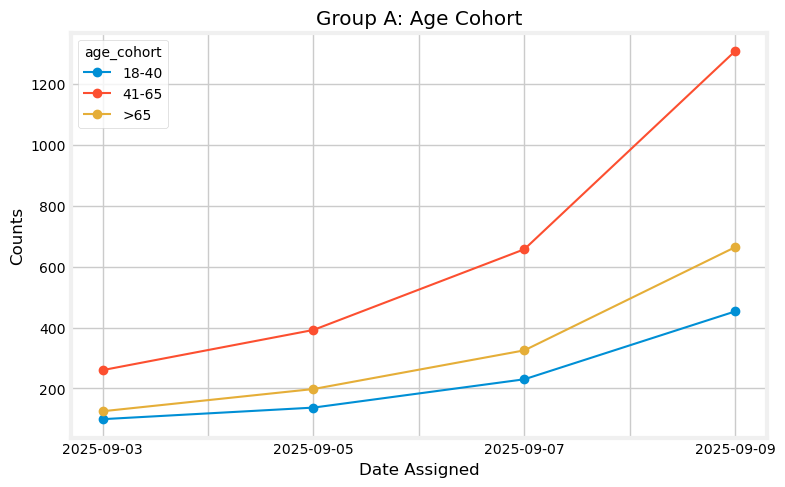

In [179]:
# computing buckets as a function of time

age_evolution = df[df['group'] == 'A'].groupby(['assign_date', 'age_cohort'])['user_id'].count()

age_evolution = age_evolution.unstack()
age_evolution.plot(figsize=(8,5), marker='o')
plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Group A: Age Cohort")
plt.grid(True)
plt.show()

del age_evolution

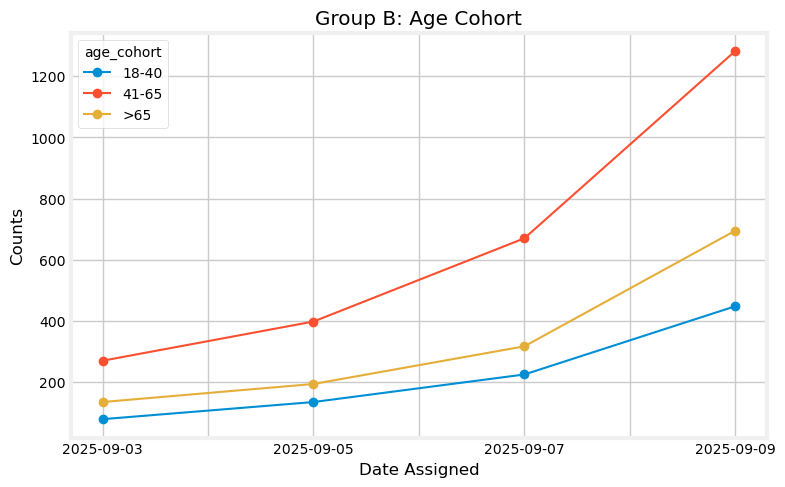

In [180]:
# computing buckets as a function of time

age_evolution = df[df['group'] == 'B'].groupby(['assign_date', 'age_cohort'])['user_id'].count()

age_evolution = age_evolution.unstack()
age_evolution.plot(figsize=(8,5), marker='o')
plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Group B: Age Cohort")
plt.grid(True)
plt.show()

del age_evolution

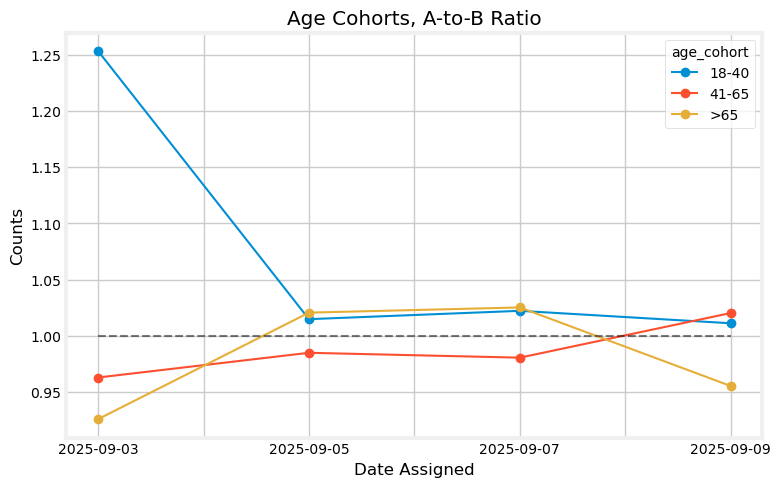

In [181]:
# computing buckets as a function of time

age_evolution = df[df['group'] == 'A'].groupby(['assign_date', 'age_cohort'])['user_id'].count() / df[df['group'] == 'B'].groupby(['assign_date', 'age_cohort'])['user_id'].count()

age_evolution = age_evolution.unstack()

age_evolution.plot(figsize=(8,5), marker='o')

plt.plot(age_evolution.index, np.ones_like(age_evolution.index), color='k', ls='--', alpha=0.5)

plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Age Cohorts, A-to-B Ratio")
plt.grid(True)
plt.show()

del age_evolution

#### Income Buckets

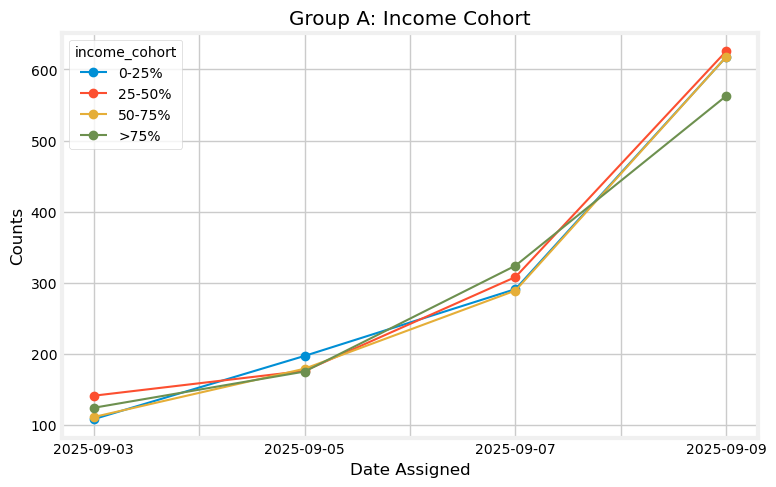

In [182]:
# computing buckets as a function of time

income_evolution = df[df['group'] == 'A'].groupby(['assign_date', 'income_cohort'])['user_id'].count()

income_evolution = income_evolution.unstack()
income_evolution.plot(figsize=(8,5), marker='o')
plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Group A: Income Cohort")
plt.grid(True)
plt.show()

del income_evolution

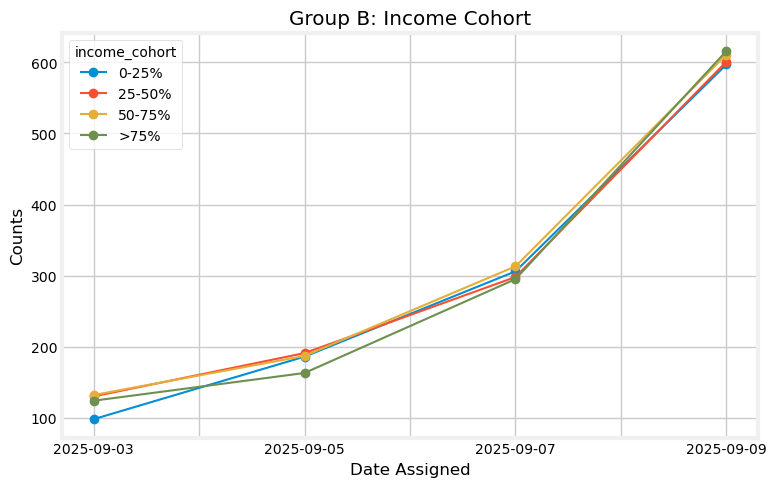

In [183]:
# computing buckets as a function of time

income_evolution = df[df['group'] == 'B'].groupby(['assign_date', 'income_cohort'])['user_id'].count()

income_evolution = income_evolution.unstack()
income_evolution.plot(figsize=(8,5), marker='o')
plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Group B: Income Cohort")
plt.grid(True)
plt.show()

del income_evolution

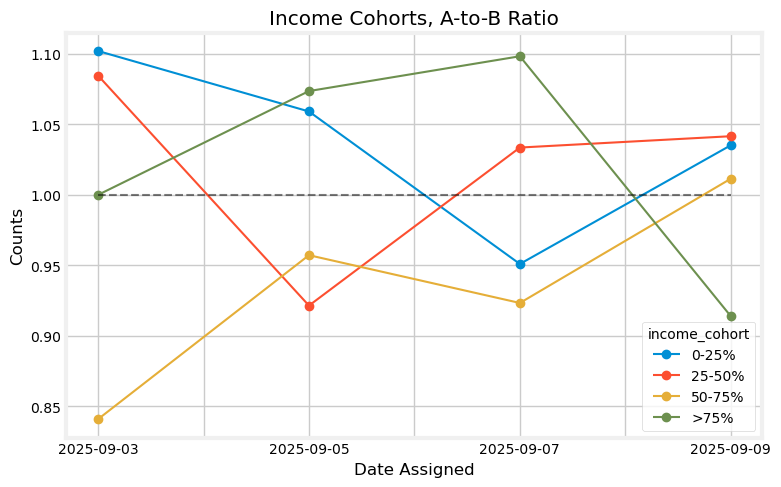

In [184]:
# computing buckets as a function of time

income_evolution = df[df['group'] == 'A'].groupby(['assign_date', 'income_cohort'])['user_id'].count() / df[df['group'] == 'B'].groupby(['assign_date', 'income_cohort'])['user_id'].count()

income_evolution = income_evolution.unstack()

income_evolution.plot(figsize=(8,5), marker='o')

plt.plot(income_evolution.index, np.ones_like(income_evolution.index), color='k', ls='--', alpha=0.5)

plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Income Cohorts, A-to-B Ratio")
plt.grid(True)
plt.show()

del income_evolution

#### Balance Buckets

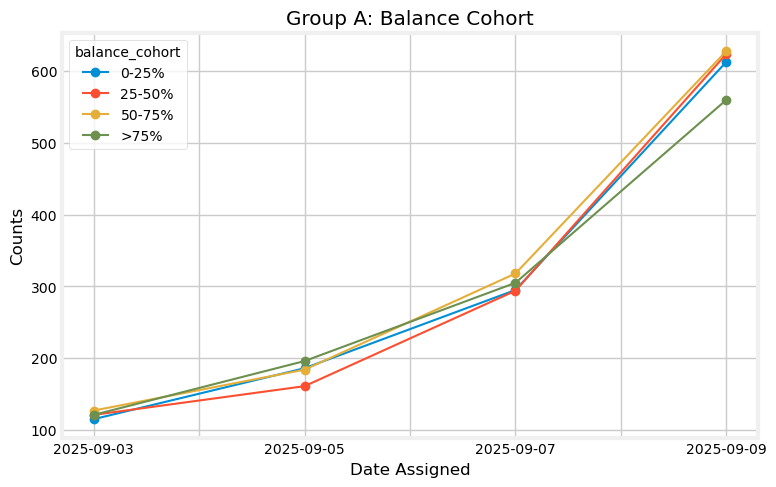

In [185]:
# computing buckets as a function of time

balance_evolution = df[df['group'] == 'A'].groupby(['assign_date', 'balance_cohort'])['user_id'].count()

balance_evolution = balance_evolution.unstack()
balance_evolution.plot(figsize=(8,5), marker='o')
plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Group A: Balance Cohort")
plt.grid(True)
plt.show()

del balance_evolution

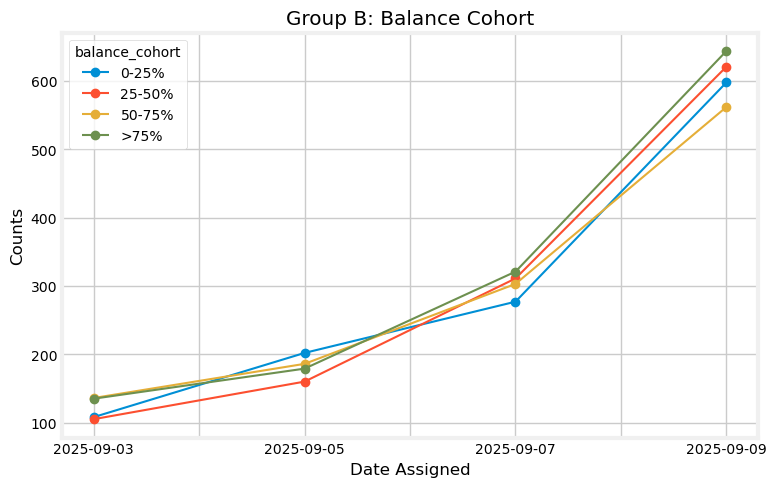

In [186]:
# computing buckets as a function of time

balance_evolution = df[df['group'] == 'B'].groupby(['assign_date', 'balance_cohort'])['user_id'].count()

balance_evolution = balance_evolution.unstack()
balance_evolution.plot(figsize=(8,5), marker='o')
plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Group B: Balance Cohort")
plt.grid(True)
plt.show()

del balance_evolution

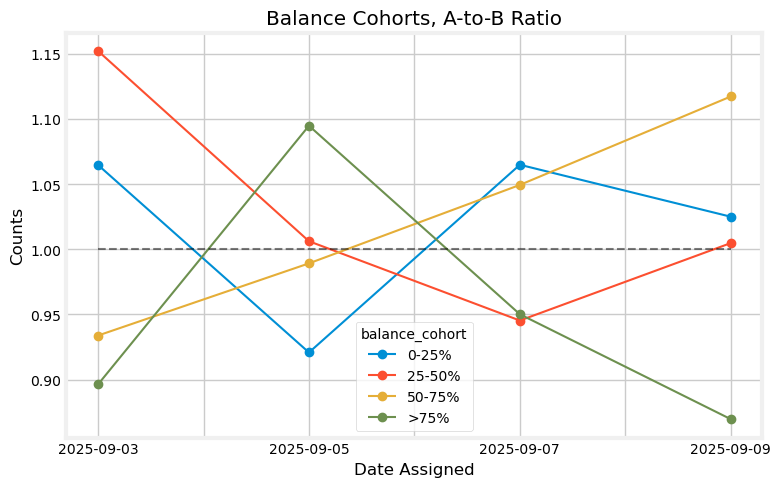

In [187]:
# computing buckets as a function of time

balance_evolution = df[df['group'] == 'A'].groupby(['assign_date', 'balance_cohort'])['user_id'].count() / df[df['group'] == 'B'].groupby(['assign_date', 'balance_cohort'])['user_id'].count()

balance_evolution = balance_evolution.unstack()

balance_evolution.plot(figsize=(8,5), marker='o')

plt.plot(balance_evolution.index, np.ones_like(balance_evolution.index), color='k', ls='--', alpha=0.5)

plt.xlabel("Date Assigned")
plt.ylabel("Counts")
plt.title("Balance Cohorts, A-to-B Ratio")
plt.grid(True)
plt.show()

del balance_evolution

#### Proportions

In [188]:
def props_time_fn(group, data):

    df = data.copy()

    conversion_dates = sorted(list(df[df['conversion_date'].isna() == False]['conversion_date'].sort_values().unique()) + list(df['assign_date'].unique()))
    conversion_dates = np.unique(conversion_dates)
    conversion_dates = pd.date_range(pd.to_datetime(conversion_dates[0]),
                                     pd.to_datetime(conversion_dates[-1]),
                                     freq='d')
    conversion_dates = conversion_dates.astype(str)

    df = df[df['group'] == group]

    counts = df.groupby(['assign_date','rollout_group']).size().unstack(fill_value=0).sum(axis=1)
    counts = counts.reindex(conversion_dates, fill_value=0)
    counts = counts.cumsum()

    conversions = df.groupby('conversion_date')['converted'].sum()
    conversions = conversions.reindex(conversion_dates, fill_value=0)
    conversions = conversions.cumsum()

    props_time = conversions/counts

    return props_time

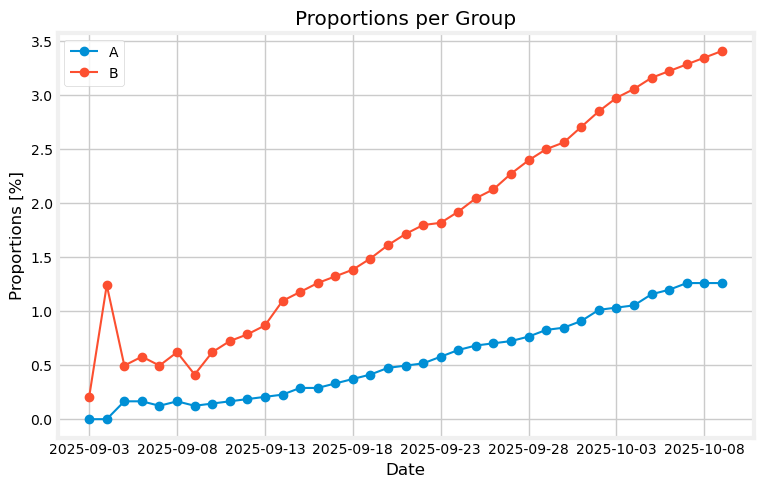

In [189]:
(props_time_fn('A', df)*100).plot(figsize=(8,5), marker='o', label='A')
(props_time_fn('B', df)*100).plot(figsize=(8,5), marker='o', label='B')

plt.xlabel("Date")
plt.ylabel("Proportions [%]")
plt.title("Proportions per Group")
plt.legend()
plt.grid(True)
plt.show()

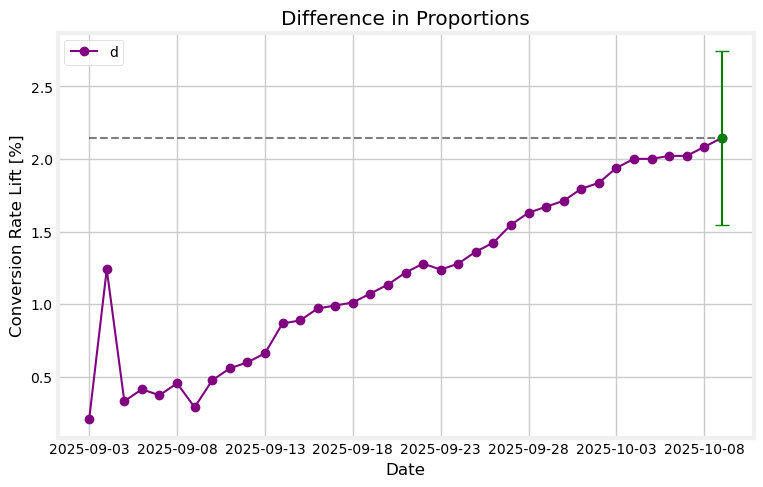

In [190]:
diffs = (props_time_fn('B', df)-props_time_fn('A', df))
diffs *= 100
diffs.plot(figsize=(8,5), marker='o', label=r'd', color='purple')

refs = pd.Series(diffs.iloc[-1], index=props_time_fn('B', df).index)
refs.plot(figsize=(8,5), color='k', ls='--', alpha=0.5)

mean, ci = summary['prop_mean_CI']
lower, upper = ci

mean *= 100
lower *= 100
upper *= 100

# xpos = diffs.index[-1]
xpos = len(diffs) - 1

yerr = np.array([[mean - lower], [upper - mean]])  # shape [[bottom], [top]]
plt.errorbar([xpos], [mean], yerr=yerr, fmt='o', capsize=5, color='green')

plt.xlabel("Date")
plt.ylabel("Conversion Rate Lift [%]")
plt.title("Difference in Proportions")
plt.legend()
plt.grid(True)
plt.show()

del diffs, refs, mean, ci, lower, upper, xpos, yerr

#### Contribution Growth

In [191]:
def means_time_fn(group, data):

    df = data.copy()

    conversion_dates = sorted(list(df[df['conversion_date'].isna() == False]['conversion_date'].sort_values().unique()) + list(df['assign_date'].unique()))
    conversion_dates = np.unique(conversion_dates)
    conversion_dates = pd.date_range(pd.to_datetime(conversion_dates[0]),
                                     pd.to_datetime(conversion_dates[-1]),
                                     freq='d')
    conversion_dates = conversion_dates.astype(str)

    df = df[df['group'] == group]

    counts = df.groupby(['assign_date','rollout_group']).size().unstack(fill_value=0).sum(axis=1)
    counts = counts.reindex(conversion_dates, fill_value=0)
    counts = counts.cumsum()

    deltas = df.groupby('conversion_date')['delta_pct'].sum()
    deltas = deltas.reindex(conversion_dates, fill_value=0)
    deltas = deltas.cumsum()

    means_time = deltas/counts

    return means_time

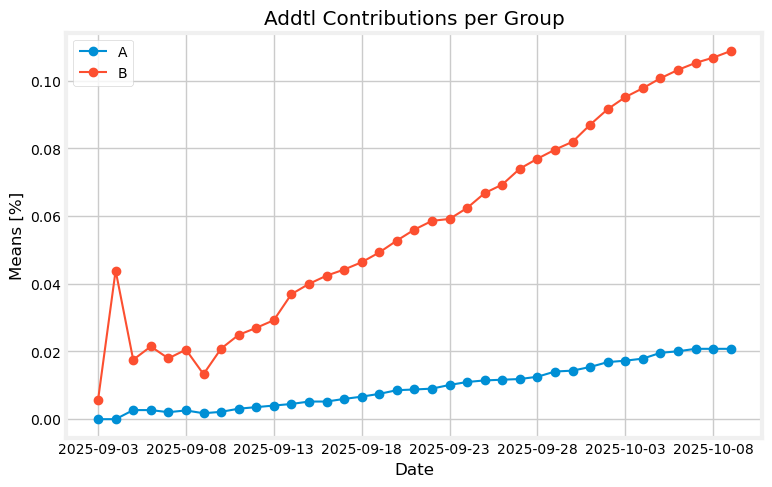

In [192]:
(means_time_fn('A', df)).plot(figsize=(8,5), marker='o', label='A')
(means_time_fn('B', df)).plot(figsize=(8,5), marker='o', label='B')

plt.xlabel("Date")
plt.ylabel("Means [%]")
plt.title("Addtl Contributions per Group")
plt.legend()
plt.grid(True)
plt.show()

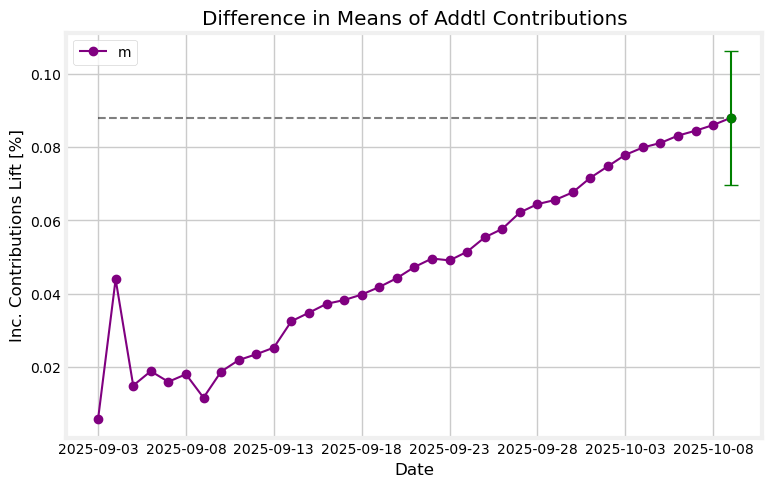

In [193]:
diffs = (means_time_fn('B', df)-means_time_fn('A', df))
diffs.plot(figsize=(8,5), marker='o', label=r'm', color='purple')

refs = pd.Series(diffs.iloc[-1], index=means_time_fn('B', df).index)
refs.plot(figsize=(8,5), color='k', ls='--', alpha=0.5)

mean, ci = summary['cont_mean_CI']
lower, upper = ci

# xpos = diffs.index[-1]
xpos = len(diffs) - 1

yerr = np.array([[mean - lower], [upper - mean]])  # shape [[bottom], [top]]
plt.errorbar([xpos], [mean], yerr=yerr, fmt='o', capsize=5, color='green')

plt.xlabel("Date")
plt.ylabel("Inc. Contributions Lift [%]")
plt.title("Difference in Means of Addtl Contributions")
plt.legend()
plt.grid(True)
plt.show()

del diffs, refs, mean, ci, lower, upper, xpos, yerr

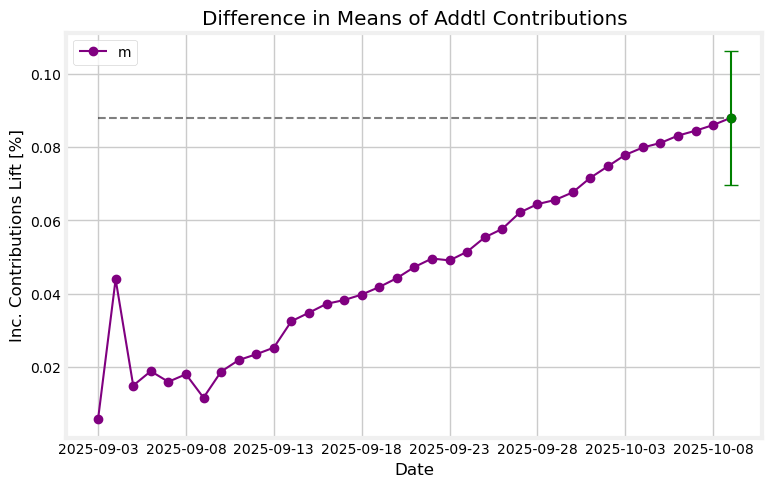

In [194]:
diffs = (means_time_fn('B', df)-means_time_fn('A', df))
diffs.plot(figsize=(8,5), marker='o', label=r'm', color='purple')

refs = pd.Series(diffs.iloc[-1], index=means_time_fn('B', df).index)
refs.plot(figsize=(8,5), color='k', ls='--', alpha=0.5)

mean, ci = summary['cont_mean_CI']
lower, upper = ci

# xpos = diffs.index[-1]
xpos = len(diffs) - 1

yerr = np.array([[mean - lower], [upper - mean]])  # shape [[bottom], [top]]
plt.errorbar([xpos], [mean], yerr=yerr, fmt='o', capsize=5, color='green')

plt.xlabel("Date")
plt.ylabel("Inc. Contributions Lift [%]")
plt.title("Difference in Means of Addtl Contributions")
plt.legend()
plt.grid(True)
plt.show()

del diffs, refs, mean, ci, lower, upper, xpos, yerr

#### Cleanup

In [195]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

### EDA & Business Value

We keep studying the same experiment:

In [196]:
summary

{'primary_metric': {'baseline_true': 0.013500000000000002,
  'treatment_true': 0.0385,
  'MDE': 0.02},
 'secondary_metric': {'baseline_true': 0.4054651081081644,
  'treatment_true': 1.0986122886681098,
  'MDE': 1.0},
 'alpha': 0.05,
 'power': 0.9,
 'n_arm': 4848,
 'prop_mean_CI': (0.021452145214521455,
  (0.015460884630442855, 0.027443405798600055)),
 'cont_mean_CI': (0.08797442244224422,
  (0.06971785455876048, 0.10623099032572797)),
 'rollouts': [0.1, 0.15, 0.25],
 'start_date': '2025-09-03',
 'duration_experiment': 30,
 'prep_time': 30,
 'nudge_cost_per_user': 0.001,
 'flat_cost_per_day': 208.33333333333334,
 'management_fees': 0.0007000000000000001}

#### Business Value: Quick Estimate

Some useful business definitions:

In [197]:
ONE_MILLION = 1.e6
ONE_BILLION = 1_000*ONE_MILLION
ONE_TRILLION = (ONE_MILLION)**2

Some important figures:

- Number of new converters attributable to treatment: $C_{\rm young,\,treat} = d\cdot N_{\rm young}$
- Increase in AUM attributable to treatment: $\Delta \mathrm{AUM}_{\rm treat} = \Delta \cdot I_{\rm young} \cdot C_{\rm young,\,treat}$
- Increase in revenue from fees on AUM, attributable to treatment: $\Delta \mathrm{Rev}_{\rm treat} = \mathrm{fee} \cdot \Delta\mathrm{AUM}$
- Future value of incr. in AUM due to returns: $\mathrm{FV}_{\rm treat} = \Delta \mathrm{AUM}_{\rm treat} \ \sum\limits_{i=0}^{T-1} (1+R)^i = \Delta \mathrm{AUM}_{\rm treat} \left( \frac{(1+R)^T - 1}{R} \right)$
- Total future of revenue from fees on AUM: $\mathrm{Tot\,Rev}_{\rm treat} = \mathrm{fee} \cdot \sum_{k=1}^{T}\, \mathrm{Balance}_k = \mathrm{fee} \cdot \Delta \mathrm{AUM}_{\rm treat} \left[ \frac{(1 + R)^{1 + T} -R(1+T) -1}{R^2} \right]$

In [198]:
def future_value_aum(aum, rate, lifetime):
    """Return the future value of assets under management (AUM).

    Parameters
    ----------
    aum : float
        Initial assets under management.
    rate : float
        Annualized return rate as a decimal.
    lifetime : int
        Investment horizon in years.

    Returns
    -------
    float
        Future value of the AUM after compounding.
    """

    factor = (np.power(1 + rate, lifetime) - 1)/rate

    fv = aum*factor

    return fv


def total_revenue(aum, rate, lifetime, fee):
    """
    Return the total revenue from fees on assets under management (AUM).

    Parameters
    ----------
    aum : float
        Initial assets under management.
    rate : float
        Annualized return rate as a decimal.
    lifetime : int
        Investment horizon in years.
    fee : float
        Annual management fee as a decimal.

    Returns
    -------
    float
        Total fee revenue over the investment horizon.
    """


    num = np.power(1+rate, 1+lifetime) - rate*(1+lifetime) - 1
    den = rate**2

    factor = num/den

    tot_rev = fee*aum*factor

    return tot_rev

So, for a quick example, assuming the benchmarks:

- 1 month of treatment only,
- Permanent conversion,
- No employer matching,
- $f_{\rm young} \approx 50\%$,
- $N_{\rm tot} = 50\mathrm{M}\,\text{people}$,
- $I_{\rm young} \approx \$100\mathrm{k}$,
- $d = 1.5\%$,
- $\Delta = 3\%$,
- $\mathrm{fee} = 0.07\%$,
- $T = 10\,\mathrm{yr}$,
- $R = 7\%/\mathrm{yr}$,

we get:

- $C_{\rm young,\,treat} = 375\text{ k}$,
- $\Delta \mathrm{AUM}_{\rm treat} = \$1.125\,\mathrm{B}/\mathrm{yr}$,
- $\Delta \mathrm{Rev}_{\rm treat} = 0.8\,\mathrm{M}/\mathrm{yr}$,
- $\mathrm{FV}_{\rm treat} = 15.5\,\mathrm{B}$,
- $\mathrm{Tot\,Rev}_{\rm treat} = 54\,\mathrm{M}$.

In [199]:
print("FV:", np.round(future_value_aum(1.125*ONE_BILLION, 0.07, 10) / ONE_BILLION, 1), "B")
print("Tot. Rev.:", np.round(total_revenue(1.125*ONE_BILLION, 0.07, 10, 0.07/100) / ONE_MILLION, 1), "M")

FV: 15.5 B
Tot. Rev.: 53.8 M


#### EDA

##### Preliminary

In [200]:
from scipy.stats import chi2_contingency

First, a quick description of the data:

In [201]:
df.head()

,user_id,rollout_group,assign_date,group,age,age_cohort,income,income_cohort,net_worth,networth_cohort,retirement_balance,balance_cohort,current_pct,employer_cap,last_login,acct_tenure,time_online_frac,conv_rate,converted,conversion_date,delta_pct,new_pct,user_delta_aum,employer_delta_aum,total_delta_aum,revenue,roi_exper,roi
0,945750,1,2025-09-03,A,53.376230,41-65,1.744088e+05,25-50%,5.711260e+05,25-50%,2.857971e+05,25-50%,12.75,7.50,22.9,3.927538,0.204,0.006437,0,NaN,0.0,12.75,0.0,0.0,0.0,0.0,-1.419111,-0.001
1,905513,1,2025-09-03,A,68.462552,>65,4.375918e+06,>75%,2.382419e+07,>75%,4.548036e+06,>75%,3.25,1.25,0.2,6.015857,0.146,0.006685,0,NaN,0.0,3.25,0.0,0.0,0.0,0.0,-1.419111,-0.001
2,142290,1,2025-09-03,A,75.140631,>65,1.772356e+05,25-50%,5.035178e+06,50-75%,1.752898e+06,>75%,4.00,6.75,2.2,0.755900,0.115,0.003272,0,NaN,0.0,4.00,0.0,0.0,0.0,0.0,-1.419111,-0.001
3,920046,1,2025-09-03,A,76.822404,>65,4.997691e+04,0-25%,1.907557e+05,0-25%,1.890942e+05,25-50%,12.00,9.75,60.8,2.701226,0.132,0.001190,0,NaN,0.0,12.00,0.0,0.0,0.0,0.0,-1.419111,-0.001
4,567441,1,2025-09-03,A,50.698605,41-65,1.392129e+06,>75%,1.590524e+07,>75%,1.020298e+06,50-75%,10.00,6.00,107.5,2.268217,0.193,0.012146,0,NaN,0.0,10.00,0.0,0.0,0.0,0.0,-1.419111,-0.001


In [202]:
df.describe(include='all')

,user_id,rollout_group,assign_date,group,age,age_cohort,income,income_cohort,net_worth,networth_cohort,retirement_balance,balance_cohort,current_pct,employer_cap,last_login,acct_tenure,time_online_frac,conv_rate,converted,conversion_date,delta_pct,new_pct,user_delta_aum,employer_delta_aum,total_delta_aum,revenue,roi_exper,roi
count,9696.000000,9696.000000,9696,9696,9696.000000,9696,9.696000e+03,9696,9.696000e+03,9696,9.696000e+03,9696,9696.000000,9696.000000,9696.000000,9696.000000,9696.000000,9696.000000,9696.000000,226,9696.000000,9696.000000,9.696000e+03,9696.000000,9.696000e+03,9696.000000,9696.000000,9696.000000
unique,NaN,NaN,4,2,NaN,3,NaN,4,NaN,4,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,2025-09-09,A,NaN,41-65,NaN,25-50%,NaN,50-75%,NaN,>75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4850,4848,NaN,5237,NaN,2471,NaN,2456,NaN,2461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,551352.987624,3.150578,NaN,NaN,55.945438,NaN,8.094492e+05,NaN,1.106035e+07,NaN,1.452746e+06,NaN,7.858730,7.727568,29.837356,4.854309,0.190015,0.025761,0.023309,NaN,0.064769,7.923499,1.225747e+03,370.300299,1.596048e+03,1.117233,-0.301877,1.116233
std,259841.001117,1.013379,NaN,NaN,14.776237,NaN,1.999444e+06,NaN,2.963914e+07,NaN,2.195424e+06,NaN,3.317333,3.298448,29.724042,4.642043,0.049748,0.033915,0.150889,NaN,0.460685,3.340971,2.247261e+04,6972.885775,2.639120e+04,18.473838,18.473838,18.473838
min,100069.000000,1.000000,NaN,NaN,19.032594,NaN,2.875528e+04,NaN,1.130914e+04,NaN,3.373554e+03,NaN,0.250000,0.250000,0.000000,0.010181,0.011000,0.000350,0.000000,NaN,0.000000,0.250000,0.000000e+00,0.000000,0.000000e+00,0.000000,-1.419111,-0.001000
25%,324522.250000,3.000000,NaN,NaN,44.829204,NaN,9.531711e+04,NaN,3.584928e+05,NaN,1.215124e+05,NaN,5.250000,5.250000,8.600000,1.447246,0.154000,0.006220,0.000000,NaN,0.000000,5.500000,0.000000e+00,0.000000,0.000000e+00,0.000000,-1.419111,-0.001000
50%,552089.500000,4.000000,NaN,NaN,56.927495,NaN,1.818774e+05,NaN,1.243279e+06,NaN,5.097448e+05,NaN,7.750000,7.500000,20.800000,3.434944,0.189000,0.013930,0.000000,NaN,0.000000,7.750000,0.000000e+00,0.000000,0.000000e+00,0.000000,-1.419111,-0.001000
75%,776021.750000,4.000000,NaN,NaN,67.039144,NaN,5.018692e+05,NaN,5.706232e+06,NaN,1.764070e+06,NaN,10.250000,10.000000,41.300000,6.775097,0.225250,0.030774,0.000000,NaN,0.000000,10.250000,0.000000e+00,0.000000,0.000000e+00,0.000000,-1.419111,-0.001000


In [203]:
df.rename(columns={'group':"Group",
                   'age':"Age [yrs]",
                   'age_cohort':"Age Cohort",
                   'income':"Income [$100k]",
                   'income_cohort':"Income Cohort",
                   'net_worth':"Net Worth [$100k]",
                   'networth_cohort':"Net Worth Cohort",
                   'retirement_balance':"Balance [$100k]",
                   'balance_cohort':"Balance Cohort",
                   'current_pct':"Current Contribution [%]",
                   'employer_cap':"Employer Contribution Cap [%]",
                   'last_login':"Last Login [Days]",
                   'acct_tenure':"Account Tenure [yrs]",
                   'time_online_frac':"Hrs. Online/Day",
                   'conv_rate':"Conversion Rate [%]",
                   'converted':"Converted?",
                   'delta_pct':"Addtl Contribution [%]",
                   'new_pct':"New Current Contribution [%]",
                   'employer_delta_aum':"Addtl AUM from Client [$100k]",
                   'total_delta_aum':"Total Addtl AUM [$100k]",
                   'revenue':"Revenue [$]",
                   'roi_exper':"ROI [$, nudge + experiment]",
                   'roi':"ROI [$, nudge only]"
                  }, inplace=True)

df["Conversion Rate [%]"] *= 100
df["Income [$100k]"] /= 1.E5
df["Net Worth [$100k]"] /= 1.E5
df["Balance [$100k]"] /= 1.E5
df["Addtl AUM from Client [$100k]"] /= 1.E5
df["Total Addtl AUM [$100k]"] /= 1.E5

##### Conversions and Contributions

Conversion Rate $p \, [\%]$

~Terminally~ Financially Online:

<Figure size 200x200 with 0 Axes>

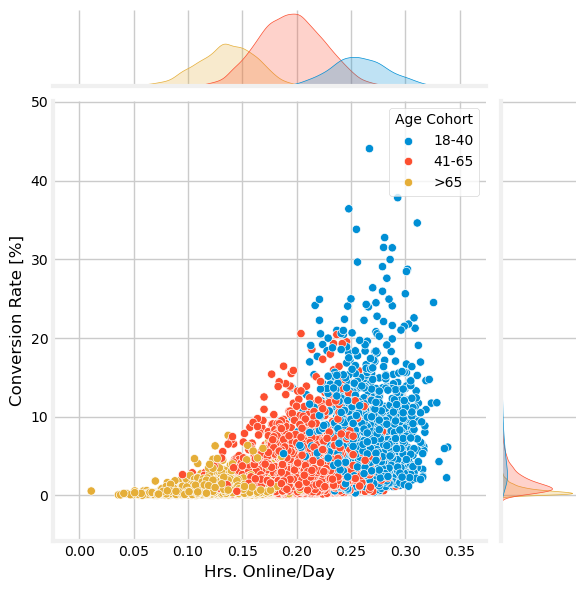

In [204]:
plt.figure(figsize=(2, 2))
sns.jointplot(data=df, x='Hrs. Online/Day', y='Conversion Rate [%]', hue='Age Cohort', hue_order=['18-40','41-65','>65'])
plt.show()

<Axes: xlabel='Group', ylabel='Conversion Rate [%]'>

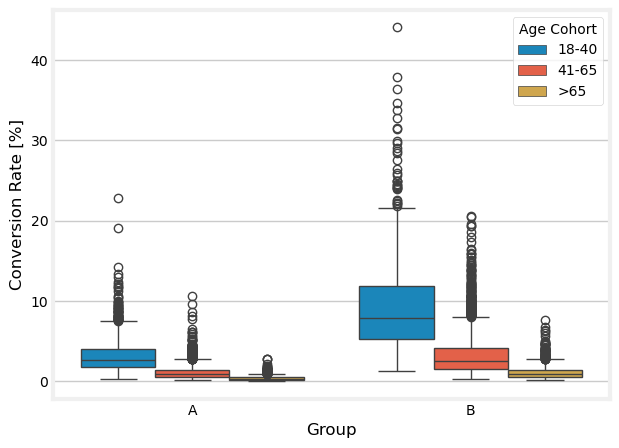

In [205]:
sns.boxplot(data=df, x='Group', y="Conversion Rate [%]", hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])

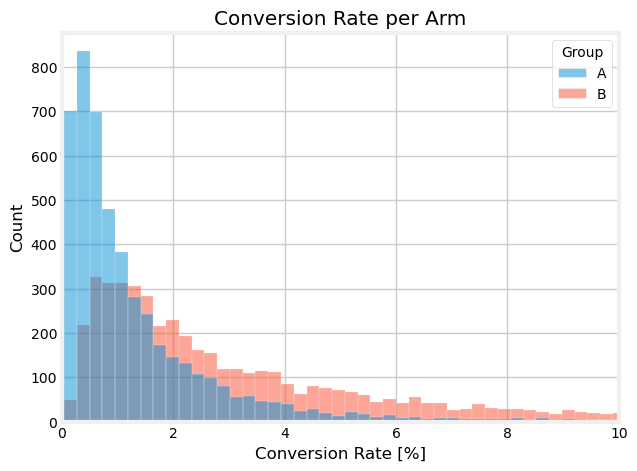

In [206]:
sns.histplot(data=df, x="Conversion Rate [%]", hue='Group')
plt.xlim(0, 10);
plt.title("Conversion Rate per Arm");

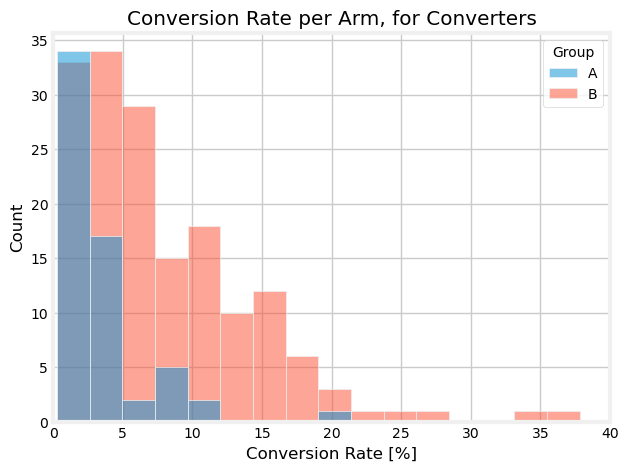

In [207]:
sns.histplot(data=df[df['Converted?']==1], x='Conversion Rate [%]', hue='Group')
plt.xlim(0, 40);
plt.title("Conversion Rate per Arm, for Converters");

$\Delta \, [\%]$

<Figure size 200x200 with 0 Axes>

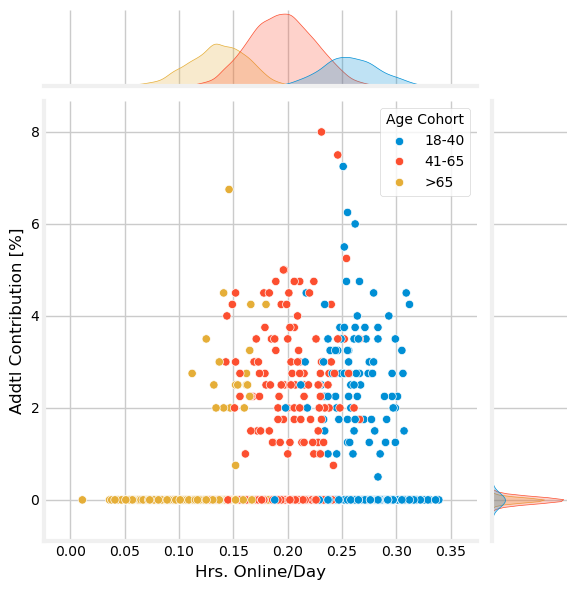

In [208]:
plt.figure(figsize=(2, 2))
sns.jointplot(data=df, x='Hrs. Online/Day', y="Addtl Contribution [%]", hue='Age Cohort', hue_order=['18-40','41-65','>65'])
plt.show()

In [209]:
df[df['Converted?']==1].groupby(['Group','Age Cohort'])["Addtl Contribution [%]"].mean()

Group  Age Cohort
A      18-40         1.592593
       41-65         1.666667
       >65           1.937500
B      18-40         3.250000
       41-65         3.156627
       >65           3.171875
Name: Addtl Contribution [%], dtype: float64

<Axes: xlabel='Group', ylabel='Addtl Contribution [%]'>

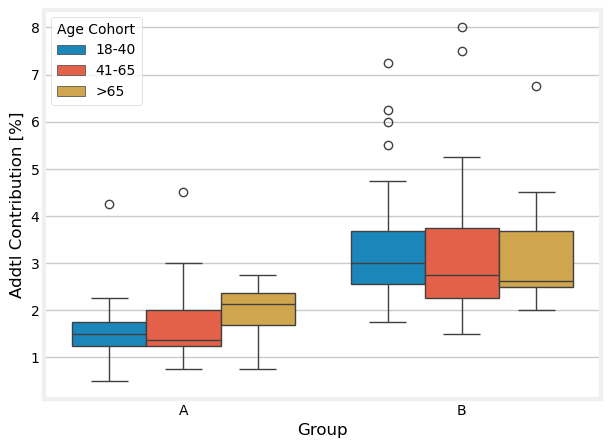

In [210]:
sns.boxplot(data=df[df['Converted?']==1], x='Group', y="Addtl Contribution [%]", hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])

Means of the log:

In [211]:
df[df['Converted?']==1].groupby(['Group','Age Cohort'])["Addtl Contribution [%]"].agg(lambda x: np.mean(np.log(x)))

Group  Age Cohort
A      18-40         0.390919
       41-65         0.427844
       >65           0.556999
B      18-40         1.131595
       41-65         1.088840
       >65           1.094374
Name: Addtl Contribution [%], dtype: float64

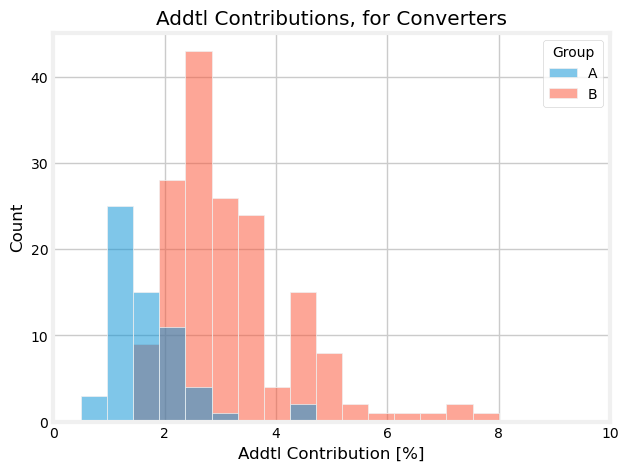

In [212]:
sns.histplot(data=df[df['Converted?']==1], x="Addtl Contribution [%]", hue='Group')
plt.xlim(0, 10);
plt.title("Addtl Contributions, for Converters");

##### Business Value Revisited

Revenue:

In [213]:
print("Sum:")
display(df.groupby(['Group','Age Cohort'])['Revenue [$]'].sum())
print("\nMean:")
display(df.groupby(['Group','Age Cohort'])['Revenue [$]'].mean())

Sum:


Group  Age Cohort
A      18-40          605.019004
       41-65         1193.774167
       >65            295.554668
B      18-40         2554.573454
       41-65         4953.335857
       >65           1230.437730
Name: Revenue [$], dtype: float64


Mean:


Group  Age Cohort
A      18-40         0.658345
       41-65         0.456161
       >65           0.225270
B      18-40         2.880015
       41-65         1.890586
       >65           0.917552
Name: Revenue [$], dtype: float64

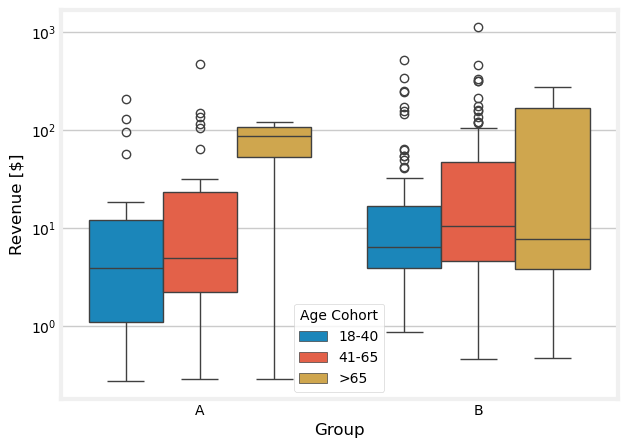

In [214]:
sns.boxplot(data=df[df['Converted?']==1], x='Group', y='Revenue [$]', hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])
plt.yscale('log')

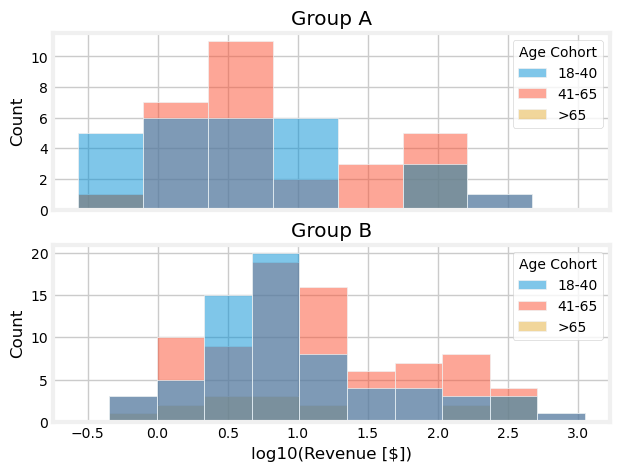

In [215]:
tmp = df[df['Converted?']==1].copy()
tmp['log10(Revenue [$])'] = np.log10(tmp['Revenue [$]'])

fig, axs = plt.subplots(2,1, sharex=True)
sns.histplot(tmp[tmp['Group']=='A'], x='log10(Revenue [$])', hue='Age Cohort', ax=axs[0], hue_order=['18-40','41-65','>65'])
axs[0].set_title('Group A')

sns.histplot(tmp[tmp['Group']=='B'], x='log10(Revenue [$])', hue='Age Cohort', ax=axs[1], hue_order=['18-40','41-65','>65'])
axs[1].set_title('Group B')

del tmp

<Axes: xlabel='Group', ylabel='Revenue [$]'>

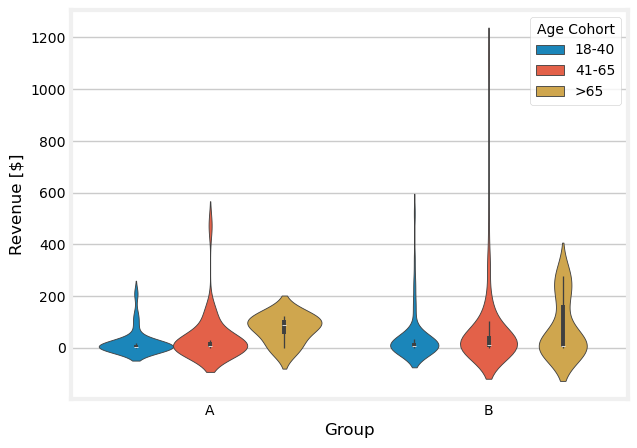

In [216]:
sns.violinplot(data=df[df['Converted?']==1], x='Group', y='Revenue [$]', hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])
# plt.yscale('log')

Let us now focus on projected AUM, Revenue, and ROI on whole population, per age cohort.

In [217]:
print("conversion rate, per group & age cohort")
conversion_rate = df.groupby(['Group', 'Age Cohort'])['Converted?'].agg('mean')
display(conversion_rate)

print("std of conversion rate, per group & age cohort")
std_conversion = np.sqrt(conversion_rate*(1-conversion_rate))
display(std_conversion)

print("age preponderance (full population data)")
shallow_copy = full_data.copy()
shallow_copy['Age Cohort'] = shallow_copy['age_cohort']
age_preponderance1 = shallow_copy.groupby('Age Cohort')['Age Cohort'].count()/len(full_data)
display(age_preponderance1)
del shallow_copy

print("age preponderance (experimental data)")
age_preponderance2 = df.groupby('Age Cohort')['Age Cohort'].count()/len(df)
display(age_preponderance2)

print("age preponderance, per group")
age_preponderance3 = df.groupby(['Group','Age Cohort'])['Age Cohort'].count()/(len(df)/2)
display(age_preponderance3)

tmp = df[df['Converted?']==1].copy()
# tmp['log10(Revenue [$])'] = np.log10(tmp['Revenue [$]'])

print("mean and std of addtl aum from client, per group & age cohort, conditioned on conversion")
aum_mean_std_cohorts = tmp.groupby(['Group', 'Age Cohort'])["Addtl AUM from Client [$100k]"].agg(['mean', 'std'])*100_000
display(aum_mean_std_cohorts)

print("mean and std of revenue (incl. employer), per group & age cohort, conditioned on conversion")
rev_mean_std_cohorts = tmp.groupby(['Group', 'Age Cohort'])['Revenue [$]'].agg(['mean', 'std'])
display(rev_mean_std_cohorts)

conversion rate, per group & age cohort


Group  Age Cohort
A      18-40         0.029380
       41-65         0.011464
       >65           0.003049
B      18-40         0.074408
       41-65         0.031679
       >65           0.011931
Name: Converted?, dtype: float64

std of conversion rate, per group & age cohort


Group  Age Cohort
A      18-40         0.168869
       41-65         0.106452
       >65           0.055132
B      18-40         0.262434
       41-65         0.175145
       >65           0.108577
Name: Converted?, dtype: float64

age preponderance (full population data)


...

Group  Age Cohort
A      18-40         0.189563
       41-65         0.539810
       >65           0.270627
B      18-40         0.182962
       41-65         0.540429
       >65           0.276609
Name: Age Cohort, dtype: float64

mean and std of addtl aum from client, per group & age cohort, conditioned on conversion


mean           std
Group Age Cohort                            
A     18-40       11820.021670  30948.091796
      41-65       15592.323881  36364.302158
      >65         37758.396376  31790.677703
B     18-40       13528.414270  37925.437863
      41-65       17577.097702  51046.263557
      >65         18794.585140  51071.598157

mean and std of revenue (incl. employer), per group & age cohort, conditioned on conversion


mean         std
Group Age Cohort                       
A     18-40       22.408111   48.185909
      41-65       39.792472   92.360451
      >65         73.888667   53.395592
B     18-40       38.705658   88.407333
      41-65       59.678745  145.520515
      >65         76.902358  111.965656

**ADDTL CLIENT AUM**

Computing additional AUM (from client) per age cohort, according to three slightly different formulas (depending on three slightly different ways of computing the preponderance of each age cohort), **1st method**:

In [218]:
print("Total population: 50M investors\n**************************\n")

AllRev = aum_mean_std_cohorts['mean'].mul((conversion_rate*age_preponderance1*(50*ONE_MILLION)), axis=0)
Arev = AllRev.loc['A',:]
Brev = AllRev.loc['B',:]
print("Addtl client AUM [$] (age preponderance from full population's)")
display(Brev-Arev)
print("Total Addtl client AUM [$M]:", (Brev-Arev).sum() / ONE_MILLION)


AllRev = aum_mean_std_cohorts['mean'].mul((conversion_rate*age_preponderance2*(50*ONE_MILLION)), axis=0)
Arev = AllRev.loc['A',:]
Brev = AllRev.loc['B',:]
print("Addtl client AUM [$] (age preponderance from experimental sample's)")
display(Brev-Arev)
print("Total Addtl client AUM [$M]:", (Brev-Arev).sum() / ONE_MILLION)


AllRev = aum_mean_std_cohorts['mean'].mul((conversion_rate.mul(age_preponderance3, axis=0) * 50*ONE_MILLION), axis=0)
Arev = AllRev.loc['A',:]
Brev = AllRev.loc['B',:]
print("Addtl client AUM [$] (age preponderance from experimental groups')")
display(Brev-Arev)
print("Total Addtl client AUM [$M]:", (Brev-Arev).sum() / ONE_MILLION)

del AllRev, Arev, Brev

Total population: 50M investors
**************************

Addtl client AUM [$] (age preponderance from full population's)


Age Cohort
18-40    5.927267e+09
41-65    1.030954e+10
>65      1.499754e+09
dtype: float64

Total Addtl client AUM [$M]: 17736.561905220267
Addtl client AUM [$] (age preponderance from experimental sample's)


Age Cohort
18-40    6.140646e+09
41-65    1.021066e+10
>65      1.492977e+09
dtype: float64

Total Addtl client AUM [$M]: 17844.287312076598
Addtl client AUM [$] (age preponderance from experimental groups')


Age Cohort
18-40    5.917231e+09
41-65    1.022204e+10
>65      1.543727e+09
dtype: float64

Total Addtl client AUM [$M]: 17683.00254034975


**2nd method** to compute the ATE on Addtl Client AUM (matches groupwise age cohort preponderance):

In [219]:
ate_aum = pd.Series()
ate_aum = (df.groupby(['Group','Age Cohort'])["Addtl AUM from Client [$100k]"].sum()['B'] - df.groupby(['Group','Age Cohort'])["Addtl AUM from Client [$100k]"].sum()['A'])/(len(df)/2)
ate_aum *= 100_000

ate_aum.name = "ATE Addtl Client AUM Per Person [$]"

display(ate_aum)
display(ate_aum*(50*ONE_MILLION))
print((ate_aum*(50)).sum())

Age Cohort
18-40    118.344628
41-65    204.440881
>65       30.874541
Name: ATE Addtl Client AUM Per Person [$], dtype: float64

Age Cohort
18-40    5.917231e+09
41-65    1.022204e+10
>65      1.543727e+09
Name: ATE Addtl Client AUM Per Person [$], dtype: float64

17683.002540349753


**3rd method** (using the computation of means and CI, also matches age cohort preponderance).

_N.B.: the CI depend on the size of the sample (scaling as std/n), so we do not extrapolate them into the whole population._

In [220]:
means_diff_CI(df[df['Group']=='A']["Addtl AUM from Client [$100k]"]*100_000,
              df[df['Group']=='B']["Addtl AUM from Client [$100k]"]*100_000,
              alpha=0.05,
              use_tdist=False)[0] * (50*ONE_MILLION) / ONE_MILLION

np.float64(17683.002540349753)

**REVENUE**

Computing Revenue per age cohort, according to three slightly different formulas (depending on three slightly different ways of computing the preponderance of each age cohort):

In [221]:
print("Total population: 50M investors\n**************************\n")

AllRev = rev_mean_std_cohorts['mean'].mul((conversion_rate*age_preponderance1*(50*ONE_MILLION)), axis=0)
Arev = AllRev.loc['A',:]
Brev = AllRev.loc['B',:]
print("Revenue [$] (from full population's age preponderance)")
display(Brev-Arev)
print("Total Revenue [$M]:", (Brev-Arev).sum() / ONE_MILLION)


AllRev = rev_mean_std_cohorts['mean'].mul((conversion_rate*age_preponderance2*(50*ONE_MILLION)), axis=0)
Arev = AllRev.loc['A',:]
Brev = AllRev.loc['B',:]
print("Revenue [$] (from experimental sample's age preponderance)")
display(Brev-Arev)
print("Total Revenue [$M]:", (Brev-Arev).sum() / ONE_MILLION)


AllRev = rev_mean_std_cohorts['mean'].mul((conversion_rate.mul(age_preponderance3, axis=0) * 50*ONE_MILLION), axis=0)
Arev = AllRev.loc['A',:]
Brev = AllRev.loc['B',:]
print("Revenue [$] (from experimental groups' age preponderance)")
display(Brev-Arev)
print("Total Revenue [$M]:", (Brev-Arev).sum() / ONE_MILLION)

del AllRev, Arev, Brev

Total population: 50M investors
**************************

Revenue [$] (from full population's age preponderance)


Age Cohort
18-40    1.997170e+07
41-65    3.911318e+07
>65      9.514032e+06
dtype: float64

Total Revenue [$M]: 68.59891725151988
Revenue [$] (from experimental sample's age preponderance)


Age Cohort
18-40    2.069068e+07
41-65    3.873805e+07
>65      9.471041e+06
dtype: float64

Total Revenue [$M]: 68.89977221220434
Revenue [$] (from experimental groups' age preponderance)


Age Cohort
18-40    2.010679e+07
41-65    3.877436e+07
>65      9.641946e+06
dtype: float64

Total Revenue [$M]: 68.52309408291298


**2nd method** to compute the ATE on Revenue (matches groupwise age cohort preponderance):

In [222]:
ate_rev = pd.Series()
ate_rev = (df.groupby(['Group','Age Cohort'])['Revenue [$]'].sum()['B'] - df.groupby(['Group','Age Cohort'])['Revenue [$]'].sum()['A'])/(len(df)/2)

ate_rev.name = "ATE Revenue Per Person [$]"

display(ate_rev)
display(ate_rev*(50*ONE_MILLION))
print((ate_rev*(50)).sum())

Age Cohort
18-40    0.402136
41-65    0.775487
>65      0.192839
Name: ATE Revenue Per Person [$], dtype: float64

Age Cohort
18-40    2.010679e+07
41-65    3.877436e+07
>65      9.641946e+06
Name: ATE Revenue Per Person [$], dtype: float64

68.52309408291299


**3rd method** (using the computation of means and CI, also matches age cohort preponderance).

_N.B.: the CI depend on the size of the sample (scaling as std/n), so we do not extrapolate them into the whole population._

In [223]:
means_diff_CI(df[df['Group']=='A']["Revenue [$]"],
              df[df['Group']=='B']["Revenue [$]"],
              alpha=0.05,
              use_tdist=False)[0] * (50*ONE_MILLION) / ONE_MILLION

np.float64(68.52309408291299)

ROI (including nudge and experiment cost):

In [224]:
print("Sum:")
display(df.groupby(['Group','Age Cohort'])['ROI [$, nudge + experiment]'].sum())
print("\nMean:")
display(df.groupby(['Group','Age Cohort'])['ROI [$, nudge + experiment]'].mean())

display(df.groupby(['Group','Age Cohort'])['ROI [$, nudge + experiment]'].sum().sum())

Sum:


Group  Age Cohort
A      18-40         -699.143601
       41-65        -2520.038171
       >65          -1566.318389
B      18-40         1295.822387
       41-65         1235.266187
       >65           -672.589532
Name: ROI [$, nudge + experiment], dtype: float64


Mean:


Group  Age Cohort
A      18-40        -0.760766
       41-65        -0.962949
       >65          -1.193840
B      18-40         1.460905
       41-65         0.471476
       >65          -0.501558
Name: ROI [$, nudge + experiment], dtype: float64

np.float64(-2927.001120280907)

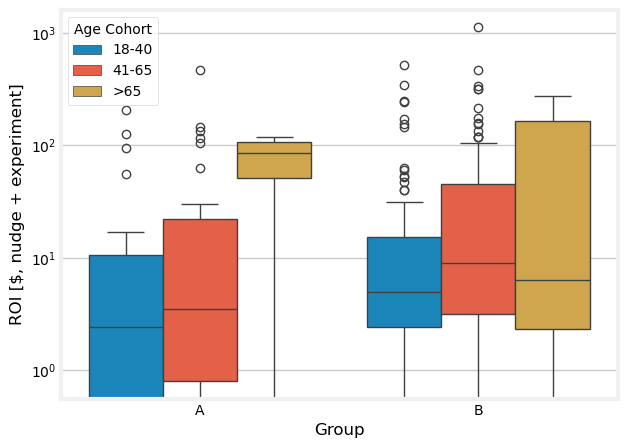

In [225]:
sns.boxplot(data=df[df['Converted?']==1], x='Group', y='ROI [$, nudge + experiment]', hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])
plt.yscale('log')

ROI (including nudge cost only):

In [226]:
print("Sum:")
display(df.groupby(['Group','Age Cohort'])['ROI [$, nudge only]'].sum())
print("\nMean:")
display(df.groupby(['Group','Age Cohort'])['ROI [$, nudge only]'].mean())

Sum:


Group  Age Cohort
A      18-40          604.100004
       41-65         1191.157167
       >65            294.242668
B      18-40         2553.686454
       41-65         4950.715857
       >65           1229.096730
Name: ROI [$, nudge only], dtype: float64


Mean:


Group  Age Cohort
A      18-40         0.657345
       41-65         0.455161
       >65           0.224270
B      18-40         2.879015
       41-65         1.889586
       >65           0.916552
Name: ROI [$, nudge only], dtype: float64

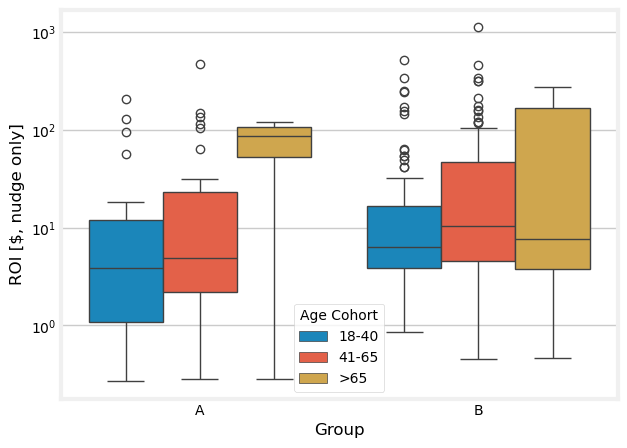

In [227]:
sns.boxplot(data=df[df['Converted?']==1], x='Group', y='ROI [$, nudge only]', hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])
plt.yscale('log')

<Axes: xlabel='Group', ylabel='ROI [$, nudge only]'>

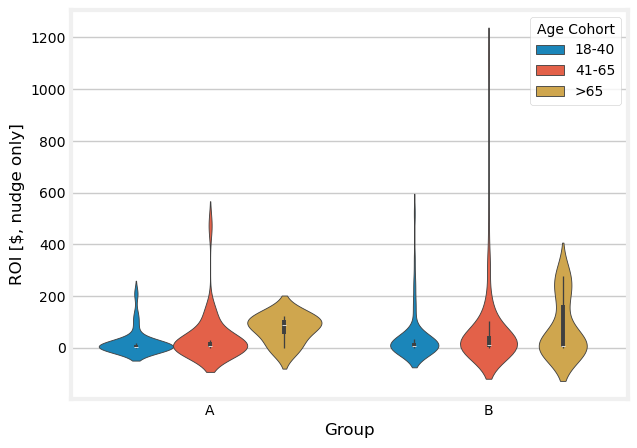

In [228]:
sns.violinplot(data=df[df['Converted?']==1], x='Group', y='ROI [$, nudge only]', hue='Age Cohort', order=['A', 'B'], hue_order=['18-40','41-65','>65'])
# plt.yscale('log')

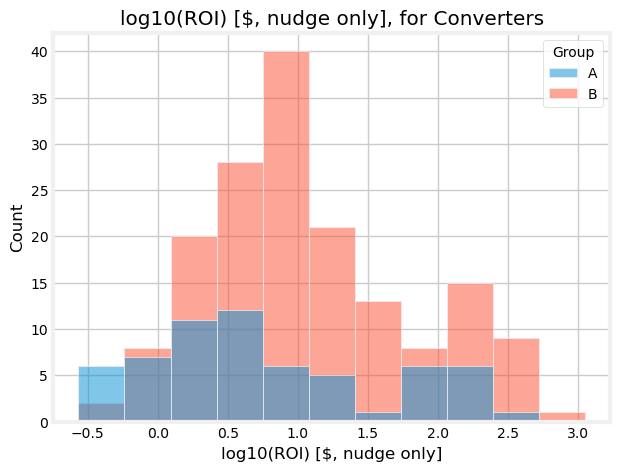

In [229]:
tmp = df[df['Converted?']==1].copy()
tmp["log10(ROI) [$, nudge only]"] = np.log10(tmp["ROI [$, nudge only]"])

sns.histplot(data=tmp, x="log10(ROI) [$, nudge only]", hue='Group')
# plt.xscale("log")
plt.title("log10(ROI) [$, nudge only], for Converters");
del tmp

We now compute the ROI (discounting the cost of a nudge only) that is attributable to the treatment, or ATE (i.e., B-A), per person, and decompose it according to age cohort.

**N.B.:** this is **not** the ATE ROI per age cohort person (i.e., these many dollars per 18-40 y.o.). Its sum is the *weighted* average of the ATE ROI in any given population, where the weight is given by the preponderance of each cohort (the fraction of the given population that is in that cohort). So each individual term is the ATE ROI times each age cohort weight. This can be used to compute the ATE ROI per age cohort for a population of *any* size.

In [230]:
ate_roi = pd.Series()
ate_roi = (df.groupby(['Group','Age Cohort'])['ROI [$, nudge only]'].sum()['B'] - df.groupby(['Group','Age Cohort'])['ROI [$, nudge only]'].sum()['A'])/(len(df)/2)

ate_roi.name = "ATE ROI Per Person [$, nudge only]"

display(ate_roi)

print("For 50M investors in ABC investments, the ATE per cohort on ROI is:")
display((ate_roi*(50_000_000)/ONE_MILLION))

Age Cohort
18-40    0.402142
41-65    0.775487
>65      0.192833
Name: ATE ROI Per Person [$, nudge only], dtype: float64

For 50M investors in ABC investments, the ATE per cohort on ROI is:


Age Cohort
18-40    20.107121
41-65    38.774326
>65       9.641647
Name: ATE ROI Per Person [$, nudge only], dtype: float64

It seems like middle aged investors contribute more... but the ROI of the younger ones compounds for longer!

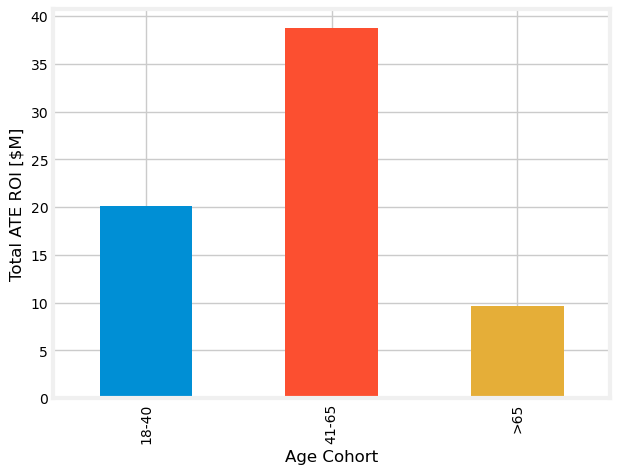

In [231]:
(ate_roi*(50_000_000)/ONE_MILLION).plot(kind="bar", color=palette_538[:3])
plt.ylabel("Total ATE ROI [$M]");

##### Contingency Tables

Let us now explore in more detail the conversions.

Chi2ContingencyResult(statistic=np.float64(0.7038982100219546), pvalue=np.float64(0.7033159163212975), dof=2, expected_freq=array([[25.10176991, 67.89823009],
       [30.5       , 82.5       ],
       [ 5.39823009, 14.60176991]]))

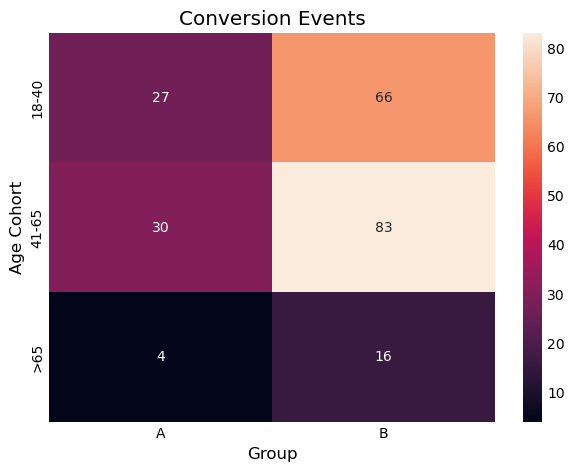

In [232]:
cont_table_converted = df.groupby(['Age Cohort','Group'])['Converted?'].sum().unstack()
sns.heatmap(cont_table_converted, annot=True)
plt.title("Conversion Events")
chi2_contingency(cont_table_converted)

Chi2ContingencyResult(statistic=np.float64(30.73205809970767), pvalue=np.float64(2.1213795349852667e-07), dof=2, expected_freq=array([[ 907.43667492,   11.56332508],
       [2584.07157591,   32.92842409],
       [1295.49174917,   16.50825083]]))


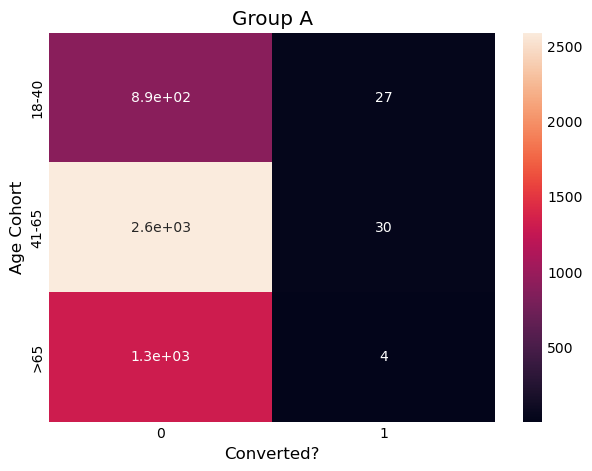

In [233]:
cont_tableA = df[df['Group']=='A'].groupby(['Age Cohort','Converted?']).size().unstack()
sns.heatmap(cont_tableA, annot=True)
plt.title("Group A")
print(chi2_contingency(cont_tableA))

Chi2ContingencyResult(statistic=np.float64(64.3475637389475), pvalue=np.float64(1.0643980546207755e-14), dof=2, expected_freq=array([[ 856.81126238,   30.18873762],
       [2530.82920792,   89.17079208],
       [1295.3595297 ,   45.6404703 ]]))

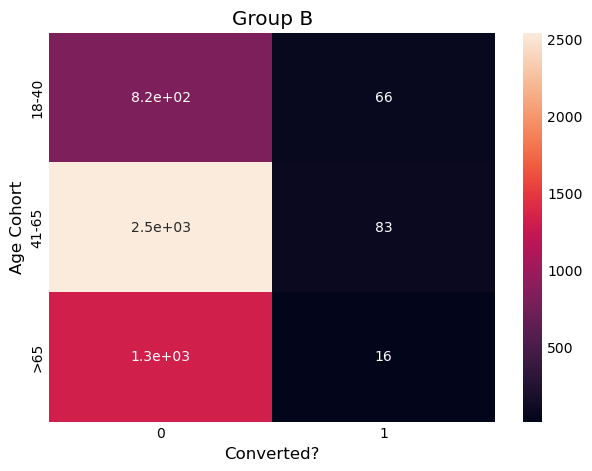

In [234]:
cont_tableB = df[df['Group']=='B'].groupby(['Age Cohort','Converted?']).size().unstack()
sns.heatmap(cont_tableB, annot=True)
plt.title("Group B")
chi2_contingency(cont_tableB)

In [235]:
cont_table_age = df.groupby(['Age Cohort','Group','Converted?']).size().unstack()
display(cont_table_age)

Converted?           0   1
Age Cohort Group          
18-40      A       892  27
           B       821  66
41-65      A      2587  30
           B      2537  83
>65        A      1308   4
           B      1325  16

Chi2ContingencyResult(statistic=np.float64(17.82595803097913), pvalue=np.float64(2.4205835027130876e-05), dof=1, expected_freq=array([[871.67607973,  47.32392027],
       [841.32392027,  45.67607973]]))

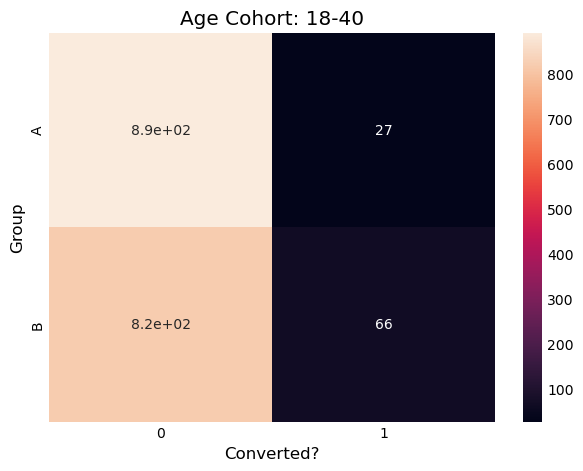

In [236]:
cohort = "18-40"

tab = cont_table_age.loc[cohort,:]
sns.heatmap(tab, annot=True)
plt.title("Age Cohort: "+cohort)

chi2_contingency(tab)

Chi2ContingencyResult(statistic=np.float64(24.39607223930859), pvalue=np.float64(7.84284329179358e-07), dof=1, expected_freq=array([[2560.53236586,   56.46763414],
       [2563.46763414,   56.53236586]]))

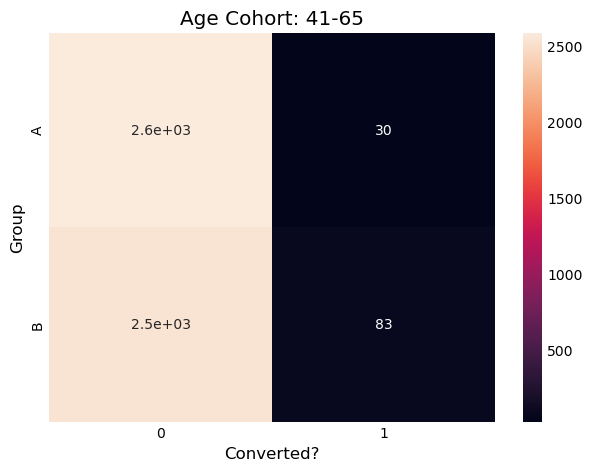

In [237]:
cohort = "41-65"

tab = cont_table_age.loc[cohort,:]
sns.heatmap(tab, annot=True)
plt.title("Age Cohort: "+cohort)

chi2_contingency(tab)

Chi2ContingencyResult(statistic=np.float64(5.856753735298961), pvalue=np.float64(0.015517388017369512), dof=1, expected_freq=array([[1302.10931021,    9.89068979],
       [1330.89068979,   10.10931021]]))

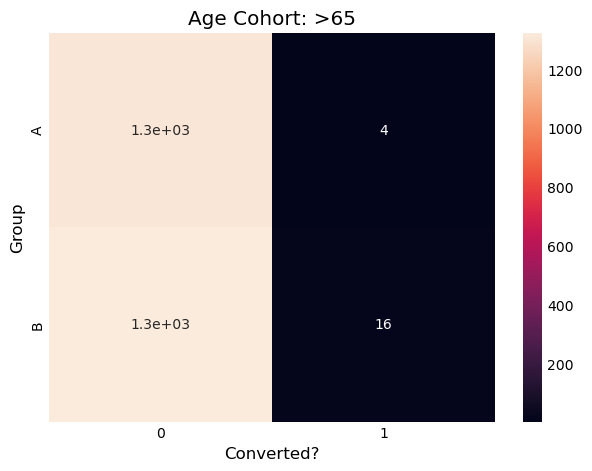

In [238]:
cohort = ">65"

tab = cont_table_age.loc[cohort,:]
sns.heatmap(tab, annot=True)
plt.title("Age Cohort: "+cohort)

chi2_contingency(tab)

<Axes: xlabel='Converted?', ylabel='Age Cohort'>

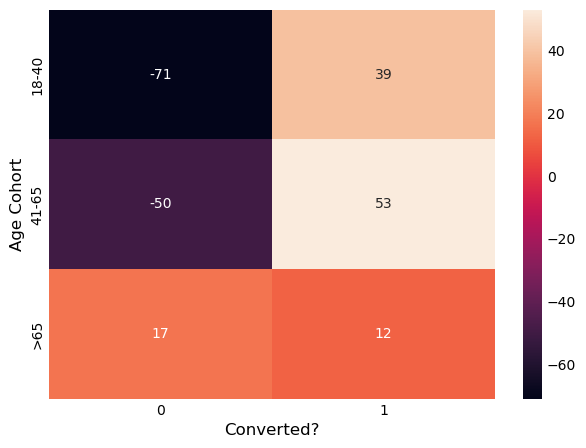

In [239]:
cont_tableATE = cont_tableB - cont_tableA

sns.heatmap(cont_tableATE, annot=True)
# chi2_contingency(cont_tableATE)

#### Cleanup

In [240]:
del aum_mean_std_cohorts, rev_mean_std_cohorts, age_preponderance1, age_preponderance2, age_preponderance3, conversion_rate, std_conversion, ate_aum, ate_rev, ate_roi, cont_table_converted, cont_tableA, cont_tableB, cont_table_age, cohort, tab, cont_tableATE

In [241]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

### HTE

#### Preparation

In [242]:
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.contingency_tables import Table2x2
from typing import Tuple

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.stats import kruskal

In [243]:
cont_table_gp = df.groupby(['Group','Age Cohort','Converted?']).size().unstack()
display(cont_table_gp)

Converted?           0   1
Group Age Cohort          
A     18-40        892  27
      41-65       2587  30
      >65         1308   4
B     18-40        821  66
      41-65       2537  83
      >65         1325  16

In [244]:
cont_table_A = cont_table_gp.loc["A",:]
cont_table_B = cont_table_gp.loc["B",:]

#### Per-Cohort Contingency Tests

Let us study heterogeneity in the "Conversions" binary variable.

In [249]:
def wilson_interval(c: int, n: int, alpha: float = 0.05) -> Tuple[float, float]:
    """
    Compute the Wilson score confidence interval for a binomial proportion.

    Parameters
    ----------
    c : int
        Number of successes.
    n : int
        Number of trials.
    alpha : float, optional
        Significance level for the confidence interval, by default 0.05.

    Returns
    -------
    Tuple[float, float]
        Lower and upper bounds of the confidence interval.
    """

    if n == 0:
        return 0.0, 1.0
    p = c / n
    z = 1.96  # for 95% CI
    den = 1 + (z*z) / n
    centre = p + (z*z) / (2*n)
    adj = z * np.sqrt(p*(1-p)/n + (z*z) / (4*n*n))
    lower = max(0.0, (centre - adj) / den)
    upper = min(1.0, (centre + adj) / den)
    return lower, upper

def newcombe_diff_CI(cB, nB, cA, nA, alpha=0.05):
    """
    Compute Newcombe’s Wilson-based confidence interval for a risk difference.

    Parameters
    ----------
    cB : int
        Number of successes in group B.
    nB : int
        Number of trials in group B.
    cA : int
        Number of successes in group A.
    nA : int
        Number of trials in group A.
    alpha : float, optional
        Significance level for the confidence interval, by default 0.05.

    Returns
    -------
    Tuple[float, Tuple[float, float]]
        Risk difference estimate and its confidence interval.
    """

    lbB, ubB = wilson_interval(cB, nB, alpha)
    lbA, ubA = wilson_interval(cA, nA, alpha)
    rd = (cB / nB if nB > 0 else 0.0) - (cA / nA if nA > 0 else 0.0)
    ci_low = lbB - ubA
    ci_high = ubB - lbA
    ci_low = max(-1.0, ci_low)
    ci_high = min(1.0, ci_high)
    return rd, (ci_low, ci_high)

In [250]:
def cohort_contingency_tests(cont_tabA: pd.DataFrame, cont_tabB: pd.DataFrame):
    """
    Perform contingency table tests across cohorts.

    Given two DataFrames indexed by cohort with columns [1, 0] (for conversion/non-conversion), compute sample sizes, conversion counts, proportions, risk differences with Newcombe CIs, odds ratios with confidence intervals, chi-square tests, Fisher’s exact tests, and expected counts.

    Parameters
    ----------
    cont_tabA : pd.DataFrame
        Contingency table for group A with columns [1, 0].
    cont_tabB : pd.DataFrame
        Contingency table for group B with columns [1, 0].

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by cohort with columns:
        ['nA', 'cA', 'pA', 'nB', 'cB', 'pB',
         'RD', 'RD_CI_low', 'RD_CI_high',
         'OR', 'OR_CI_low', 'OR_CI_high',
         'chi2_p', 'chi2_stat', 'chi2_dof',
         'fisher_p', 'expected_counts'].
    """

    rows = []
    cohorts = cont_tabA.index

    # column names
    conv = 1 # conversions
    not_conv = 0 # non-conversions
    
    for k in cohorts:
        cA = int(cont_tabA.loc[k, conv])
        ncA = int(cont_tabA.loc[k, not_conv])
        nA = cA + ncA
        cB = int(cont_tabB.loc[k, conv])
        ncB = int(cont_tabB.loc[k, not_conv])
        nB = cB + ncB
        # rates
        pA = cA / nA if nA > 0 else np.nan
        pB = cB / nB if nB > 0 else np.nan
        rd, (ci_low, ci_high) = newcombe_diff_CI(cB, nB, cA, nA)
        # contingency table
        table = np.array([[cB, ncB], [cA, ncA]])
        # Pearson chi2 (no Yates correction)
        try:
            chi2, p_chi, dof, expected = chi2_contingency(table, correction=False)
        except Exception:
            chi2, p_chi, dof, expected = np.nan, np.nan, np.nan, np.array([[np.nan]*2]*2)
        # Fisher exact
        try:
            or_stat, p_fish = fisher_exact(table, alternative='two-sided')
        except Exception:
            or_stat, p_fish = np.nan, np.nan
        # odds ratio and CI via statsmodels Table2x2 (if available)
        try:
            t = Table2x2(table)
            or_est = t.oddsratio
            or_ci = t.oddsratio_confint()
        except Exception:
            or_est, or_ci = or_stat, (np.nan, np.nan)
        rows.append({
            'cohort': k,
            'nA': nA, 'cA': cA, 'pA': pA,
            'nB': nB, 'cB': cB, 'pB': pB,
            'RD': rd, 'RD_CI_low': ci_low, 'RD_CI_high': ci_high,
            'OR': or_est, 'OR_CI_low': or_ci[0], 'OR_CI_high': or_ci[1],
            'chi2_p': p_chi, 'chi2_stat': chi2, 'chi2_dof': dof,
            'fisher_p': p_fish,
            'expected_counts': expected
        })
    return pd.DataFrame(rows).set_index('cohort')

In [251]:
cohort_contingency_tests(cont_table_A, cont_table_B)

,nA,cA,pA,nB,cB,pB,RD,RD_CI_low,RD_CI_high,OR,OR_CI_low,OR_CI_high,chi2_p,chi2_stat,chi2_dof,fisher_p,expected_counts
cohort,,,,,,,,,,,,,,,,,
18-40,919,27,0.029380,887,66,0.074408,0.045028,0.016503,0.073306,2.655840,1.680492,4.197274,1.500811e-05,18.736513,1,1.576153e-05,"[[45.67607973421927, 841.3239202657808], [47.3..."
41-65,2617,30,0.011464,2620,83,0.031679,0.020216,0.009311,0.031060,2.821193,1.851607,4.298499,4.794936e-07,25.344597,1,4.797084e-07,"[[56.53236585831583, 2563.4676341416844], [56...."
>65,1312,4,0.003049,1341,16,0.011931,0.008883,-0.000456,0.018108,3.948679,1.316620,11.842496,8.180181e-03,6.993597,1,1.160926e-02,"[[10.109310214851112, 1330.8906897851489], [9...."


##### Cleanup

In [252]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

#### ANOVA

We now focus on the continous variables $\Delta$ and ROI, and study heterogeneity with ANOVA.

In [253]:
def logify_continuous(df,
                      conv_col="Converted?",
                      continuous_cols={"Addtl Contribution [%]":"Delta",
                                       "ROI [$, nudge only]":"roi"}):
    """
    Take the natural log of specified continuous columns for converted observations.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing conversion and continuous columns.
    conv_col : str, default "Converted?"
        Name of the binary conversion column. Only rows where this column is 1 are processed.
    continuous_cols : dict, default {"Addtl Contribution [%]":"Delta", "ROI [$, nudge only]":"roi"}
        Dictionary mapping original column names to new column suffixes.

    Returns
    -------
    pandas.DataFrame
        Subset of the input dataframe containing only converted rows, with additional columns for the natural logarithm of the specified continuous variables.
    """

    df_pos = df[df[conv_col] == 1].copy()

    for k, v in continuous_cols.items():
        df_pos["ln"+v] = np.log(df_pos[k])
    
    return df_pos


def run_anova(df, formula, typ=2,
              logify=False,
              conv_col="Converted?",
              continuous_cols={"Addtl Contribution [%]":"Delta",
                               "ROI [$, nudge only]":"roi"},
              dict_cols={"Addtl Contribution [%]":"Delta",
                         "ROI [$, nudge only]":"roi",
                         "Group":"arm",
                         "Age Cohort":"age_cohort"}):
    """
    Run OLS regression and ANOVA table using statsmodels.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing variables referenced in the formula.
    formula : str
        Patsy-style formula, e.g., 'lnDelta ~ C(age_group) * C(arm)'.
    typ : int, default 2
        Type of ANOVA table (1, 2, or 3).
    logify : bool, default False
        If True, apply natural log transformation to specified continuous columns.
    conv_col : str, default "Converted?"
        Column used for filtering converted observations if logify is True.
    continuous_cols : dict
        Mapping of original column names to simplified names for log transformation.
    dict_cols : dict
        Mapping of original column names to simplified names for the ANOVA analysis.

    Returns
    -------
    tuple of (pandas.DataFrame, RegressionResults)
        - ANOVA table with columns: sum_sq, df, F, PR(>F), eta_sq, omega_sq
        - Fitted OLS model object
    """

    df = df.copy()
    if logify:
        df = logify_continuous(df,
                               conv_col=conv_col,
                               continuous_cols=continuous_cols)
    df.rename(columns=dict_cols, inplace=True)
    
    model = smf.ols(formula, data=df).fit()
    # produce Type-II or Type-III ANOVA as requested
    aov = anova_lm(model, typ=typ)
    # add eta-squared measures (effect size)
    ss_total = aov["sum_sq"].sum()
    aov["eta_sq"] = aov["sum_sq"] / ss_total
    aov["omega_sq"] = (aov["sum_sq"] - (aov["df"] * model.mse_resid)) / (ss_total + model.mse_resid)
    return aov, model


def run_welch_anova(df, group_col, value_col):
    """
    Run Welch's ANOVA (approximation for unequal variances) using a nonparametric approach.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing grouping and measurement columns.
    group_col : str
        Column name identifying groups.
    value_col : str
        Column name of the continuous measurement variable.

    Returns
    -------
    dict
        Dictionary containing:
        - 'kw_stat': Kruskal-Wallis H-statistic
        - 'pval': associated p-value
    """

    groups = [df.loc[df[group_col] == g, value_col].dropna().values for g in df[group_col].unique()]
    # Kruskal-Wallis as conservative nonparametric alternative
    kw_stat, p = kruskal(*groups)
    return {"kw_stat": kw_stat, "pval": p}

##### $\Delta$

In [254]:
# One-way: lnDelta ~ age_group
aov_age, mod_age = run_anova(df, "Delta ~ C(age_cohort)", typ=2)
print("ANOVA by age (Delta among converters):")
display(aov_age)
print("\n")

# One-way: lnDelta ~ (arm or treatment)
aov_arm, mod_arm = run_anova(df, "Delta ~ C(arm)", typ=2)
print("ANOVA by arm (Delta among converters):")
display(aov_arm)
print("\n")

# Two-way with interaction: Delta ~ (arm or treatment) * age_group
aov_full, mod_full = run_anova(df, "Delta ~ C(arm) * C(age_cohort)", typ=2)
print("Two-way ANOVA (arm, age, interaction) on Delta among converters:")
display(aov_full)

ANOVA by age (Delta among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(age_cohort),15.917202,2.0,37.784353,4.509201e-17,0.007736,0.00753
Residual,2041.657880,9693.0,NaN,NaN,0.992264,0.00000




ANOVA by arm (Delta among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),18.760546,1.0,89.201213,4.393104e-21,0.009118,9.014656e-03
Residual,2038.814537,9694.0,NaN,NaN,0.990882,1.104944e-16




Two-way ANOVA (arm, age, interaction) on Delta among converters:


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),19.093145,1.0,91.806512,1.191921e-21,0.009278,0.009176
C(age_cohort),16.249802,2.0,39.067363,1.262698e-17,0.007896,0.007693
C(arm):C(age_cohort),7.320163,2.0,17.598951,2.348122e-08,0.003557,0.003355
Residual,2015.244572,9690.0,NaN,NaN,0.979269,0.000000


In [255]:
# One-way: lnDelta ~ age_group
aov_age, mod_age = run_anova(df, "lnDelta ~ C(age_cohort)", typ=2, logify=True)
print("ANOVA by age (lnDelta among converters):")
display(aov_age)
print("\n")

# One-way: lnDelta ~ (arm or treatment)
aov_arm, mod_arm = run_anova(df, "lnDelta ~ C(arm)", typ=2, logify=True)
print("ANOVA by arm (lnDelta among converters):")
display(aov_arm)
print("\n")

# Two-way with interaction: lnDelta ~ (arm or treatment) * age_group
aov_full, mod_full = run_anova(df, "lnDelta ~ C(arm) * C(age_cohort)", typ=2, logify=True)
print("Two-way ANOVA (arm, age, interaction) on lnDelta among converters:")
display(aov_full)

ANOVA by age (lnDelta among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(age_cohort),0.095285,2.0,0.221559,0.801445,0.001983,-0.006937
Residual,47.952469,223.0,NaN,NaN,0.998017,0.000000




ANOVA by arm (lnDelta among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),20.989339,1.0,173.757847,9.423291e-30,0.436843,0.43324
Residual,27.058415,224.0,NaN,NaN,0.563157,0.00000




Two-way ANOVA (arm, age, interaction) on lnDelta among converters:


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),20.921877,1.0,171.179200,2.584523e-29,0.436051,0.432403
C(age_cohort),0.027823,2.0,0.113821,8.924705e-01,0.000580,-0.004503
C(arm):C(age_cohort),0.141736,2.0,0.579830,5.608472e-01,0.002954,-0.002135
Residual,26.888856,220.0,NaN,NaN,0.560415,0.000000


##### ROI

In [256]:
# One-way: roi ~ age_group
aov_age, mod_age = run_anova(df, "roi ~ C(age_cohort)", typ=2)
print("ANOVA by age (lnroi among converters):")
display(aov_age)
print("\n")

# One-way: roi ~ (arm or treatment)
aov_arm, mod_arm = run_anova(df, "roi ~ C(arm)", typ=2)
print("ANOVA by arm (lnroi among converters):")
display(aov_arm)
print("\n")

# Two-way with interaction: roi ~ (arm or treatment) * age_group
aov_full, mod_full = run_anova(df, "roi ~ C(arm) * C(age_cohort)", typ=2)
print("Two-way ANOVA (arm, age, interaction) on roi among converters:")
display(aov_full)

ANOVA by age (lnroi among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(age_cohort),1.518177e+03,2.0,2.224784,0.108146,0.000459,0.000253
Residual,3.307217e+06,9693.0,NaN,NaN,0.999541,0.000000




ANOVA by arm (lnroi among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),4.552674e+03,1.0,13.356894,0.000259,0.001376,0.001273
Residual,3.304183e+06,9694.0,NaN,NaN,0.998624,0.000000




Two-way ANOVA (arm, age, interaction) on roi among converters:


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),4.602264e+03,1.0,13.505826,0.000239,0.001391,0.001288
C(age_cohort),1.567767e+03,2.0,2.300389,0.100275,0.000474,0.000268
C(arm):C(age_cohort),6.372648e+02,2.0,0.935060,0.392598,0.000193,-0.000013
Residual,3.301978e+06,9690.0,NaN,NaN,0.997943,0.000000


In [257]:
# One-way: lnroi ~ age_group
aov_age, mod_age = run_anova(df, "lnroi ~ C(age_cohort)", typ=2, logify=True)
print("ANOVA by age (lnroi among converters):")
display(aov_age)
print("\n")

# One-way: lnroi ~ (arm or treatment)
aov_arm, mod_arm = run_anova(df, "lnroi ~ C(arm)", typ=2, logify=True)
print("ANOVA by arm (lnroi among converters):")
display(aov_arm)
print("\n")

# Two-way with interaction: lnroi ~ (arm or treatment) * age_group
aov_full, mod_full = run_anova(df, "lnroi ~ C(arm) * C(age_cohort)", typ=2, logify=True)
print("Two-way ANOVA (arm, age, interaction) on lnroi among converters:")
display(aov_full)

ANOVA by age (lnroi among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(age_cohort),12.204208,2.0,1.978704,0.140668,0.017437,0.008587
Residual,687.707262,223.0,NaN,NaN,0.982563,0.000000




ANOVA by arm (lnroi among converters):


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),17.377591,1.0,5.703132,0.017765,0.024828,0.020386
Residual,682.533879,224.0,NaN,NaN,0.975172,0.000000




Two-way ANOVA (arm, age, interaction) on lnroi among converters:


,sum_sq,df,F,PR(>F),eta_sq,omega_sq
C(arm),15.997875,1.0,5.274671,0.022579,0.022902,0.018480
C(age_cohort),10.824492,2.0,1.784475,0.170306,0.015496,0.006783
C(arm):C(age_cohort),4.457762,2.0,0.734886,0.480734,0.006382,-0.002292
Residual,667.251625,220.0,NaN,NaN,0.955220,0.000000


##### Cleanup

In [258]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

In [259]:
del aov_age, mod_age, aov_arm, mod_arm, aov_full, mod_full

#### Meta-learners & Uplift

Last bit of analysis: we train a meta-learner in order to compute uplift, the Qini curve, top@k, etc.

##### Importing Modules

In [260]:
# Utilities, cross-fitting, metrics for S-learner pipelines
import math
import random

from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import xgboost as xgb
from xgboost import XGBClassifier

from typing import List, Tuple, Dict, Any

##### Preliminary Data Preprocessing

Let us make our lives easier by paring down our dataset to the features we need:

In [261]:
simple_data = df.copy()
le = LabelEncoder()
le.fit(["A", "B"])

simple_data.rename(columns={"Group":"treatment",
                            "Age [yrs]":"age",
                            "Age Cohort":"age_cohort",
                            "Income [$100k]":"income",
                            "Income Cohort":"income_cohort",
                            "Net Worth [$100k]":"log10_net_worth_100k",
                            "Net Worth Cohort":"networth_cohort",
                            "Balance [$100k]":"log10_balance_100k",
                            "Current Contribution [%]":"current_pct",
                            "Employer Contribution Cap [%]":"employer_cap_pct",
                            "Last Login [Days]":"last_login",
                            "Hrs. Online/Day":"time_frac_online",
                            "Addtl Contribution [%]":"delta_pct",
                            "Addtl AUM from Client [$100k]":"delta_aum_client",
                            "Total Addtl AUM [$100k]":"delta_aum_total",
                            "Revenue [$]":"revenue",
                            "ROI [$, nudge only]":"roi",
                            "Converted?":"converted"},
                  inplace=True)

simple_data["log10_income_100k"] = simple_data["income"].map(np.log10)
simple_data["income"] *= 1.E5 # income in dlls

simple_data["delta_aum_client"] *= 1.E5
simple_data["delta_aum_total"] *= 1.E5

simple_data["log10_net_worth_100k"] = simple_data["log10_net_worth_100k"].map(np.log10)

simple_data["log10_balance_100k"] = simple_data["log10_balance_100k"].map(np.log10)

simple_data["terminally_online"] = simple_data["age"].map(inbox_time_fn)

simple_data["cont_above_match"] = (simple_data["current_pct"] > simple_data["employer_cap_pct"]).astype(int)
simple_data["cont_above_7pp"] = (simple_data["current_pct"] > 7).astype(int)

simple_data = simple_data[["user_id",
                           "age",
                           "age_cohort",
                           "log10_income_100k",
                           "log10_net_worth_100k",
                           "log10_balance_100k",
                           "current_pct",
                           "employer_cap_pct",
                           "cont_above_match",
                           "cont_above_7pp",
                           "last_login",
                           "terminally_online", # engineered feature
                           # keeping these for calculations, NOT for ML model
                           "income",
                           "delta_aum_client",
                           "delta_aum_total",
                           "revenue",
                           "roi",
                           # the meat:
                           "converted",
                           "treatment"]]

# encoding treatment
simple_data["treatment"] = le.transform(simple_data["treatment"])

In [262]:
simple_data.head()

,user_id,age,age_cohort,log10_income_100k,log10_net_worth_100k,log10_balance_100k,current_pct,employer_cap_pct,cont_above_match,cont_above_7pp,last_login,terminally_online,income,delta_aum_client,delta_aum_total,revenue,roi,converted,treatment
0,945750,53.376230,41-65,0.241568,0.756732,0.456058,12.75,7.50,1,1,22.9,0.198,1.744088e+05,0.0,0.0,0.0,-0.001,0,0
1,905513,68.462552,>65,1.641069,2.377018,1.657824,3.25,1.25,1,0,0.2,0.152,4.375918e+06,0.0,0.0,0.0,-0.001,0,0
2,142290,75.140631,>65,0.248551,1.702015,1.243757,4.00,6.75,0,0,2.2,0.132,1.772356e+05,0.0,0.0,0.0,-0.001,0,0
3,920046,76.822404,>65,-0.301231,0.280477,0.276678,12.00,9.75,1,1,60.8,0.127,4.997691e+04,0.0,0.0,0.0,-0.001,0,0
4,567441,50.698605,41-65,1.143680,2.201540,1.008727,10.00,6.00,1,1,107.5,0.206,1.392129e+06,0.0,0.0,0.0,-0.001,0,0


##### Defining Functions

###### Transformers and Preprocessors:

In [275]:
# ---------------------------
# Helpers & transformers
# ---------------------------

class TreatmentInteractionTransformer:
    """
    Create interaction features between a binary 'treatment' column and a set of preprocessed features.
    Given numeric matrix X and a treatment vector t, returns X augmented with X*t (elementwise multiplication),
    optionally with a prefix for column names.
    This transformer assumes the base features are numeric (after encoding).
    """
    def __init__(self, feature_names: List[str] = None, prefix: str = "int_"):
        self.feature_names = feature_names
        self.prefix = prefix

    def fit(self, X, y=None):
        return self

    def transform(self, X, treatment: np.ndarray = None):
        """
        X: numpy array shape (n_samples, n_features)
        treatment: array-like shape (n_samples,) of 0/1
        Returns augmented array with X and X * treatment[:,None]
        """
        X = np.asarray(X)
        if treatment is None:
            raise ValueError("treatment array required")
        t = np.asarray(treatment).reshape(-1, 1)
        Xt = X * t  # broadcast
        return np.hstack([X, Xt])

    def get_feature_names(self, base_names):
        # return base + prefixed names for interactions
        return base_names + [self.prefix + n for n in base_names]

In [276]:
def build_preprocessor(categorical: List[str], numeric: List[str]):
    """
    Build a scikit-learn ColumnTransformer for preprocessing.

    Numeric columns are imputed (median) and standardized (StandardScaler).
    Categorical columns are imputed (constant 'missing') and one-hot encoded (dropping first level).

    Parameters
    ----------
    categorical : list of str
        Names of categorical columns.
    numeric : list of str
        Names of numeric columns.

    Returns
    -------
    sklearn.compose.ColumnTransformer
        Preprocessing pipeline combining numeric and categorical transformations.
    """
    
    num_pipe = Pipeline([('scale', StandardScaler())])

    if categorical is not None:
        cat_pipe = Pipeline([('ohe',
                              OneHotEncoder(handle_unknown='ignore',
                                            sparse_output=False,
                                            drop='first'))])
        
        preproc = ColumnTransformer([('num', num_pipe, numeric),
                                     ('cat', cat_pipe, categorical)])

    else:
        preproc = ColumnTransformer([('num', num_pipe, numeric)])
    
    return preproc

###### Estimators

Logistic:

In [277]:
def build_logistic_estimator(penalty=None, C=1.0, max_iter=1_000, class_weight=None, random_state=0, **kwargs):
    """
    Build a logistic regression estimator for binary classification.

    Wraps sklearn's LogisticRegression, configured for preprocessed numeric and 
    categorical features with an appended treatment column. Supports class weighting 
    for imbalanced outcomes and reproducible training.

    Parameters
    ----------
    penalty (str or None, optional):
        Regularization type ('l1', 'l2', 'elasticnet', or None). Defaults to None.
    C (float, optional):
        Inverse of regularization strength. Defaults to 1.0.
    max_iter (int, optional):
        Maximum number of iterations for solver. Defaults to 1000.
    class_weight (dict or 'balanced', optional):
        Weights to adjust for class imbalance. Defaults to None.
    random_state (int, optional):
        Seed for reproducibility. Defaults to 0.
    **kwargs:
        Additional arguments passed to sklearn.linear_model.LogisticRegression.

    Returns:
        LogisticRegression: Configured sklearn logistic regression estimator.
    """


    # use saga or lbfgs; for small data liblinear ok
    est = LogisticRegression(fit_intercept=True,
                             solver='lbfgs',
                             penalty=penalty,
                             C=C,
                             class_weight=class_weight,
                             max_iter=max_iter,
                             random_state=random_state,
                             **kwargs)
    
    return est

# Example of wiring:
# numeric_cols = ['balance','current_pct','income', ...]
# categorical_cols = ['age_group','income_bucket']
# features = numeric_cols + categorical_cols  # DO NOT include 'treatment' here; we'll append treatment during cross_fit.
# preproc = build_preprocessor(categorical=categorical_cols, numeric=numeric_cols)
# est = build_logistic_estimator()
# df_with_preds = cross_fit_uplift(df, features, 'treatment', 'converted', est, preproc, k=5)
# qdf = qini_dataframe(df_with_preds)
# qini_coef = qini_coefficient(qdf)
# topk = topk_metrics(df_with_preds)

XGBoostClassifier

In [278]:
def build_xgb_estimator(max_depth=6, n_estimators=200, learning_rate=0.05, random_state=0, scale_pos_weight=None):
    """
    Build an XGBoost classifier for S-learner uplift modeling.

    The caller should provide preprocessed feature matrices (numeric + categorical handled). Returns an sklearn-compatible XGBClassifier ready for fitting.

    Parameters
    ----------
    max_depth : int, default=6
        Maximum depth of each tree.
    n_estimators : int, default=200
        Number of boosting rounds (trees).
    learning_rate : float, default=0.05
        Step size shrinkage for each boosting step.
    random_state : int, default=0
        Seed for reproducibility.
    scale_pos_weight : float, optional
        Control the balance of positive and negative classes (for imbalanced data).

    Returns
    -------
    xgboost.XGBClassifier
        Configured classifier suitable for meta-learner uplift estimation.
    """

    est = XGBClassifier(max_depth=max_depth,
                        n_estimators=n_estimators,
                        learning_rate=learning_rate,
                        eval_metric='logloss',
                        random_state=random_state)
    
    if scale_pos_weight is not None:
        est.set_params(scale_pos_weight=scale_pos_weight)
    return est

# Then:
# preproc = build_preprocessor(...)  # same as before
# est_builder = lambda: build_xgb_estimator(n_estimators=300)
# df_preds_xgb = cross_fit_uplift(df, features, 'treatment', 'converted', est_builder(), preproc, k=5)
# qdf_xgb = qini_dataframe(df_preds_xgb)
# topk_xgb = topk_metrics(df_preds_xgb, ...)

###### Uplift estimation
(via cross-fitting of meta-learners)

Let $i \in \{1, ..., N \}$ index the records/clients/users, $\mathbf{X}$ their features (which we use to train our meta-learners), $T \in \{ 0, 1 \}$ the treatment indicator, and $Y \in \{ 0, 1 \}$ the target. We use lowercase letters to denote the _values_ of these variables. For example, $\mathbf{x}$, $t$, and $y$ denote the values of $\mathbf{X}$, $T$, and $Y$ for an arbitrary record; $\mathbf{x}_i$, $t_i$, and $y_i$ are specific to the $i$-th record. From now on we un-bold $\mathbf{X}$ and $\mathbf{x}$; it is understood that it can be a vector in feature space.

**(Probabilistic) Uplift:** the change in an individual's conversion probability (or its propensity for conversion) due to treatment, compared to control.

We have coded the following meta-learners.

**S-learner:**

So called because it uses a **s**ingle estimator, which we denote by $f$. It takes both $\mathbf{X}$ _and_ $T$ as features, to predict:

$$\mathrm{Pr}(Y = 1 \vert X = x, T = t) \approx \hat{f}(x, t)$$

The **lift** is then estimated as:

$$\hat{\tau}_S(x) \equiv \hat{f}(x, 1) - \hat{f}(x, 0) \ .$$


**T-learner:**

So called because it used **t**wo estimators, $f_0$ and $f_1$, one for the control and one for the treated records. Obviously, $f_{1,0}$ does _not_ take $T$ as a feature in this case. Indeed:

$$\mathrm{Pr}(Y = 1 \vert X = x, T = 0) \approx \hat{f}_{0}(x)$$
$$\mathrm{Pr}(Y = 1 \vert X = x, T = 1) \approx \hat{f}_{1}(x)$$

The **lift** is then estimated as:

$$\hat{\tau}_T(x) \equiv \hat{f}_1(x) - \hat{f}_0(x) \ .$$

In [279]:
# ----------------------------------
# Uplift estimation (cross-fitting)
# ----------------------------------
def cross_fit_uplift(df: pd.DataFrame,
                     features: List[str],
                     treatment_col: str,
                     outcome_col: str,
                     estimator,
                     preprocessor: ColumnTransformer,
                     metalearner: str = 'S',
                     k: int = 5,
                     random_state: int = 0) -> pd.DataFrame:
    """
    Estimate individual treatment effects (uplift) using cross-fitted meta-learners.

    This function implements S-learner and T-learner uplift modeling strategies
    with cross-fitting to obtain out-of-sample counterfactual predictions.
    For each individual, it estimates potential outcomes under treatment (T=1)
    and control (T=0), then computes the conditional average treatment effect (CATE).

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing covariates, treatment assignments, and outcomes.
    features : list of str
        Names of feature columns to use as predictors (excluding treatment).
    treatment_col : str
        Column name of the binary treatment indicator (0 = control, 1 = treated).
    outcome_col : str
        Column name of the binary outcome (0/1).
    estimator : sklearn-like estimator
        Base estimator implementing ``fit(X, y)`` and either
        ``predict_proba(X)`` (preferred) or ``decision_function(X)``.
    preprocessor : sklearn.compose.ColumnTransformer
        Preprocessing pipeline to transform feature matrix before model fitting.
    metalearner : {'S', 'T'}, default='S'
        Meta-learner strategy:
        - 'S': S-learner (single model with treatment as a feature).
        - 'T': T-learner (separate models for treatment and control groups).
    k : int, default=5
        Number of folds for cross-fitting. Each fold is used for out-of-sample prediction.
    random_state : int, default=0
        Random seed controlling the K-fold splitting.

    
    Returns
    -------
    tuple
        A tuple containing:

        - pandas.DataFrame
            Copy of the input DataFrame with additional columns:
            - ``p0_oos`` : out-of-sample predicted probability of outcome under control.
            - ``p1_oos`` : out-of-sample predicted probability of outcome under treatment.
            - ``tau_hat_oos`` : estimated treatment effect (``p1_oos - p0_oos``).

        - estimator or list of estimators
            The fitted estimator(s) from the last fold:
            - S-learner: single fitted estimator.
            - T-learner: list of two fitted estimators, ``[control_model, treatment_model]``.


    Notes
    -----
    * Cross-fitting reduces bias by ensuring counterfactual predictions
      are generated from models not trained on the same individuals.
    * The S-learner appends the treatment indicator as a feature
      and fits one model for all data.
    * The T-learner fits two separate models, one on controls and one
      on treated units, and subtracts their predictions.
    * For the T-learner, the preprocessor is fit once on the pooled training data for each fold.
    * This implementation assumes binary treatments and binary outcomes.

    Examples
    --------
    >>> df_out = cross_fit_uplift(
    ...     df=data,
    ...     features=['age', 'income'],
    ...     treatment_col='treatment',
    ...     outcome_col='converted',
    ...     estimator=LogisticRegression(),
    ...     preprocessor=ColumnTransformer([...]),
    ...     metalearner='T',
    ...     k=5
    ... )
    >>> df_out[['p0_oos', 'p1_oos', 'tau_hat_oos']].head()
    """

    # Define the meta-learner in use
    metalearner = metalearner.lower()
    try:
        assert metalearner in ['s', 't']
    except AssertionError:
        print(f"metalearner={metalearner}. Currently, we only handle ['S', 'T'].")

    # Define useful quantities and arrays
    df = df.copy().reset_index(drop=True)

    n = len(df)
    p0_oos = np.zeros(n)
    p1_oos = np.zeros(n)

    # K-Fold splitter
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)

    if metalearner == 's':
        ksplitter = kf.split(df)

    else:
        df0 = df[df[treatment_col] == 0].copy()
        df0.reset_index(inplace=True, drop=False) # keeping the old index for future use

        df1 = df[df[treatment_col] == 1].copy()
        df1.reset_index(inplace=True, drop=False) # keeping the old index for future use
        ksplitter = kf.split(df0) # has same index range as if I had used df1


    # Cross-fitting routine:
    fold_idx = 0
    for train_idx, valid_idx in ksplitter:

        fold_idx += 1

        if metalearner == 's':

            # Split dataset into training and validation sets
            train_df = df.iloc[train_idx]
            valid_df = df.iloc[valid_idx]

            # Preprocess train features and fit estimator
            X_train_raw = train_df[features]
            X_valid_raw = valid_df[features]

            # The preprocessor returns numpy arrays; we will use treatment column separately for interactions if needed
            X_train = preprocessor.fit_transform(X_train_raw)
            X_valid = preprocessor.transform(X_valid_raw)

            # Build two training matrices for treatment = 0 and treatment = 1 by setting treatment column.
            # We will supply treatment as a column in X if estimator expects it.
            # Here we assume features do NOT include treatment; so we will append treatment later.

            # Prepare design matrices: append treatment column for model training as it's part of 'features' used by estimator.
            t_train = train_df[treatment_col].values.reshape(-1, 1)
            t_valid = valid_df[treatment_col].values.reshape(-1, 1)

            # Xgb/scikit models expect 2D X. We'll create X_train_with_treatment = [X_train, t_train]
            X_train_with_t = np.hstack([X_train, t_train])

            # Construct validation matrices without and with treatment
            X_valid_with_t0 = np.hstack([X_valid, np.zeros((X_valid.shape[0], 1))])  # T=0
            X_valid_with_t1 = np.hstack([X_valid, np.ones((X_valid.shape[0], 1))])   # T=1

            # Fit estimator on training data (treatment in training design)
            y_train = train_df[outcome_col].values
            est = clone(estimator)
            est.fit(X_train_with_t, y_train)

            # Predict probabilities for validation sets when T=0 and T=1
            
            # Prefer predict_proba; fallback to decision_function+sigmoid if needed
            if hasattr(est, "predict_proba"):
                p0 = est.predict_proba(X_valid_with_t0)[:, 1]
                p1 = est.predict_proba(X_valid_with_t1)[:, 1]
            else:
                # Fallback: use decision_function + sigmoid
                def sigmoid(z): return 1/(1+np.exp(-z))
                p0 = sigmoid(est.decision_function(X_valid_with_t0))
                p1 = sigmoid(est.decision_function(X_valid_with_t1))

        else:

            # Split dataset into training and validation sets
            # Control & treatment training datasets:
            train_df0 = df0.iloc[train_idx]
            train_df1 = df1.iloc[train_idx]
            
            # Validation dataset (one for both!)
            valid_idx = pd.concat([df0.loc[valid_idx,'index'],
                                   df1.loc[valid_idx,'index']],
                                  ignore_index=True).values
            valid_df = df.iloc[valid_idx]

            # Preprocess train features and fit estimator
            X_train_raw0 = train_df0[features]
            X_train_raw1 = train_df1[features]
            X_valid_raw = valid_df[features]

            # The preprocessor returns numpy arrays; we will use treatment column separately for interactions if needed
            # Fit preprocessor on pooled training data (both arms together), for this fold
            preprocessor.fit(pd.concat([X_train_raw0, X_train_raw1], axis=0))
            # Transform separately for each group, for this fold
            X_train0 = preprocessor.transform(X_train_raw0)
            X_train1 = preprocessor.transform(X_train_raw1)
            X_valid = preprocessor.transform(X_valid_raw)

            # For T-learner we do not nead a treatment column, since each arm/group gets its own estimator.

            # Define estimators
            est = [clone(estimator), clone(estimator)]

            # Fit estimators on training data:
            # Control:
            y_train0 = train_df0[outcome_col].values
            est[0].fit(X_train0, y_train0)
            # Treatment:
            y_train1 = train_df1[outcome_col].values
            est[1].fit(X_train1, y_train1)

            # Predict probabilities for validation sets when T=0 and T=1
            
            # Prefer predict_proba; fallback to decision_function+sigmoid if needed
            if hasattr(est[0], "predict_proba"):
                # Predictions for control:
                p0 = est[0].predict_proba(X_valid)[:, 1]
                # Predictions for treatment:
                p1 = est[1].predict_proba(X_valid)[:, 1]
            else:
                # Fallback: use decision_function + sigmoid
                def sigmoid(z): return 1/(1+np.exp(-z))
                # Predictions for control:
                p0 = sigmoid(est[0].decision_function(X_valid))
                # Predictions for treatment:
                p1 = sigmoid(est[1].decision_function(X_valid))

        # Store predictions
        p0_oos[valid_idx] = p0
        p1_oos[valid_idx] = p1

    # Save predictions
    df['p0_oos'] = p0_oos
    df['p1_oos'] = p1_oos

    # Compute uplift
    df['tau_hat_oos'] = df['p1_oos'] - df['p0_oos']
    
    # Return the updated dataframe and the estimators
    return df, est

###### Qini curve
(and associated metrics)

**Qini** quantifies the _"uplift cumulative gain"_. In other words, the **Qini curve** plots cumulative incremental conversion vs. fraction of population targeted when records/units are ranked by predicted uplift.

Let us talk about the Qini curve and related concepts in more detail.

If one takes our meta-learner's predictions for the uplift $\hat{\tau}(x)$ of the population and ranks them from highest to lowest, one obtains a ranking of those individuals whose propensity for conversion is most significantly enhanced by treatment (which is what **uplift** means). Idealy, we would take the **top-k** fraction of this ranking (those top k% people more "susceptible" to convert under treatment) and _actually treat_ them for conversion. We say that we have _"deployed the uplift"_. The number **k** is determined by some optimization procedure (_e.g._ return on investment: at some point before k=100% one would be spending a lot of money to treat people for whom treatment makes little difference).

It is of high importance to know how many more conversions do we get thanks to treatment in this top-k. This number is the **expected (count) uplift of the top-k records**:

$$U_k \equiv n_k \cdot \mathbb{E}[Y(1) - Y(0) \vert \text{top-k}] \ ,$$

where $n_k \equiv \vert S_k \vert$ is the cardinality of the set $S_k$ of those top-k selected individuals (note that $n_k = \lfloor k N \rfloor$, _i.e._, the number of individuals in that top k%).

[N.B. unlike the uplift $\hat{\tau}(x)$ defined above, which is the increased in _conversion probability_ for _each individual_, $U_k$ here is the increased in actual conversions (_i.e._, counts, and as such, an integer) from _all_ the top-k fraction of individuals most susceptible to convert when treated.]

This can be rewritten as

$$U_k = \sum\limits_{i \in S_k} (Y_i(T=1) - Y_i(T=0)) = \sum\limits_{i_{\rm rank} = 1}^{i_{\rm rank}=n_k} (Y_{i_{\rm rank}}(T=1) - Y_{i_{\rm rank}}(T=0)) \ ,$$

where in the last equality we are indexing the records according to their uplift rank.

But we **cannot** know this number in principle, because it requires us to know counterfactuals. Indeed, for each record $i$ of our experimental sample, the individual was either treated or not, and it either converted or not. We cannot what he would have done if he had been instead untreated (or treated). And we don't have access to a whole Universe of trials, where his conversion or non-conversion could be played out again and again.

Because of this we can, at most, compute an unbiased estimator $\hat{U}_k$ of the uplift $U_k$, by considering only the treated elements:

$$\hat{U}_k \equiv \sum\limits_{i \in S_k} T_i (Y_i - \hat{p}_0) \ ,$$

where $\hat{p}_0 = \hat{p}_A$ is the (estimated) conversion rate in the control group A. $\hat{U}_k$ thus computes how many conversions occurred in those individuals among the top-k that were treated, and compares it to our estimate of the counterfactual: what we would have expected (for that same number of individuals) had we _not_ treated them.

Of course, this means that $\hat{U}_k$ is _scaled down_ with respect to the true $U_k$ by a factor of $n_{k,1} / n_k$, where $n_{k,1} = \sum\limits_{i \in S_k} T_i$ is the number of treated individuals in the top-k. It should be roughly $n_{k,1} \approx 0.5 \, n_k$ for a 50-50 RTC. So an alternative to $\hat{U}_k$ above is

$$\tilde{U}_k \equiv \frac{n_k}{n_{k,1}} \, \hat{U}_k \ .$$

A disadvantage of $\tilde{U}_k$ is that the variance may be much larger.

Finally, another estimator we could use is the **model-implied expected uplift**, where we _estimate_ the number of conversion among the top-k with the help of our meta-learners. Thus:

$$\hat{U}_k^{(\tau)} \equiv \sum\limits_{i \in S_k} \hat{\tau}_i = \mathbb{E}[U_k \vert \text{model}] \ ,$$

where $\hat{\tau}_i \equiv \hat{\tau}(x_i)$ is the (probabilistic) uplift estimated from our metalearners, _i.e._ the score of our ranking system. It is _not_ a causal estimator, unless the meta-learner model is correct. Thus, it should be treated more as a forecast.

So much for Qini and the uplift.

Another important quantity is the **Qini coefficient**, which is a scalar summary equal to the area between the Qini curve curve and the random baseline (sometimes normalized by the area of a perfect model). Because of this it is also called the AUUC (Area Under the Uplift Curve) in some places. It measures how much better the targeting is compared with random targeting.

In [280]:
# ---------------------------
# Qini
# ---------------------------

def qdf_random_baseline(df,
                        treatment_col='treatment',
                        outcome_col='converted',
                        n_iters=100):
    """
    Compute a random baseline for Qini or cumulative incremental conversions by averaging over multiple random permutations.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing at least the columns:
        - 'treatment': binary indicator (0/1) of treatment assignment.
        - 'converted': binary outcome (0/1) of conversion.
    n_iters : int, default=100
        Number of random shuffles to average over.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - 'frac': fraction of population sorted by random order (1/N, 2/N, ..., 1.0)
        - 'random_incremental_cum': average cumulative incremental conversions under random treatment assignment.
    """

    n = len(df)
    random_cum_list = []

    for _ in range(n_iters):
        shuffled = df.sample(frac=1.0, replace=False).reset_index(drop=True)
        treated_cum = shuffled[treatment_col].cumsum()
        treated_convs_cum = (shuffled[outcome_col] * shuffled[treatment_col]).cumsum()
        control_cum = (1 - shuffled[treatment_col]).cumsum()
        control_convs_cum = (shuffled[outcome_col] * (1 - shuffled[treatment_col])).cumsum()
        incremental_cum = treated_convs_cum / np.maximum(treated_cum, 1) - control_convs_cum / np.maximum(control_cum, 1)
        random_cum_list.append(incremental_cum.values)

    avg_random_cum = np.mean(random_cum_list, axis=0)
    qdf_rand = pd.DataFrame({'frac': np.arange(1, n+1)/n, 'random_incremental_cum': avg_random_cum})
    return qdf_rand



def qini_dataframe(df: pd.DataFrame,
                   score_col: str = 'tau_hat_oos',
                   treatment_col: str = 'treatment',
                   outcome_col: str = 'converted') -> pd.DataFrame:
    """
    Construct the Qini table for uplift modeling evaluation.

    The dataset is sorted by the predicted uplift score (descending).
    For each prefix (top-k records), cumulative statistics are computed
    to enable plotting of the Qini (uplift) curve and comparison between
    empirical and model-implied uplift.

    Parameters
    ----------
    df : pandas.DataFrame
        Input data containing treatment assignments, outcomes, and uplift scores.
    score_col : str, default 'tau_hat_oos'
        Column with predicted uplift scores used to rank observations.
        Should ideally be obtained out-of-sample (e.g., via cross-fitting).
    treatment_col : str, default 'treatment'
        Column with binary treatment indicator (0 = control, 1 = treated).
    outcome_col : str, default 'converted'
        Column with binary outcome (0/1).

    Returns
    -------
    pandas.DataFrame
        Table with one row per rank position, containing:

        - ``rank`` (int)
            Position in the sorted uplift score (1 = top-scored record).
        - ``frac`` (float)
            Population fraction covered by the prefix (``rank / N``).
        - ``tau_score`` (float)
            Predicted uplift score for the current record.
        - ``treated_cum`` (int)
            Cumulative number of treated units in the prefix.
        - ``treated_convs_cum`` (int)
            Cumulative number of observed conversions among the treated.
        - ``expected_cum`` (float)
            Expected conversions under random targeting:
            ``treated_cum * control_rate``, where ``control_rate`` is the
            overall control-arm conversion rate in the dataset.
        - ``qini_incremental_cum`` (float)
            Empirical incremental conversions in the prefix:
            ``treated_convs_cum - expected_cum``.
        - ``qini_rescaled`` (float)
            Rescaled incremental conversions:
            ``(rank / treated_cum) * qini_incremental_cum``.
            This extrapolates the observed incremental effect among treated
            to the counterfactual where *all* top-``rank`` units had been treated.
            Undefined when ``treated_cum == 0`` and high-variance when
            ``treated_cum`` is small.
        - ``qini_model`` (float)
            Model-implied uplift: cumulative sum of predicted uplift scores
            over the prefix (``score_col.cumsum()``). Represents the model's
            own forecast of incremental conversions under full treatment.

    Notes
    -----
    * ``qini_incremental_cum`` is the raw empirical uplift curve based on
      the control-arm baseline.
    * ``qini_rescaled`` provides an unbiased but noisy estimate of total
      incremental conversions if everyone in the prefix were treated.
    * ``qini_model`` is a deterministic “forecast curve” implied by the
      model's predicted scores.
    * In practice, the three curves may diverge: the difference between
      ``qini_rescaled`` and ``qini_model`` reflects estimation noise
      and model misspecification.

    Examples
    --------
    >>> qdf = qini_dataframe(df,
    ...                      score_col='tau_hat_oos',
    ...                      treatment_col='t',
    ...                      outcome_col='y')
    >>> qdf[['rank','frac','qini_incremental_cum','qini_model']].head()
    """

    df_sorted = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    
    N = len(df_sorted)
    rank = np.arange(1, N+1)

    control_rate = df_sorted[df_sorted[treatment_col]==0][outcome_col].mean()

    treat_prop = df_sorted[treatment_col].mean()
    
    treated_cum = np.zeros(N, dtype=int)
    treated_convs_cum = np.zeros(N, dtype=int)
    
    cum_t = 0
    cum_tconv = 0

    for i, row in df_sorted.iterrows():
        if row[treatment_col] == 1:
            cum_t += 1
            cum_tconv += int(row[outcome_col])
        treated_cum[i] = cum_t
        treated_convs_cum[i] = cum_tconv
    
    expected_cum = treated_cum * control_rate

    incremental = treated_convs_cum - expected_cum

    # rescale_factor = np.where(treated_cum > 0, rank/treated_cum, 1/treat_prop)
    rescale_factor = np.empty_like(rank, dtype=float)
    np.divide(rank, treated_cum, out=rescale_factor, where=(treated_cum > 0))
    rescale_factor[treated_cum == 0] = 1 / treat_prop
    
    rescaled = rescale_factor*incremental

    model = df_sorted[score_col].cumsum().to_numpy()

    out = pd.DataFrame({
        'rank': rank,
        'frac': rank/N,
        score_col: df_sorted[score_col],
        'treated_cum': treated_cum,
        'treated_convs_cum': treated_convs_cum,
        'expected_cum': expected_cum,
        'qini_incremental_cum': incremental,
        'qini_rescaled': rescaled,
        'qini_model': model
    })

    return out



def qini_coefficient(qdf: pd.DataFrame) -> float:
    """
    Compute Qini coefficient (assuming baseline of 0).

    Parameters
    ----------
    qdf : pandas.DataFrame
        Qini table as produced by `qini_dataframe`.

    Returns
    -------
    float
        Qini coefficient (sum of incremental cumulative conversions).
    """

    return qdf['qini_incremental_cum'].sum()

###### Top@k

Let us now focus on the Top@k (a.k.a. Top-k) metrics: important quantities dispplayed by the top-k uplift individuals (those for which treatment leads to the largest conversion rate uplift).

[N.B. While we could compute many of these quantities from the Qini table, since the Qini table above does not have all the columns we are interested in, it's better if we just repeat some of the Qini analysis on the data from scratch, and modify it for our purposes]

Essentially, having ranked all individuals in the experimental set according to their uplift score, we can compute the:

- **"observed"** _uplift_ (_among treated individuals in top-k_) in quantity X (_i.e._, what X looks like among those treated individuals in the top-k, minus what we _would_ have expected if these individuals had NOT been treated). Because this involves a counterfactual (which is unobservable), we use scare quotes around "observed".
- **rescaled** _uplift_ in quantity X _if we treated the entire top-k fraction_. This is simply the "observed" uplift, rescaled by $n_k/n_{k,1}$.
- **predicted** _uplift_ in quantity X for the entire top-k fraction, _according to the meta-learners_.

We compute these uplifts for the following quantities:

- **conversions**
- **Additional AUM due to Client's conversion** (does not include employer's matching)
- **Corresponding additional Revenue due to Client's conversion** (does not include employer's matching)

In [281]:
# ---------------------------
# top@k, incremental AUM and Revenue
# ---------------------------


def topk_metrics(df: pd.DataFrame,
                 score_col: str = 'tau_hat_oos',
                 k_list: List[float]=[0.01, 0.05, 0.1, 0.15],
                 treatment_col: str = 'treatment',
                 outcome_col: str = 'converted',
                 treat_control_conv_col: List[str]=['p0_oos', 'p1_oos'],
                 aum_client_col: str = 'delta_aum_client',
                 management_fees: float = typical_management_fees) -> pd.DataFrame:
    """
    Compute top-k uplift and business-value metrics for targeting evaluation.

    This function ranks observations by a supplied uplift score (descending)
    and computes predicted and observed incremental metrics for multiple
    top-k selection levels. Predicted metrics are computed from the model
    scores (interpreted as estimated incremental conversion probabilities
    or conversion probabilities under treatment/control); observed metrics
    are estimated from the randomized experiment using treated units and a
    control baseline. Rescaled observed metrics extrapolate the observed
    treated-subsample effect to the full top-k (unbiased but high-variance).

    Parameters
    ----------
    df : pandas.DataFrame
        Input data. Required columns depend on other arguments (see below).
    score_col : str, default 'tau_hat_oos'
        Column containing the score used for ranking (model-implied uplift).
        Must be out-of-sample / cross-fitted to avoid optimistic bias.
        Interpreted as additive expected conversions (probability uplift)
        when summing over a set.
    k_list : list of float, default [0.01, 0.05, 0.1, 0.15]
        Fractions of the population to evaluate (e.g., 0.05 for top 5%).
    treatment_col : str, default 'treatment'
        Column with binary treatment indicator (0 = control, 1 = treated).
    outcome_col : str, default 'converted'
        Column with binary outcome (0/1).
    treat_control_conv_col : list or tuple of str, default ['p0_oos','p1_oos']
        Pair of column names giving model-predicted conversion probabilities
        under control and treatment, respectively. These are used when
        computing model-based expected AUM/revenue contributions.
    aum_client_col : str, default 'delta_aum_client'
        Column containing the per-client change in AUM attributable to an
        observed contribution (zero for non-converters). If non-zero for
        non-converters, ensure the interpretation is consistent across arms.
    management_fees : float
        Management-fee rate applied to incremental AUM to compute revenue.

    Returns
    -------
    pandas.DataFrame
        One row per k with the following columns (types shown in parentheses):

        - ``k`` (float): fraction of population evaluated.
        - ``n_selected`` (int): number of records in top-k.
        - ``treated_in_top`` (int): number of actually treated records in top-k.
        - ``expected_random_in_top`` (float): expected treated conversions in top-k
          under random targeting (= treated_in_top * control_rate).
        - ``pred_inc_conv`` (float): model-predicted incremental conversions
          for the top-k (sum of ``score_col`` over the top-k).
        - ``obs_inc_conv`` (float): observed incremental conversions among treated
          in the top-k (treated_conversions - expected_random_in_top).
        - ``rescaled_obs_inc_conv`` (float): rescaled estimator of total uplift
          for top-k: ``(n_selected / treated_in_top) * obs_inc_conv``.
          Undefined or set to NaN if ``treated_in_top == 0``.
        - ``pred_inc_aum_client`` (float): model-predicted incremental AUM for top-k.
          NOTE: the function's current implementation approximates this by
          combining model probabilities with subgroup mean AUM among observed
          converters (treated vs control). This is an approximation and can
          be biased. Prefer a cross-fitted model for ``E[AUM | X, Y=1]`` for per-unit expected AUM.
        - ``obs_inc_aum_client`` (float): observed incremental AUM among treated
          in top-k (treated_AUM - expected_random_aum).
        - ``rescaled_obs_inc_aum_client`` (float): rescaled estimator for full
          top-k (``(n_selected / treated_in_top) * obs_inc_aum_client``).
        - ``pred_inc_rev_client`` (float): predicted incremental revenue =
          ``management_fees * pred_inc_aum_client``.
        - ``obs_inc_rev_client`` (float): observed incremental revenue =
          ``management_fees * obs_inc_aum_client``.
        - ``rescaled_obs_inc_rev_client`` (float): rescaled observed revenue
          for full top-k (``(n_selected / treated_in_top) * obs_inc_rev_client``).

    Notes
    -----
    - All "predicted" quantities assume the supplied model scores and
      probability columns are out-of-sample and well-calibrated. The function
      does not perform calibration.
    - ``pred_inc_aum_client`` as implemented is an approximation that assumes
      conditional AUM among converters is well represented by the observed
      converter subgroup mean. This can be unstable with few converters and
      biased if AUM correlates with features not accounted for. A better
      approach is to model conditional AUM given X and Y=1 and use
      cross-fitted predictions.
    - Rescaled observed metrics are unbiased estimators of full-deployment
      effects under random assignment but can have very large variance when
      ``treated_in_top`` is small. Use bootstrap or doubly-robust estimators
      for inference and uncertainty quantification.
    - The function does not currently handle edge cases (``treated_in_top == 0``,
      missing columns, or NaN subgroup means) — callers should validate inputs
      or the implementation should be extended with guarded handling.

    Examples
    --------
    >>> df_topk = topk_metrics(df,
    ...                        score_col='tau_hat_oos',
    ...                        k_list=[0.01,0.05],
    ...                        treatment_col='t',
    ...                        outcome_col='y',
    ...                        treat_control_conv_col=['p0_oos','p1_oos'],
    ...                        aum_client_col='delta_aum_client',
    ...                        management_fees=0.0007)
    >>> df_topk.head()
    """
    
    # columns with converstion rates among the top-k, according to control & treated meta-learners
    p0_col, p1_col = treat_control_conv_col

    # sorting data according to uplift score
    df_sorted = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # size of data
    N = len(df_sorted)

    # control conversion rate
    control_rate = df_sorted[df_sorted[treatment_col]==0][outcome_col].mean()

    # looking at the top-k units
    rows = []
    for k in k_list:
        
        # taking the top-k records
        take = max(1, int(np.floor(k * N)))
        top = df_sorted.iloc[:take].copy()

        # control & treated units from among the top-k
        control_top = top[top[treatment_col] == 0]
        treated_top = top[top[treatment_col] == 1]

        # converters among control and treated units from top-k
        control_conv_top = control_top[control_top[outcome_col]==1]
        treated_conv_top = treated_top[treated_top[outcome_col]==1]

        # predicted metrics
        pred_inc_conv = top[score_col].sum()
        # pred_inc_aum_client = (top[score_col] * top[aum_client_col]).sum() # this can't be right because top[aum_client_col] includes 0s from the non-converters, and it includes the smaller AUMs from the converters among control!
        # instead: compute mean aum for converters among treated, multiply by sum of p1_oos, compute mean aum for converters among control, multiply by sum of p0_oos, and take difference
        pred_inc_aum_client = (top[p1_col]*treated_conv_top[aum_client_col].mean() - top[p0_col]*control_conv_top[aum_client_col].mean()).sum()
        pred_inc_rev_client = management_fees * pred_inc_aum_client
        
        # observed conversions among the treated units
        obs_treated_convs = treated_top[outcome_col].sum()
        expected_random_conv = len(treated_top) * control_rate
        obs_inc_conv = obs_treated_convs - expected_random_conv
        rescaled_obs_inc_conv = (take/len(treated_top))*obs_inc_conv

        # observed AUM
        obs_treated_aum = treated_top[aum_client_col].sum()
        expected_random_aum = len(treated_top) * control_top[aum_client_col].mean()
        obs_inc_aum_client = obs_treated_aum - expected_random_aum
        rescaled_obs_inc_aum_client = (take/len(treated_top))*obs_inc_aum_client

        # observed Revenue
        obs_treated_rev = management_fees * obs_treated_aum
        expected_random_rev = management_fees * expected_random_aum
        obs_inc_rev_client = obs_treated_rev - expected_random_rev
        rescaled_obs_inc_rev_client = (take/len(treated_top))*obs_inc_rev_client

        rows.append({
            # counts
            'k': k,
            'n_selected': take,
            'treated_in_top': len(treated_top),
            'expected_random_in_top': expected_random_conv,
            # Increased Conversions among Treated (predicted vs observed)
            'pred_inc_conv': pred_inc_conv,
            'obs_inc_conv': obs_inc_conv,
            'rescaled_obs_inc_conv': rescaled_obs_inc_conv,
            # Addtl Client AUM (predicted vs observed)
            'pred_inc_aum_client': pred_inc_aum_client,
            'obs_inc_aum_client': obs_inc_aum_client,
            'rescaled_obs_inc_aum_client': rescaled_obs_inc_aum_client,
            # Addtl Client Revenue (predicted vs observed)
            'pred_inc_rev_client': pred_inc_rev_client,
            'obs_inc_rev_client': obs_inc_rev_client,
            'rescaled_obs_inc_rev_client': rescaled_obs_inc_rev_client
        })
    
    # converting to dataframe
    rows = pd.DataFrame(rows)

    return rows

###### Bootstrapping Pipeline

Finally, we construct the bootstrapping pipeline. The goal of our bootstrapping is to obtain the _mean_ and 95% C.I. around the top-k quantities of interest computed by the function above.

In order to do this, we need to repeat the top-k computations with a randomization component. We include this randomization in how we slice the data to perform the cross-fitting of the meta-learners. Thus, for each different slicing, the meta-learners will learn differently, and predict somewhat different out-of-sample uplift scores, which will lead to somwhat different top-k rankings, and thus different uplift estimates.

We can then compute the mean of tall the bootstrapped samples, as well as the 95% CI.

In [282]:
def bootstrap_pipeline(df: pd.DataFrame,
                       features: List[str],
                       preprocessor,
                       estimator_builder,  # callable returning a fresh estimator
                       metalearner: str = 'S',
                       treatment_col: str = 'treatment',
                       outcome_col: str = 'converted',
                       score_col: str = 'tau_hat_oos',
                       treat_control_conv_col: List[str]=['p0_oos', 'p1_oos'],
                       aum_client_col: str = 'delta_aum_client',
                       management_fees : float = typical_management_fees,
                       k_folds: int = 5,
                       k_bootstrap: int = 200,
                       k_list: List[float] = [0.01, 0.05, 0.1, 0.15],
                       random_state: int = 0) -> Dict[str, Any]:
    """
    Bootstrap an uplift modeling pipeline to estimate uncertainty in Qini
    and top-k business metrics.

    For each bootstrap iteration, the function resamples the dataset with
    replacement, performs cross-fitted uplift estimation using the specified
    metalearner and estimator, and computes both Qini coefficients and top-k
    incremental metrics (conversions, AUM, and revenue). Aggregates across
    bootstrap samples provide mean values and percentile-based confidence
    intervals for all metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing features, treatment, outcome, and business
        metric columns.
    features : list of str
        Names of feature columns used for modeling (exclude treatment).
    preprocessor : sklearn-compatible transformer
        Preprocessing pipeline (e.g., ColumnTransformer) applied to features.
    estimator_builder : callable
        Function returning a fresh sklearn-compatible estimator instance.
        A new estimator is built for each bootstrap iteration.
    metalearner : str, default='S'
        Metalearner strategy for uplift modeling (e.g., 'S' for S-learner).
    treatment_col : str, default='treatment'
        Name of the binary treatment indicator column (0 = control, 1 = treated).
    outcome_col : str, default='converted'
        Name of the binary outcome column (0/1).
    score_col : str, default='tau_hat_oos'
        Column name for out-of-sample predicted treatment effect scores.
    treat_control_conv_col : list of str, default=['p0_oos', 'p1_oos']
        Names of the predicted conversion probability columns under control
        and treatment, respectively.
    aum_client_col : str, default='delta_aum_client'
        Column containing client-level incremental AUM contributions.
    management_fees : float, optional
        Fee rate applied to incremental AUM to compute revenue.
    k_folds : int, default=5
        Number of folds used in cross-fitting.
    k_bootstrap : int, default=200
        Number of bootstrap iterations.
    k_list : list of float, default=[0.01, 0.05, 0.1, 0.15]
        Fractions of the population for top-k evaluation (e.g., 0.05 for top 5%).
    random_state : int, default=0
        Random seed for reproducibility.

    Returns
    -------
    dict
        Dictionary with the following keys:

        - ``'qini_mean'`` (float): mean Qini coefficient across bootstrap samples.
        - ``'qini_ci'`` (tuple of float): 95% confidence interval for the Qini coefficient.
        - ``'topk_stats'`` (dict): mapping of each k (float) to a sub-dictionary
          containing means and 95% confidence intervals for:

            * ``pred_inc_conv``, ``obs_inc_conv``, ``resc_inc_conv``
            * ``pred_inc_aum``, ``obs_inc_aum``, ``resc_inc_aum``
            * ``pred_inc_rev``, ``obs_inc_rev``, ``resc_inc_rev``

          Each sub-metric has keys ``*_mean`` and ``*_ci``.

    Notes
    -----
    - Predicted metrics rely on the correctness and calibration of the model
      scores supplied. Observed metrics derive from randomized assignment.
    - Rescaled observed metrics are unbiased but may be high-variance,
      especially when few treated units fall into the top-k group.
    - Confidence intervals are computed via bootstrap percentiles.
    """

    np.random.seed(random_state)
    rng = np.random.RandomState(random_state)
    n = len(df)
    qini_list = []
    topk_list = []
    for b in range(k_bootstrap):
        # sample indices with replacement
        idx = rng.randint(0, n, size=n)
        df_b = df.iloc[idx].reset_index(drop=True)
        est = estimator_builder()

        df_preds, _ = cross_fit_uplift(df_b,
                                       features,
                                       treatment_col,
                                       outcome_col,
                                       est,
                                       preprocessor,
                                       metalearner=metalearner,
                                       k=k_folds,
                                       random_state=(random_state+b))

        qdf = qini_dataframe(df_preds,
                             score_col=score_col,
                             treatment_col=treatment_col,
                             outcome_col=outcome_col)

        qini_list.append(qini_coefficient(qdf))        
        
        tk = topk_metrics(df_preds,
                          score_col=score_col,
                          k_list=k_list,
                          treatment_col=treatment_col,
                          outcome_col=outcome_col,
                          treat_control_conv_col=treat_control_conv_col,
                          aum_client_col=aum_client_col,
                          management_fees=management_fees)
        
        topk_list.append(tk)
    
    # aggregate: compute mean and percentile CIs
    qini_arr = np.array(qini_list)
    qini_mean = qini_arr.mean()
    qini_ci = (np.percentile(qini_arr, 2.5), np.percentile(qini_arr, 97.5))
    # topk: produce dict mapping k -> mean and ci
    topk_concat = pd.concat(topk_list, keys=range(len(topk_list)))
    # get per-k statistics
    k_stats = {}
    for k in [round(x,4) for x in k_list]:

        # top-k subset
        subset = topk_concat[topk_concat['k']==k]
        
        # conversions
        pred_inc_conv = subset['pred_inc_conv'].values
        obs_inc_conv = subset['obs_inc_conv'].values
        resc_inc_conv = subset['rescaled_obs_inc_conv'].values

        # AUM
        pred_inc_aum = subset['pred_inc_aum_client'].values
        obs_inc_aum = subset['obs_inc_aum_client'].values
        resc_inc_aum = subset['rescaled_obs_inc_aum_client'].values

        # Revenue
        pred_inc_rev = subset['pred_inc_rev_client'].values
        obs_inc_rev = subset['obs_inc_rev_client'].values
        resc_inc_rev = subset['rescaled_obs_inc_rev_client'].values
        
        k_stats[k] = {
            # Conversions:
            # predicted
            'pred_inc_conv_mean': pred_inc_conv.mean(),
            'pred_inc_conv_ci': (np.percentile(pred_inc_conv,2.5), np.percentile(pred_inc_conv,97.5)),
            # observed
            'obs_inc_conv_mean': obs_inc_conv.mean(),
            'obs_inc_conv_ci': (np.percentile(obs_inc_conv,2.5), np.percentile(obs_inc_conv,97.5)),
            # rescaled
            'resc_inc_conv_mean': resc_inc_conv.mean(),
            'resc_inc_conv_ci': (np.percentile(resc_inc_conv,2.5), np.percentile(resc_inc_conv,97.5)),
            # AUM:
            # predicted
            'pred_inc_aum_mean': pred_inc_aum.mean(),
            'pred_inc_aum_ci': (np.percentile(pred_inc_aum,2.5), np.percentile(pred_inc_aum,97.5)),
            # observed
            'obs_inc_aum_mean': obs_inc_aum.mean(),
            'obs_inc_aum_ci': (np.percentile(obs_inc_aum,2.5), np.percentile(obs_inc_aum,97.5)),
            # rescaled
            'resc_inc_aum_mean': resc_inc_aum.mean(),
            'resc_inc_aum_ci': (np.percentile(resc_inc_aum,2.5), np.percentile(resc_inc_aum,97.5)),
            # Revenue:
            # predicted
            'pred_inc_rev_mean': pred_inc_rev.mean(),
            'pred_inc_rev_ci': (np.percentile(pred_inc_rev,2.5), np.percentile(pred_inc_rev,97.5)),
            # observed
            'obs_inc_rev_mean': obs_inc_rev.mean(),
            'obs_inc_rev_ci': (np.percentile(obs_inc_rev,2.5), np.percentile(obs_inc_rev,97.5)),
            # rescaled
            'resc_inc_rev_mean': resc_inc_rev.mean(),
            'resc_inc_rev_ci': (np.percentile(resc_inc_rev,2.5), np.percentile(resc_inc_rev,97.5))
        }
    
    return {'qini_mean': qini_mean, 'qini_ci': qini_ci, 'topk_stats': k_stats}

###### Example

At last, we can apply all the functions and routines we defined above to our dataset!

In [283]:
# 1) define columns
numeric_cols = [
                'age',
                'log10_income_100k',
                'log10_net_worth_100k',
                'log10_balance_100k',
                'current_pct',
                'cont_above_match',
                'cont_above_7pp',
                'last_login',
                'terminally_online'
                ]
categorical_cols = None

features = numeric_cols
if categorical_cols:
    features += categorical_cols

In [284]:
# 2) build preprocessor & estimator

preproc = build_preprocessor(categorical=categorical_cols,
                             numeric=numeric_cols)


#............
# XGBOOST
#............
# # weight for rare positives
rare_weight = (simple_data["converted"] == 0).sum()/(simple_data["converted"] == 1).sum()
# # rare_weight = None
# estimator = build_xgb_estimator(max_depth=4,
#                                 n_estimators=1_000,
#                                 learning_rate=0.5,
#                                 random_state=0,
#                                 scale_pos_weight=rare_weight)

#............
# LogReg
#............
estimator = build_logistic_estimator(penalty=None,
                                    #  penalty='l2',
                                     max_iter=1_000)

In [285]:
# 3) cross-fit
df_preds_est = cross_fit_uplift(simple_data,
                                features,
                                'treatment',
                                'converted',
                                estimator,
                                preproc,
                                metalearner='T',
                                k=5,
                                random_state=10)

fitted_estimators = df_preds_est[1]
df_preds_est = df_preds_est[0]

In [288]:
# looking at the data

display(df_preds_est)

try:
    tmp1 = [float(fitted_estimators[i].intercept_[0]) for i in range(2)]
    tmp2 = [[float(el) for el in fitted_estimators[i].coef_[0]] for i in range(2)]

    coeffs = [ [tmp1[i]] + tmp2[i] for i in range(2)]

    print(coeffs[0])
    print(coeffs[1])

    del tmp1, tmp2

except TypeError:
    pass

,user_id,age,age_cohort,log10_income_100k,log10_net_worth_100k,log10_balance_100k,current_pct,employer_cap_pct,cont_above_match,cont_above_7pp,last_login,terminally_online,income,delta_aum_client,delta_aum_total,revenue,roi,converted,treatment,p0_oos,p1_oos,tau_hat_oos
0,945750,53.376230,41-65,0.241568,0.756732,0.456058,12.75,7.50,1,1,22.9,0.198,1.744088e+05,0.0,0.0,0.0,-0.001,0,0,0.005920,0.021814,0.015894
1,905513,68.462552,>65,1.641069,2.377018,1.657824,3.25,1.25,1,0,0.2,0.152,4.375918e+06,0.0,0.0,0.0,-0.001,0,0,0.004706,0.015217,0.010511
2,142290,75.140631,>65,0.248551,1.702015,1.243757,4.00,6.75,0,0,2.2,0.132,1.772356e+05,0.0,0.0,0.0,-0.001,0,0,0.002119,0.007160,0.005040
3,920046,76.822404,>65,-0.301231,0.280477,0.276678,12.00,9.75,1,1,60.8,0.127,4.997691e+04,0.0,0.0,0.0,-0.001,0,0,0.000706,0.005631,0.004925
4,567441,50.698605,41-65,1.143680,2.201540,1.008727,10.00,6.00,1,1,107.5,0.206,1.392129e+06,0.0,0.0,0.0,-0.001,0,0,0.006669,0.035675,0.029006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9691,591431,59.553030,41-65,-0.100226,1.153079,-0.123605,6.75,2.00,1,0,29.5,0.179,7.939155e+04,0.0,0.0,0.0,-0.001,0,1,0.002830,0.007693,0.004862
9692,946022,80.254128,>65,0.461419,2.627811,1.726787,9.25,5.00,1,1,15.2,0.116,2.893468e+05,0.0,0.0,0.0,-0.001,0,1,0.000673,0.002398,0.001725
9693,576030,81.094468,>65,-0.270778,0.259732,0.522406,7.75,10.75,0,1,3.5,0.114,5.360701e+04,0.0,0.0,0.0,-0.001,0,1,0.001992,0.008486,0.006494
9694,160870,66.101929,>65,0.106473,0.491123,0.995814,9.50,3.75,1,1,1.9,0.159,1.277829e+05,0.0,0.0,0.0,-0.001,0,1,0.002722,0.006674,0.003952


[-4.933218170500712, -0.37040184727752845, 0.6573593438872057, 0.06649201824072119, -0.5311404446403759, -0.04504321732656938, -0.43413420932194996, 0.2468376184674227, -0.20876353553516108, 0.3701737881256373]
[-3.7878938795618033, -0.2597312178539106, 0.8257605951417941, -0.37946996590219595, -0.2975433882705378, 0.2768021721532117, -0.49418044949246526, -0.047158153976730705, 0.01379665357855001, 0.2596134350955333]


In [289]:
# 4) qini & topk

qdf_rand = qdf_random_baseline(df_preds_est)
qdf_est = qini_dataframe(df_preds_est)

topk_est = topk_metrics(df_preds_est,
                        k_list=[0.01, 0.05, 0.1, 0.15, 0.2, 0.25])

In [294]:
# comparing Qini and Top-k dataframes:

display(topk_est[topk_est['k']==0.15])
display(qdf_est[qdf_est['frac']<=0.15].tail(1))

,k,n_selected,treated_in_top,expected_random_in_top,pred_inc_conv,obs_inc_conv,rescaled_obs_inc_conv,pred_inc_aum_client,obs_inc_aum_client,rescaled_obs_inc_aum_client,pred_inc_rev_client,obs_inc_rev_client,rescaled_obs_inc_rev_client
3,0.15,1454,724,9.109736,92.205403,56.890264,114.251994,2.669097e+06,1.164534e+06,2.338718e+06,1868.36806,815.173623,1637.102828


,rank,frac,tau_hat_oos,treated_cum,treated_convs_cum,expected_cum,qini_incremental_cum,qini_rescaled,qini_model
1453,1454,0.149959,0.037995,724,66,9.109736,56.890264,114.251994,92.205403


,rank,frac,tau_hat_oos,treated_cum,treated_convs_cum,expected_cum,qini_incremental_cum,qini_rescaled,qini_model
0,1,0.000103,0.274226,0,0,0.000000,0.000000,0.000000,0.274226
1,2,0.000206,0.247798,1,0,0.012583,-0.012583,-0.025165,0.522024
2,3,0.000309,0.234560,2,0,0.025165,-0.025165,-0.037748,0.756585
3,4,0.000413,0.229843,2,0,0.025165,-0.025165,-0.050330,0.986427
4,5,0.000516,0.209695,3,0,0.037748,-0.037748,-0.062913,1.196122
...,...,...,...,...,...,...,...,...,...
9691,9692,0.999587,0.000180,4846,165,60.974835,104.025165,208.050330,209.036403
9692,9693,0.999691,-0.000231,4846,165,60.974835,104.025165,208.071796,209.036173
9693,9694,0.999794,-0.000322,4847,165,60.987417,104.012583,208.025165,209.035851
9694,9695,0.999897,-0.000688,4847,165,60.987417,104.012583,208.046624,209.035163


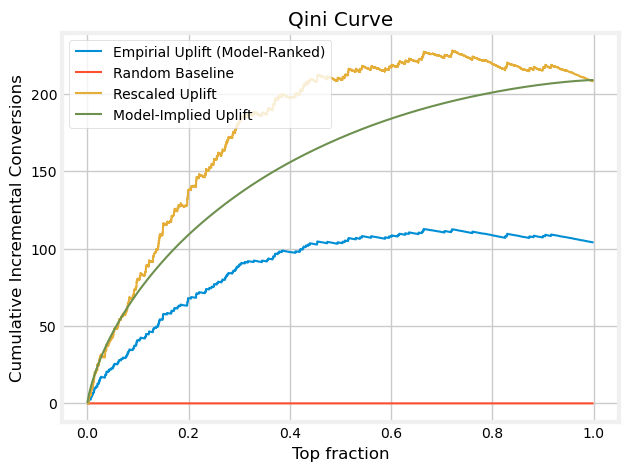

In [297]:
# Qini plot

display(qdf_est)

plt.plot(qdf_est['frac'], qdf_est['qini_incremental_cum'], color=palette_538[0], label="Empirial Uplift (Model-Ranked)")
plt.plot(qdf_rand['frac'], qdf_rand['random_incremental_cum'], color=palette_538[1], label="Random Baseline")
plt.plot(qdf_est['frac'], qdf_est['qini_rescaled'], color=palette_538[2], label="Rescaled Uplift")
plt.plot(qdf_est['frac'], qdf_est['qini_model'], color=palette_538[3], label="Model-Implied Uplift")

plt.xlabel('Top fraction')
plt.ylabel('Cumulative Incremental Conversions')
plt.legend()
plt.title('Qini Curve')
plt.show()

,k,n_selected,treated_in_top,expected_random_in_top,pred_inc_conv,obs_inc_conv,rescaled_obs_inc_conv,pred_inc_aum_client,obs_inc_aum_client,rescaled_obs_inc_aum_client,pred_inc_rev_client,obs_inc_rev_client,rescaled_obs_inc_rev_client
0,0.01,96,49,1.0,14.0,5.0,11.0,1353147.0,267209.0,523511.0,947.0,187.0,366.0
1,0.05,484,257,3.0,46.0,23.0,43.0,1039418.0,172358.0,324597.0,728.0,121.0,227.0
2,0.10,969,492,6.0,72.0,41.0,80.0,2486514.0,992499.0,1954739.0,1741.0,695.0,1368.0
3,0.15,1454,724,9.0,92.0,57.0,114.0,2669097.0,1164534.0,2338718.0,1868.0,815.0,1637.0
4,0.20,1939,957,12.0,109.0,68.0,138.0,3313008.0,1492962.0,3024926.0,2319.0,1045.0,2117.0
5,0.25,2424,1182,15.0,123.0,76.0,156.0,3244172.0,1434029.0,2940851.0,2271.0,1004.0,2059.0


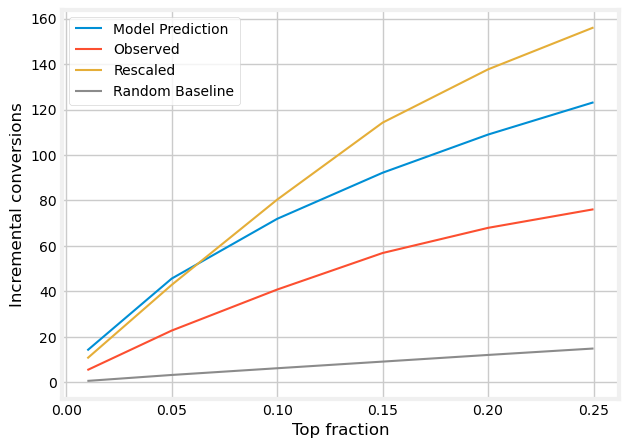

In [306]:
# Top-k plot: conversions

disp_topk_est = topk_est.copy()
disp_topk_est[disp_topk_est.columns[3:]] = disp_topk_est[disp_topk_est.columns[3:]].apply(np.round)
display(disp_topk_est)

plt.plot(topk_est['k'], topk_est['pred_inc_conv'], label="Model Prediction", color=palette_538[0])
plt.plot(topk_est['k'], topk_est['obs_inc_conv'], label="Observed", color=palette_538[1])
plt.plot(topk_est['k'], topk_est['rescaled_obs_inc_conv'], label="Rescaled", color=palette_538[2])
plt.plot(topk_est['k'], topk_est['expected_random_in_top'], label="Random Baseline", color=palette_538[4])

plt.xlabel('Top fraction')
plt.ylabel('Incremental conversions')
plt.legend()
plt.show()

del disp_topk_est

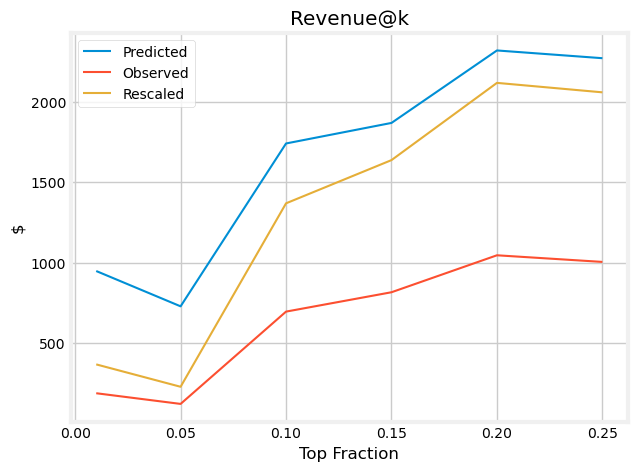

In [307]:
# Top-k plot: revenue

plt.plot(topk_est['k'], topk_est['pred_inc_rev_client'], color=palette_538[0], label="Predicted")
plt.plot(topk_est['k'], topk_est['obs_inc_rev_client'], color=palette_538[1], label="Observed")
plt.plot(topk_est['k'], topk_est['rescaled_obs_inc_rev_client'], color=palette_538[2], label="Rescaled")

plt.ylabel("$")
plt.xlabel("Top Fraction")
plt.title("Revenue@k")
plt.legend()
plt.show()

In [308]:
# 5) bootstrap to get CIs

# estimator_built = lambda: build_xgb_estimator(max_depth=6, n_estimators=200, learning_rate=0.05, random_state=0, scale_pos_weight=rare_weight)
estimator_built = lambda: build_logistic_estimator()

bs_res = bootstrap_pipeline(simple_data,
                            features,
                            preproc,
                            estimator_built,
                            metalearner='S',
                            treatment_col='treatment',
                            outcome_col='converted',
                            score_col='tau_hat_oos',
                            treat_control_conv_col=['p0_oos', 'p1_oos'],
                            aum_client_col='delta_aum_client',
                            management_fees=typical_management_fees,
                            k_folds=5,
                            k_bootstrap=200,
                            k_list=[0.01,0.05,0.1,0.15,0.2,0.25],
                            random_state=0)

In [309]:
# bootstrap results:

bs_res_topk = pd.DataFrame(bs_res['topk_stats']).T.map(lambda x: np.round(x, 2))
display(bs_res_topk)

,pred_inc_conv_mean,pred_inc_conv_ci,obs_inc_conv_mean,obs_inc_conv_ci,resc_inc_conv_mean,resc_inc_conv_ci,pred_inc_aum_mean,pred_inc_aum_ci,obs_inc_aum_mean,obs_inc_aum_ci,resc_inc_aum_mean,resc_inc_aum_ci,pred_inc_rev_mean,pred_inc_rev_ci,obs_inc_rev_mean,obs_inc_rev_ci,resc_inc_rev_mean,resc_inc_rev_ci
0.01,13.91,"[9.84, 18.24]",5.66,"[1.41, 11.53]",11.83,"[2.84, 23.94]",1190107.59,"[-629931.28, 3558989.54]",191822.95,"[-391207.17, 940597.45]",398410.25,"[-857188.78, 1964448.5]",833.08,"[-440.95, 2491.29]",134.28,"[-273.85, 658.42]",278.89,"[-600.03, 1375.11]"
0.05,46.63,"[33.29, 61.04]",27.85,"[15.86, 40.37]",53.94,"[31.5, 75.77]",2125335.55,"[-369565.21, 4688283.18]",789610.14,"[-307173.99, 1867330.43]",1522638.13,"[-580634.75, 3630817.05]",1487.73,"[-258.7, 3281.8]",552.73,"[-215.02, 1307.13]",1065.85,"[-406.44, 2541.57]"
0.10,74.22,"[52.83, 96.23]",47.34,"[33.86, 61.77]",93.68,"[67.93, 122.96]",2731087.81,"[533611.25, 5277544.2]",1161423.23,"[90524.19, 2383342.13]",2295311.83,"[176163.61, 4630448.03]",1911.76,"[373.53, 3694.28]",813.00,"[63.37, 1668.34]",1606.72,"[123.31, 3241.31]"
0.15,95.38,"[68.06, 122.75]",62.54,"[45.55, 81.69]",124.93,"[89.66, 159.46]",2923866.16,"[930406.51, 5586755.03]",1325238.87,"[179534.13, 2558780.73]",2645031.78,"[357303.73, 4994275.3]",2046.71,"[651.28, 3910.73]",927.67,"[125.67, 1791.15]",1851.52,"[250.11, 3495.99]"
0.20,112.53,"[80.43, 144.73]",75.59,"[57.28, 96.72]",150.87,"[113.82, 188.52]",2854802.51,"[610608.82, 5371580.14]",1389057.71,"[351799.52, 2644283.23]",2769381.38,"[691400.83, 5328080.92]",1998.36,"[427.43, 3760.11]",972.34,"[246.26, 1851.0]",1938.57,"[483.98, 3729.66]"
0.25,126.89,"[90.82, 163.47]",84.13,"[64.68, 105.12]",168.43,"[128.49, 208.35]",2898303.77,"[641955.94, 5656158.51]",1423953.40,"[353505.13, 2811930.03]",2849038.65,"[711164.75, 5566804.78]",2028.81,"[449.37, 3959.31]",996.77,"[247.45, 1968.35]",1994.33,"[497.82, 3896.76]"


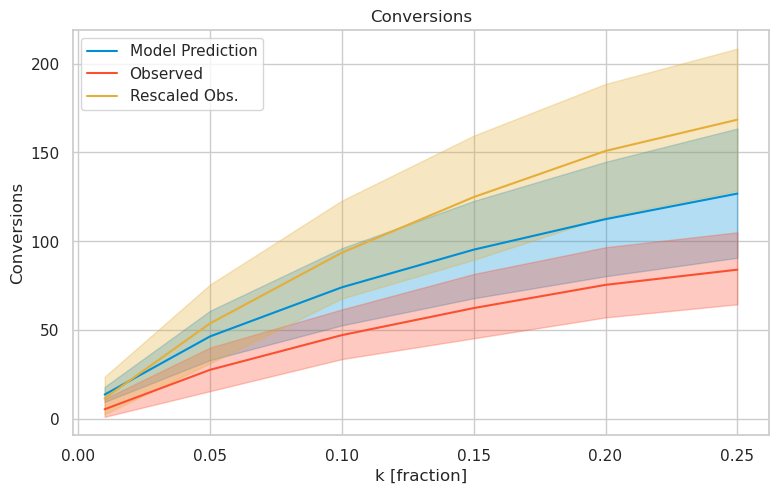

In [319]:
# bootstrap plots:

topk_dict = {"Conversions":"_inc_conv",
             "AUM [$]":"_inc_aum",
             "Revenue [$]":"_inc_rev"}

qty_dict = {"pred":"Model Prediction",
            "obs":"Observed",
            "resc":"Rescaled Obs."}

# Set seaborn style
sns.set_theme(style="whitegrid")

# Ensure clean arrays
x = bs_res_topk.index.to_numpy()

# Variable to plot:
var = "Conversions"
# var = "AUM [$]"
# var = "Revenue [$]"

fig, ax = plt.subplots(figsize=(8, 5))
for i, qty in enumerate(['pred', 'obs', 'resc']):

    # if i == 1:
    #     continue
    
    col = qty+topk_dict[var]
    y = bs_res_topk[col+'_mean']
    y_ci = np.array(bs_res_topk[col+'_ci'].to_list())

    # Plot
    sns.lineplot(x=x, y=y, ax=ax, label=qty_dict[qty], color=palette_538[i])
    ax.fill_between(x, y_ci[:,0], y_ci[:,1], color=palette_538[i], alpha=0.3)

ax.set_xlabel("k [fraction]")
ax.set_ylabel(var)
plt.title(var)
ax.legend()
plt.show()

del topk_dict, qty_dict, x, y, y_ci, fig, ax

Lastly, we can "project" what these quantities would be if we rolled out our experiment to the entire population of ABC Investments (say, 50M individuals):

$$X_{rollout} = X_{\rm exper.} \times \frac{N}{n_{\rm exper.}} \ .$$

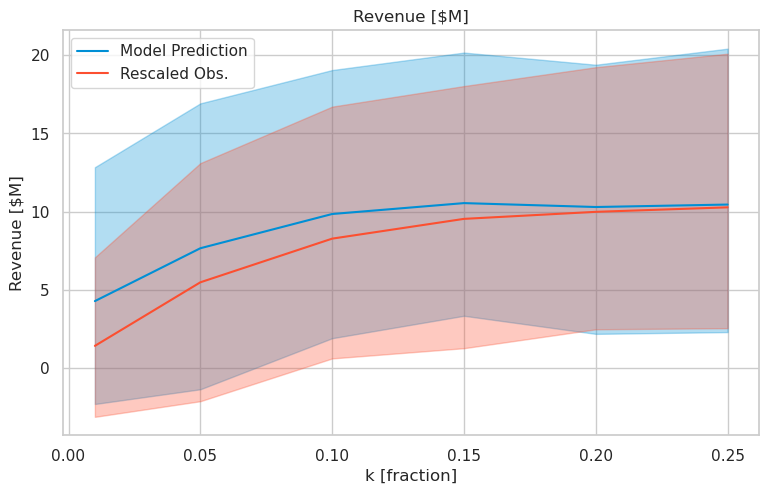

In [320]:
# rollout plots:

# projection factor
factor = (50*ONE_MILLION / len(df)) # = 50*ONE_MILLION / (2*summary['n_arm'])

topk_dict = {"Conversions":"_inc_conv",
             "AUM [$M]":"_inc_aum",
             "Revenue [$M]":"_inc_rev"}

qty_dict = {"pred":"Model Prediction",
            "obs":"Observed",
            "resc":"Rescaled Obs."}

# Set seaborn style
sns.set_theme(style="whitegrid")

# Ensure clean arrays
x = bs_res_topk.index.to_numpy()

# Variable to plot:
# var = "Conversions"
# var = "AUM [$M]"
var = "Revenue [$M]"

fig, ax = plt.subplots(figsize=(8, 5))
for i, qty in enumerate(['pred', 'resc']):
    
    col = qty+topk_dict[var]
    y = factor*bs_res_topk[col+'_mean']
    y_ci = factor*np.array(bs_res_topk[col+'_ci'].to_list())

    if ('$M' in var):
        y /= ONE_MILLION
        y_ci /= ONE_MILLION

    # Plot
    sns.lineplot(x=x, y=y, ax=ax, label=qty_dict[qty], color=palette_538[i])
    ax.fill_between(x, y_ci[:,0], y_ci[:,1], color=palette_538[i], alpha=0.3)

ax.set_xlabel("k [fraction]")
ax.set_ylabel(var)
plt.title(var)
ax.legend()
plt.show()

del factor, topk_dict, qty_dict, x, y, y_ci, fig, ax

##### Cleanup

In [321]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name